In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from darts import TimeSeries
from darts.models import (RandomForestModel, XGBModel, LightGBMModel, CatBoostModel)
from darts.metrics import mape, smape, mae, rmse, mase
from darts.dataprocessing.transformers import MissingValuesFiller
from darts.dataprocessing.transformers import Scaler
from darts.utils.timeseries_generation import datetime_attribute_timeseries
np.random.seed(1)

In [20]:
series = TimeSeries.from_csv(
    'data2.csv',
    time_col='date',
    value_cols=['price', 'production', 'nev-sales', 'wind-energy-index', 'magnet-exports', 'event-score'], 
    freq= 'M'
)

# MissingValuesFiller로 과거 공변량 결측치에 PCHIP 보간 적용
filler = MissingValuesFiller()
series_filled = filler.transform(series, method="pchip")

e:\Programs\anaconda3\Lib\site-packages\darts\timeseries.py:5120: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  resampled_times = resampled_times.asfreq(freq)


In [ ]:
'''
하나의 값이 10만 단위이고 다른 값이 일의 자리 숫자여도,
트리 기반 모델(CatBoost, LightGBM, XGBoost, RandomForest 등)은 
원칙적으로 학습 데이터의 스케일링이 전혀 필요 없다

트리 모델의 의사결정 방식은 '거리'나 '크기'가 아니라
'순서'와 '분기점(Split Point)'에 기반하기 때문
'''

target data = train: 62 records + val: 31 records + test: 27 records
covariates data = train_cov: 62 records + val_cov: 31 records + test_cov: 27 records


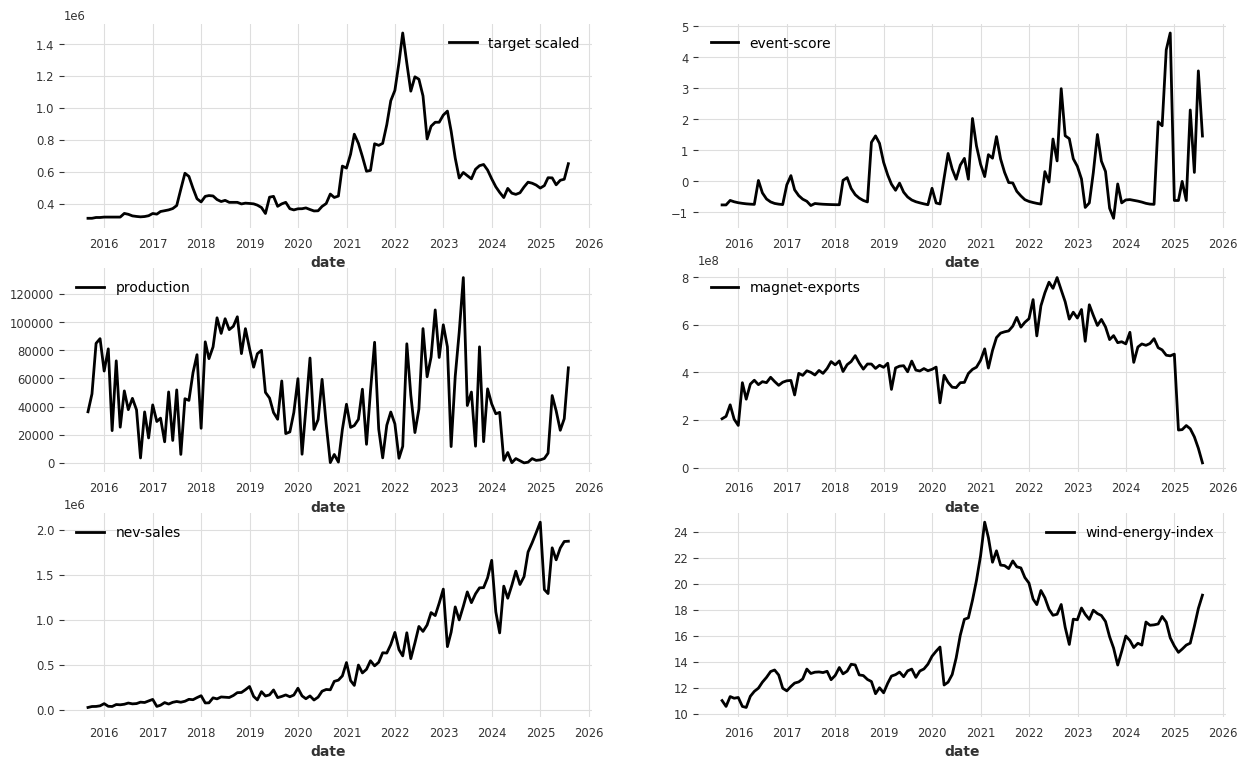

In [48]:
target = series_filled['price']
past_cov = series_filled[['production', 'nev-sales', 'wind-energy-index', 'magnet-exports', 'event-score']]
fig, axs = plt.subplots(3, 2, figsize=(15, 3*3))

# 타깃
target.plot(label='target scaled', ax=axs[0,0])
train, val = target.split_before(pd.Timestamp('2020-10-31'))
val, test = val.split_before(pd.Timestamp('2023-05-31'))
print(f"target data = train: {len(train)} records + val: {len(val)} records + test: {len(test)} records")

# 공변량
past_cov['event-score'].plot(ax=axs[0,1])
past_cov['production'].plot(ax=axs[1,0])
past_cov['magnet-exports'].plot(ax=axs[1,1])
past_cov['nev-sales'].plot(ax=axs[2,0])
past_cov['wind-energy-index'].plot(ax=axs[2,1])

train_cov, val_cov = past_cov.split_before(pd.Timestamp('2020-10-31'))
val_cov, test_cov = val_cov.split_before(pd.Timestamp('2023-05-31'))
print(f"covariates data = train_cov: {len(train_cov)} records + val_cov: {len(val_cov)} records + test_cov: {len(test_cov)} records")

In [4]:
def evaluate_predictions(model, train, actual, pred_dict, seasonal_period=12):
    results = []
    
    print("="*80)
    print(f"{model} 예측 성능 평가 결과")
    print("="*80)
    
    for model_name, pred_series in pred_dict.items():
        try:
            # 4가지 지표 계산
            mae_score = mae(actual, pred_series)
            rmse_score = rmse(actual, pred_series)
            mape_score = mape(actual, pred_series)
            mase_score = mase(actual, pred_series, train, m=seasonal_period)
            
            # 결과 저장
            results.append({
                'Model': model_name,
                'MAE': mae_score,
                'RMSE': rmse_score,
                'MAPE': mape_score,
                'MASE': mase_score
            })
            
            # 개별 출력
            print(f"{model_name:20s} | MAE: {mae_score:7.4f} | RMSE: {rmse_score:7.4f} | MAPE: {mape_score:6.2f}% | MASE: {mase_score:7.4f}")
            
        except Exception as e:
            print(f"{model_name:20s} | ERROR: {str(e)}")

In [5]:
def plot_model_analysis(models, model_names, predictions, model_vars, n_target_lag, n_var_lag, target=target, figsize=(24, 22)):
    """
    모델별 예측 결과, Feature Importance, 변수별 중요도를 시각화하는 함수
    
    Parameters:
    -----------
    models : list
        분석할 모델들의 리스트
    model_names : list
        모델 이름들의 리스트
    predictions : list
        각 모델의 예측 결과 리스트
    model_vars : list
        각 모델에서 사용된 변수들의 리스트
    target : TimeSeries
        실제 타겟 데이터
    figsize : tuple
        그래프 크기 (width, height)
    """
    
    fig, axs = plt.subplots(len(models), 3, figsize=figsize)
    
    for i, (model, name, pred, used_vars) in enumerate(zip(models, model_names, predictions, model_vars)):
        # 첫 번째 열: 예측 결과
        target.plot(label='actual', ax=axs[i,0])
        pred.plot(label=f'pred {name}', ax=axs[i,0])
        axs[i,0].set_title(f'{name} - Prediction')
        axs[i,0].legend()
        
        # 두 번째, 세 번째 열: Feature Importance
        if hasattr(model, 'model') and hasattr(model.model, 'feature_importances_') and len(used_vars) > 0:
            importances = model.model.feature_importances_
            
            # 각 모델에 맞는 feature names 생성
            feature_names = []
            # Target lags
            for j in range(1, 1+n_target_lag):
                feature_names.append(f'price_lag_{j}')
            # 사용된 공변량의 lags만 추가
            for var_name in used_vars:
                for j in range(1, 1+n_var_lag):
                    feature_names.append(f'{var_name}_lag_{j}')
            
            # Feature 수 맞추기
            if len(feature_names) != len(importances):
                feature_names = [f'feature_{j}' for j in range(len(importances))]
            
            # 두 번째 열: 상위 10개 Feature Importance
            indices = np.argsort(importances)[::-1][:10]
            axs[i,1].barh(range(10), importances[indices][::-1])
            axs[i,1].set_yticks(range(10))
            axs[i,1].set_yticklabels([feature_names[j] for j in indices[::-1]], fontsize=8)
            axs[i,1].set_xlabel('Feature Importance')
            axs[i,1].set_title(f'{name} - Top 10 Features')
            
            # 세 번째 열: 변수별 합계 중요도
            var_importance = {}
            
            # Target lags 합계
            target_imp = sum([importances[j] for j, feat in enumerate(feature_names) 
                             if feat.startswith('price_lag')])
            var_importance['price_lags'] = target_imp
            
            # 사용된 각 변수별 합계
            for var_name in used_vars:
                total_imp = sum([importances[j] for j, feat in enumerate(feature_names) 
                                if feat.startswith(var_name)])
                var_importance[var_name] = total_imp
            
            # 변수별 중요도 시각화
            vars_sorted = sorted(var_importance.items(), key=lambda x: x[1], reverse=True)
            axs[i,2].barh([x[0] for x in vars_sorted], [x[1] for x in vars_sorted])
            axs[i,2].set_xlabel('Total Variable Importance')
            axs[i,2].set_title(f'{name} - Variable Importance')
            
        else:
            # C_0 모델이나 feature importance가 없는 경우
            axs[i,1].text(0.5, 0.5, 'No Feature Importance\n(Target Only Model)', 
                         ha='center', va='center', transform=axs[i,1].transAxes)
            axs[i,1].set_title(f'{name} - Features')
            
            axs[i,2].text(0.5, 0.5, 'No Covariates\n(Target Only Model)', 
                         ha='center', va='center', transform=axs[i,2].transAxes)
            axs[i,2].set_title(f'{name} - Variables')
    
    plt.tight_layout()
    plt.show()

#### R1 Pre→COVID: rf/xgb/lgbm/cat
- C0: 타깃 단독(price only)
- Call: 모든 공변량 포함(이벤트는 future_cov로만 사용 가능 시 별도 처리)
- LOO_w/m/p/n/e: Call에서 해당 변수만 제거

`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.
`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.
`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.
`predict()` was called with `n > output_

<class 'darts.models.forecasting.random_forest.RandomForestModel'> 예측 성능 평가 결과
Target_Only          | MAE: 471831.4516 | RMSE: 530271.9214 | MAPE:  49.58% | MASE:  7.5288
All_Covariates       | MAE: 485866.4516 | RMSE: 543389.8838 | MAPE:  51.27% | MASE:  7.7528
LOO_Wind             | MAE: 479034.1935 | RMSE: 537264.4608 | MAPE:  50.46% | MASE:  7.6438
LOO_Magnet           | MAE: 485843.8710 | RMSE: 542656.9445 | MAPE:  51.32% | MASE:  7.7524
LOO_Production       | MAE: 494315.0000 | RMSE: 552388.1824 | MAPE:  52.19% | MASE:  7.8876
LOO_NEV              | MAE: 476202.4194 | RMSE: 534421.3739 | MAPE:  50.10% | MASE:  7.5986
LOO_Event            | MAE: 487659.1935 | RMSE: 544940.3358 | MAPE:  51.48% | MASE:  7.7814


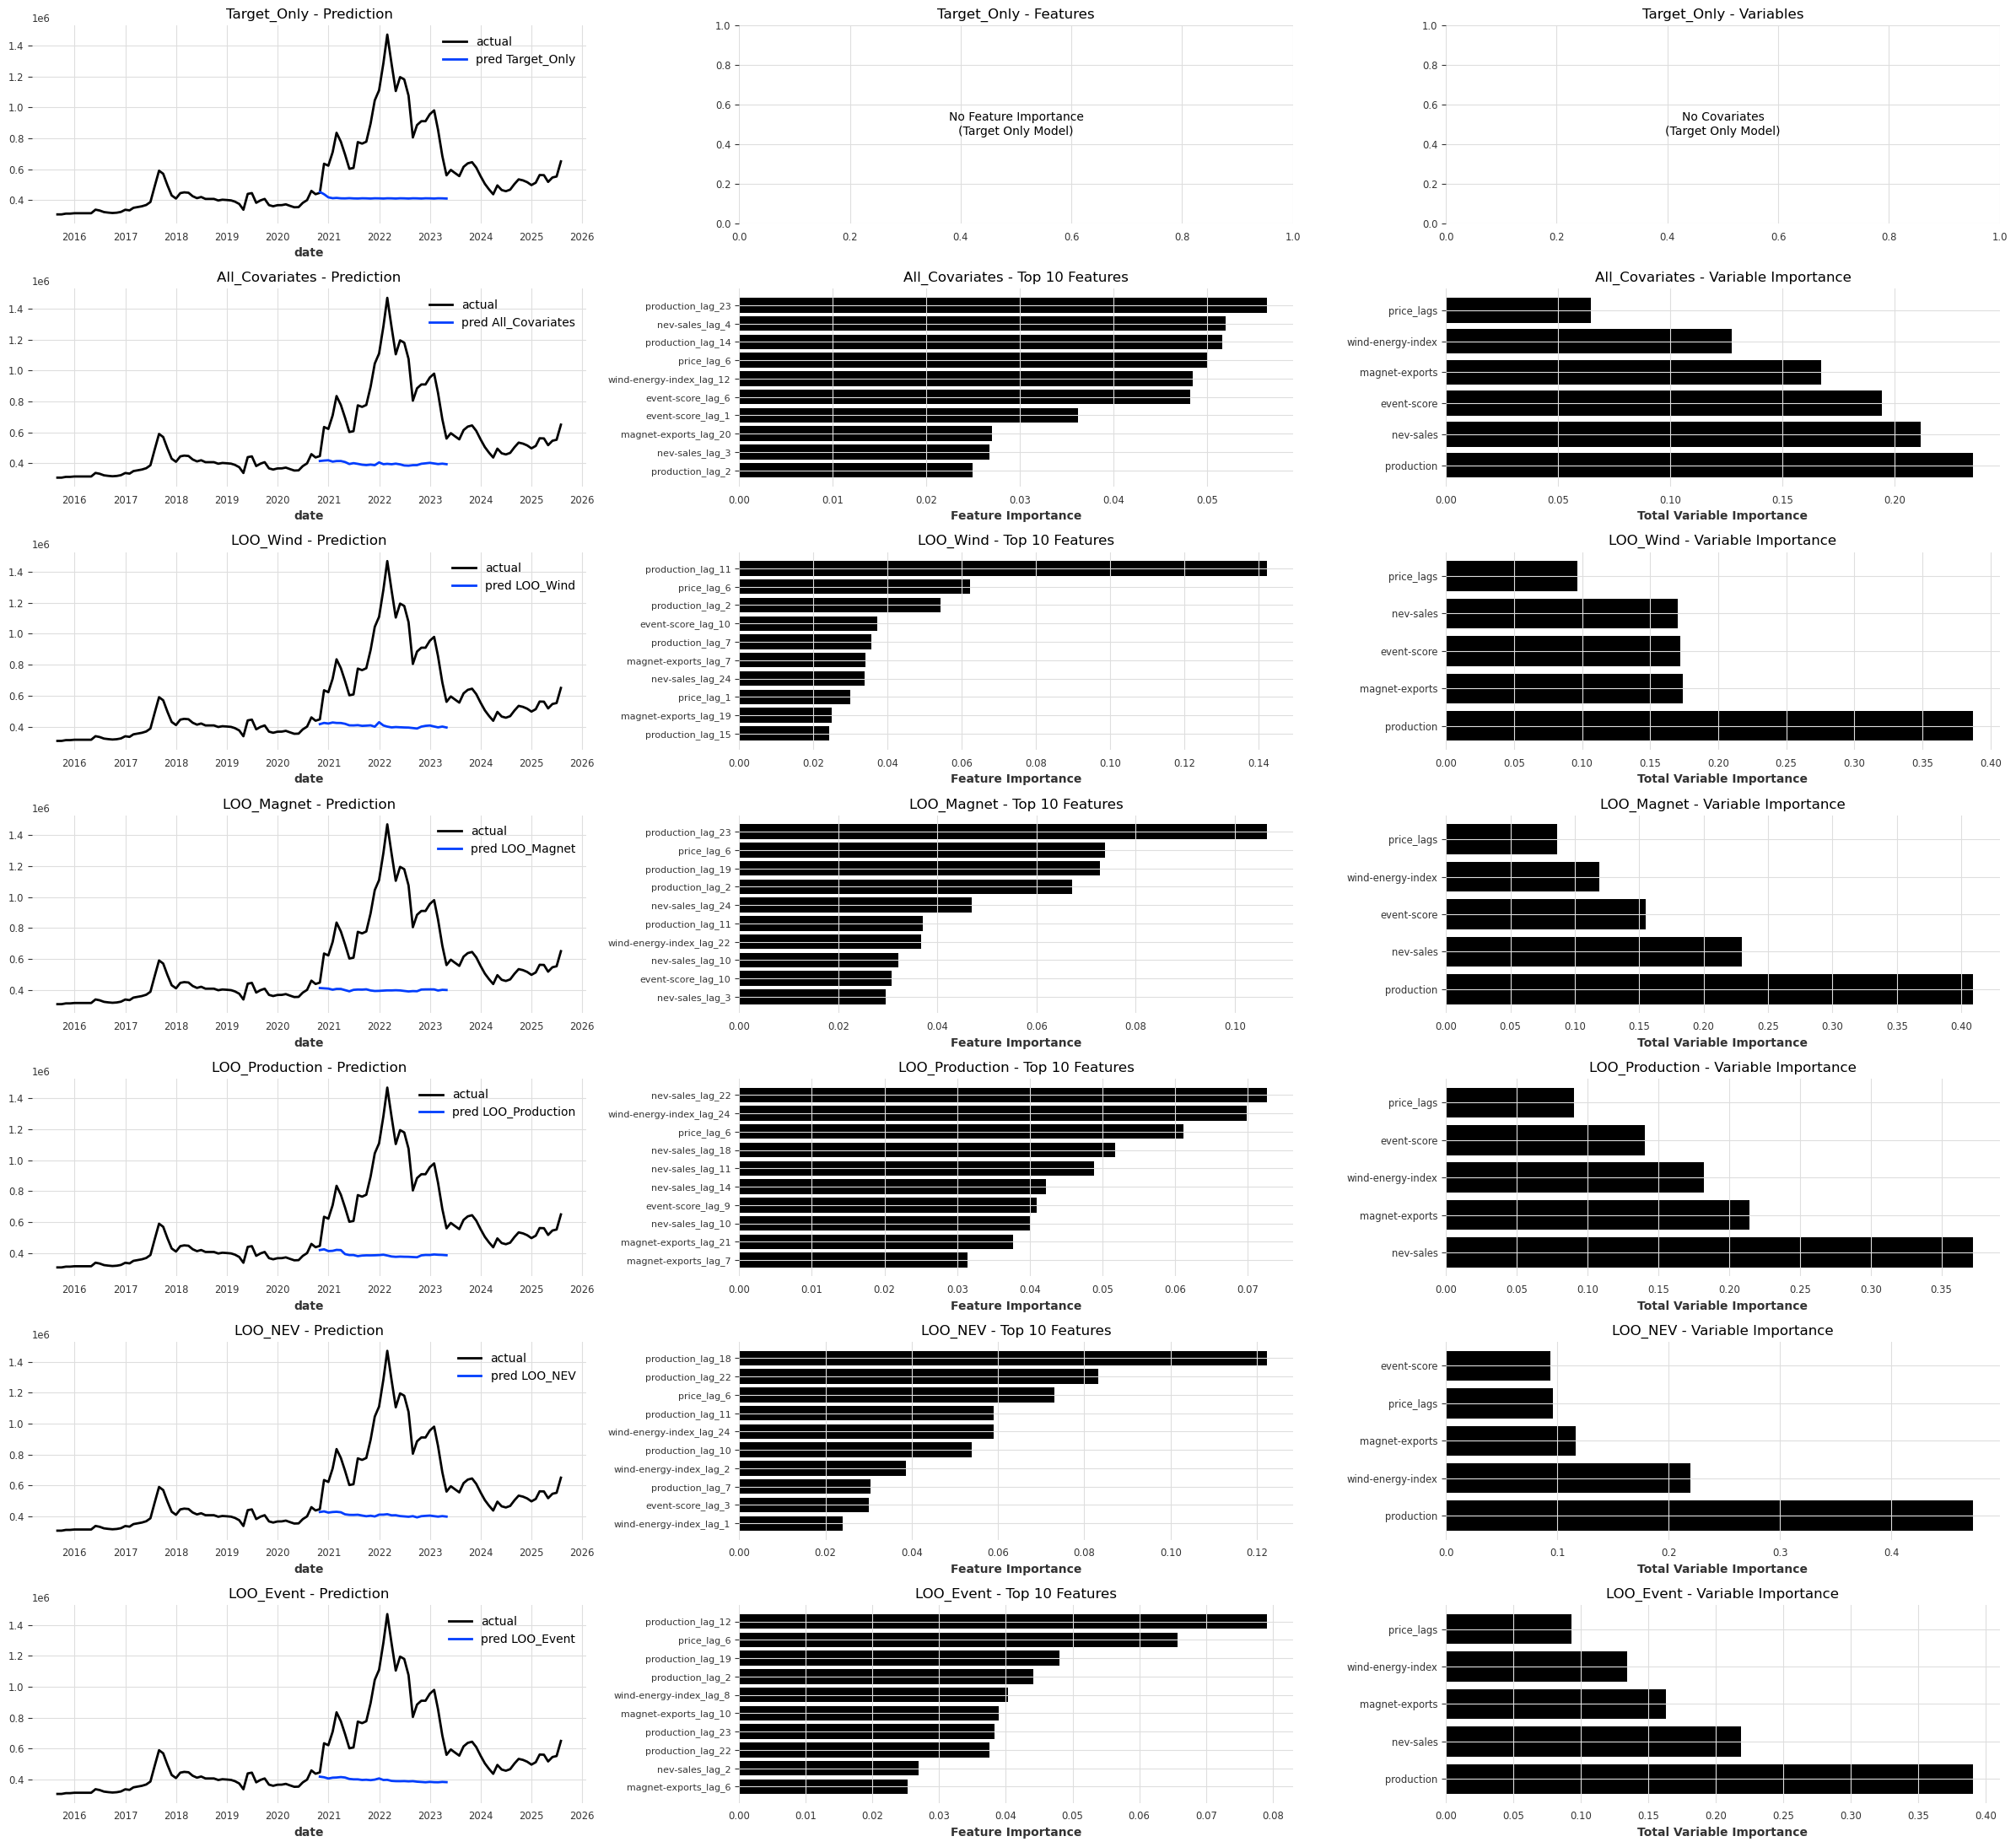

In [6]:
input = 6 # 별 차이 없음
output = 1 # 별 차이 없음
lag_cov = 24 # 별 차이 없음
train_set = train
test_set = val
cov_set = train_cov.concatenate(val_cov)
pred_len = len(test_set)
Model = RandomForestModel

C_0 = Model(lags=input, output_chunk_length=output)
C_0.fit(train_set)
C_all = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_all.fit(train_set, past_covariates=cov_set)
C_loo_w = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_loo_w.fit(train_set, past_covariates=cov_set[['production', 'nev-sales', 'magnet-exports', 'event-score']])
C_loo_m = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_loo_m.fit(train_set, past_covariates=cov_set[['production', 'nev-sales', 'wind-energy-index', 'event-score']])
C_loo_p = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_loo_p.fit(train_set, past_covariates=cov_set[['nev-sales', 'wind-energy-index', 'magnet-exports', 'event-score']])
C_loo_n = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_loo_n.fit(train_set, past_covariates=cov_set[['production', 'wind-energy-index', 'magnet-exports', 'event-score']])
C_loo_e = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_loo_e.fit(train_set, past_covariates=cov_set[['production', 'nev-sales', 'wind-energy-index', 'magnet-exports']])

pred_C_0 = C_0.predict(n=pred_len)
pred_C_all = C_all.predict(n=pred_len)
pred_C_loo_w = C_loo_w.predict(n=pred_len)
pred_C_loo_m = C_loo_m.predict(n=pred_len)
pred_C_loo_p = C_loo_p.predict(n=pred_len)
pred_C_loo_n = C_loo_n.predict(n=pred_len)
pred_C_loo_e = C_loo_e.predict(n=pred_len)

# 평가 실행
predictions_dict = {
    'Target_Only': pred_C_0,
    'All_Covariates': pred_C_all,
    'LOO_Wind': pred_C_loo_w,
    'LOO_Magnet': pred_C_loo_m,
    'LOO_Production': pred_C_loo_p,
    'LOO_NEV': pred_C_loo_n,
    'LOO_Event': pred_C_loo_e
}
evaluate_predictions(Model, train_set, test_set, predictions_dict)

# 예측결과 및 변수 중요도
models = [C_0, C_all, C_loo_w, C_loo_m, C_loo_p, C_loo_n, C_loo_e]
model_names = ['Target_Only', 'All_Covariates', 'LOO_Wind', 'LOO_Magnet', 'LOO_Production', 'LOO_NEV', 'LOO_Event']
predictions = [pred_C_0, pred_C_all, pred_C_loo_w, pred_C_loo_m, pred_C_loo_p, pred_C_loo_n, pred_C_loo_e]
model_vars = [
    [],  # C_0: target only
    ['production', 'nev-sales', 'wind-energy-index', 'magnet-exports', 'event-score'],  # C_all
    ['production', 'nev-sales', 'magnet-exports', 'event-score'],  # C_loo_w (no wind)
    ['production', 'nev-sales', 'wind-energy-index', 'event-score'],  # C_loo_m (no magnet)
    ['nev-sales', 'wind-energy-index', 'magnet-exports', 'event-score'],  # C_loo_p (no production)
    ['production', 'wind-energy-index', 'magnet-exports', 'event-score'],  # C_loo_n (no nev)
    ['production', 'nev-sales', 'wind-energy-index', 'magnet-exports']  # C_loo_e (no event)
]
plot_model_analysis(models, model_names, predictions, model_vars, input, lag_cov)

`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.
`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.
`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.
`predict()` was called with `n > output_

<class 'darts.models.forecasting.xgboost.XGBModel'> 예측 성능 평가 결과
Target_Only          | MAE: 495429.5242 | RMSE: 552003.1107 | MAPE:  52.37% | MASE:  7.9054
All_Covariates       | MAE: 493905.2752 | RMSE: 545876.5458 | MAPE:  52.63% | MASE:  7.8810
LOO_Wind             | MAE: 492880.5675 | RMSE: 548242.7553 | MAPE:  52.25% | MASE:  7.8647
LOO_Magnet           | MAE: 506006.0000 | RMSE: 559534.7487 | MAPE:  53.87% | MASE:  8.0741
LOO_Production       | MAE: 488375.9143 | RMSE: 541417.7241 | MAPE:  51.88% | MASE:  7.7928
LOO_NEV              | MAE: 478495.5696 | RMSE: 532167.1418 | MAPE:  50.77% | MASE:  7.6352
LOO_Event            | MAE: 506098.5817 | RMSE: 559356.8836 | MAPE:  53.90% | MASE:  8.0756


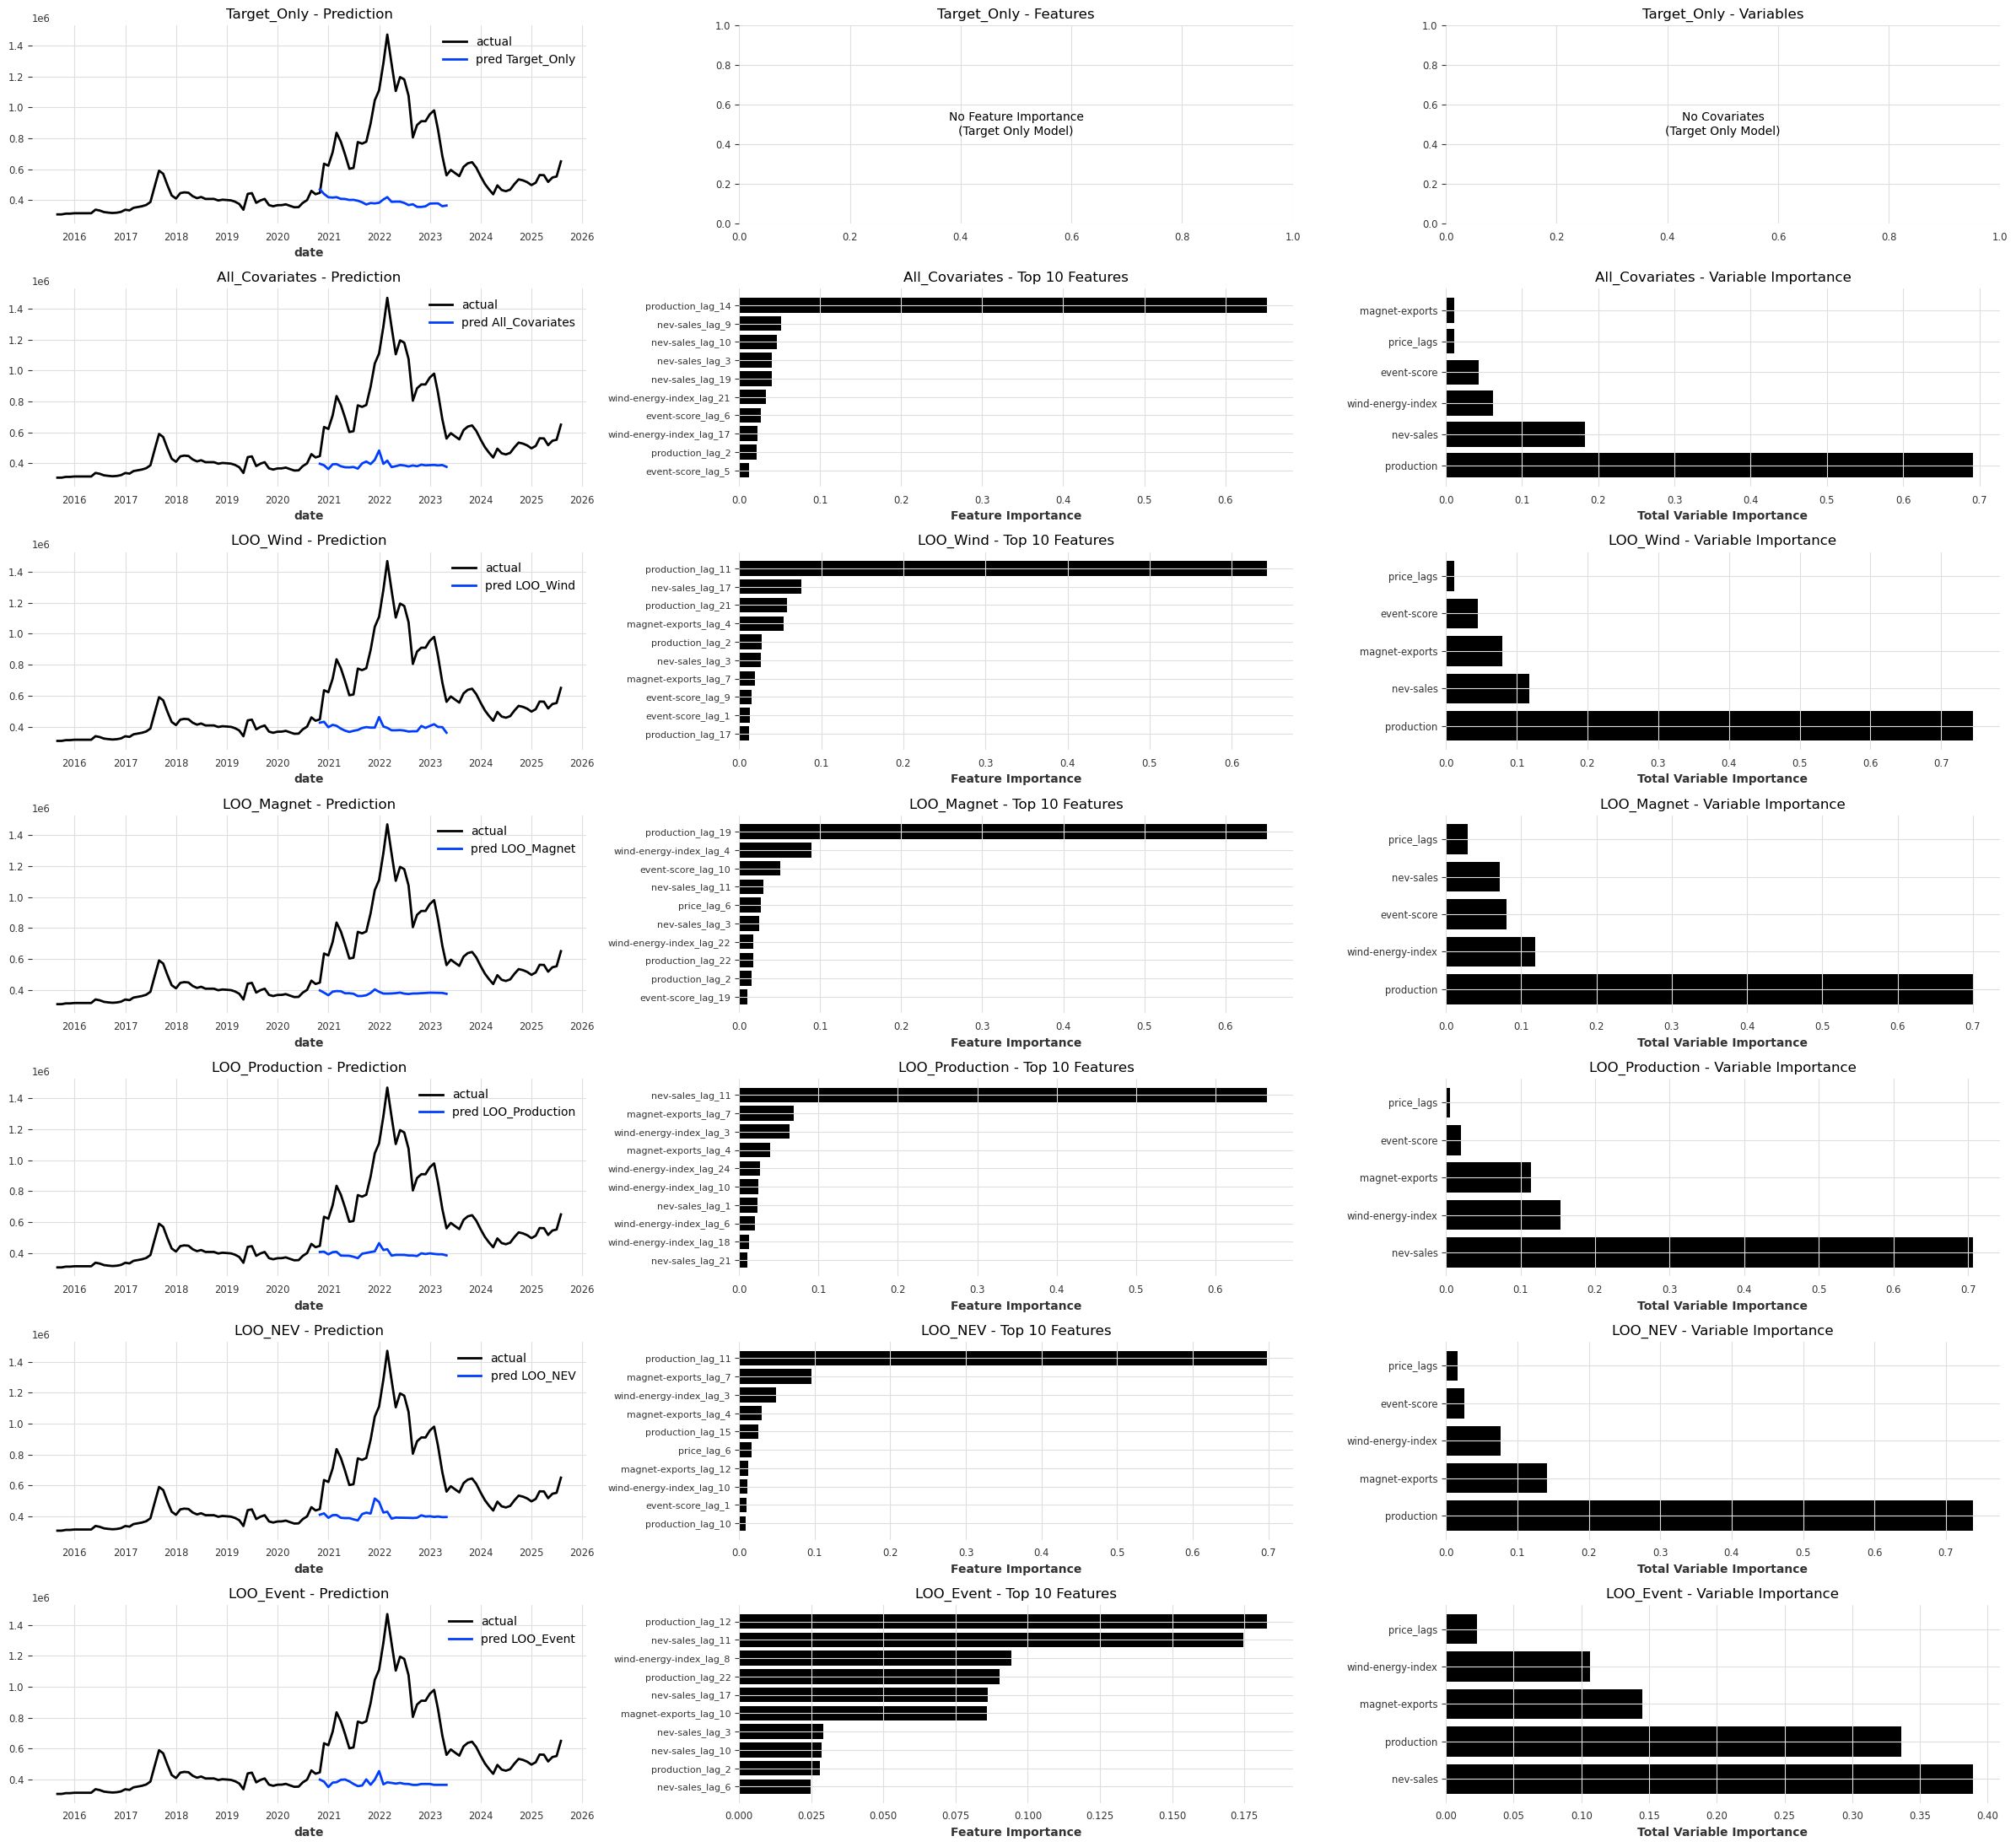

In [7]:
input = 6 # 별 차이 없음
output = 1 # 별 차이 없음
lag_cov = 24 # 별 차이 없음
train_set = train
test_set = val
cov_set = train_cov.concatenate(val_cov)
pred_len = len(test_set)
Model = XGBModel

C_0 = Model(lags=input, output_chunk_length=output)
C_0.fit(train_set)
C_all = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_all.fit(train_set, past_covariates=cov_set)
C_loo_w = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_loo_w.fit(train_set, past_covariates=cov_set[['production', 'nev-sales', 'magnet-exports', 'event-score']])
C_loo_m = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_loo_m.fit(train_set, past_covariates=cov_set[['production', 'nev-sales', 'wind-energy-index', 'event-score']])
C_loo_p = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_loo_p.fit(train_set, past_covariates=cov_set[['nev-sales', 'wind-energy-index', 'magnet-exports', 'event-score']])
C_loo_n = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_loo_n.fit(train_set, past_covariates=cov_set[['production', 'wind-energy-index', 'magnet-exports', 'event-score']])
C_loo_e = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_loo_e.fit(train_set, past_covariates=cov_set[['production', 'nev-sales', 'wind-energy-index', 'magnet-exports']])

pred_C_0 = C_0.predict(n=pred_len)
pred_C_all = C_all.predict(n=pred_len)
pred_C_loo_w = C_loo_w.predict(n=pred_len)
pred_C_loo_m = C_loo_m.predict(n=pred_len)
pred_C_loo_p = C_loo_p.predict(n=pred_len)
pred_C_loo_n = C_loo_n.predict(n=pred_len)
pred_C_loo_e = C_loo_e.predict(n=pred_len)

# 평가 실행
predictions_dict = {
    'Target_Only': pred_C_0,
    'All_Covariates': pred_C_all,
    'LOO_Wind': pred_C_loo_w,
    'LOO_Magnet': pred_C_loo_m,
    'LOO_Production': pred_C_loo_p,
    'LOO_NEV': pred_C_loo_n,
    'LOO_Event': pred_C_loo_e
}
evaluate_predictions(Model, train_set, test_set, predictions_dict)

# 예측결과 및 변수 중요도
models = [C_0, C_all, C_loo_w, C_loo_m, C_loo_p, C_loo_n, C_loo_e]
model_names = ['Target_Only', 'All_Covariates', 'LOO_Wind', 'LOO_Magnet', 'LOO_Production', 'LOO_NEV', 'LOO_Event']
predictions = [pred_C_0, pred_C_all, pred_C_loo_w, pred_C_loo_m, pred_C_loo_p, pred_C_loo_n, pred_C_loo_e]
model_vars = [
    [],  # C_0: target only
    ['production', 'nev-sales', 'wind-energy-index', 'magnet-exports', 'event-score'],  # C_all
    ['production', 'nev-sales', 'magnet-exports', 'event-score'],  # C_loo_w (no wind)
    ['production', 'nev-sales', 'wind-energy-index', 'event-score'],  # C_loo_m (no magnet)
    ['nev-sales', 'wind-energy-index', 'magnet-exports', 'event-score'],  # C_loo_p (no production)
    ['production', 'wind-energy-index', 'magnet-exports', 'event-score'],  # C_loo_n (no nev)
    ['production', 'nev-sales', 'wind-energy-index', 'magnet-exports']  # C_loo_e (no event)
]
plot_model_analysis(models, model_names, predictions, model_vars, input, lag_cov)

e:\Programs\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\Programs\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\Programs\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\Programs\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\Programs\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\Programs\anaconda3\Lib\site-packages\sklearn\utils\v

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000152 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 106
[LightGBM] [Info] Number of data points in the train set: 56, number of used features: 6
[LightGBM] [Info] Start training from score 390598.214286
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

e:\Programs\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\Programs\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\Programs\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\Programs\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\Programs\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\Programs\anaconda3\Lib\site-packages\sklearn\utils\v

<class 'darts.models.forecasting.lgbm.LightGBMModel'> 예측 성능 평가 결과
Target_Only          | MAE: 461763.0105 | RMSE: 520354.6533 | MAPE:  48.44% | MASE:  7.3682
All_Covariates       | MAE: 472473.6842 | RMSE: 529427.4403 | MAPE:  49.80% | MASE:  7.5391
LOO_Wind             | MAE: 472473.6842 | RMSE: 529427.4403 | MAPE:  49.80% | MASE:  7.5391
LOO_Magnet           | MAE: 472473.6842 | RMSE: 529427.4403 | MAPE:  49.80% | MASE:  7.5391
LOO_Production       | MAE: 472473.6842 | RMSE: 529427.4403 | MAPE:  49.80% | MASE:  7.5391
LOO_NEV              | MAE: 472473.6842 | RMSE: 529427.4403 | MAPE:  49.80% | MASE:  7.5391
LOO_Event            | MAE: 472473.6842 | RMSE: 529427.4403 | MAPE:  49.80% | MASE:  7.5391


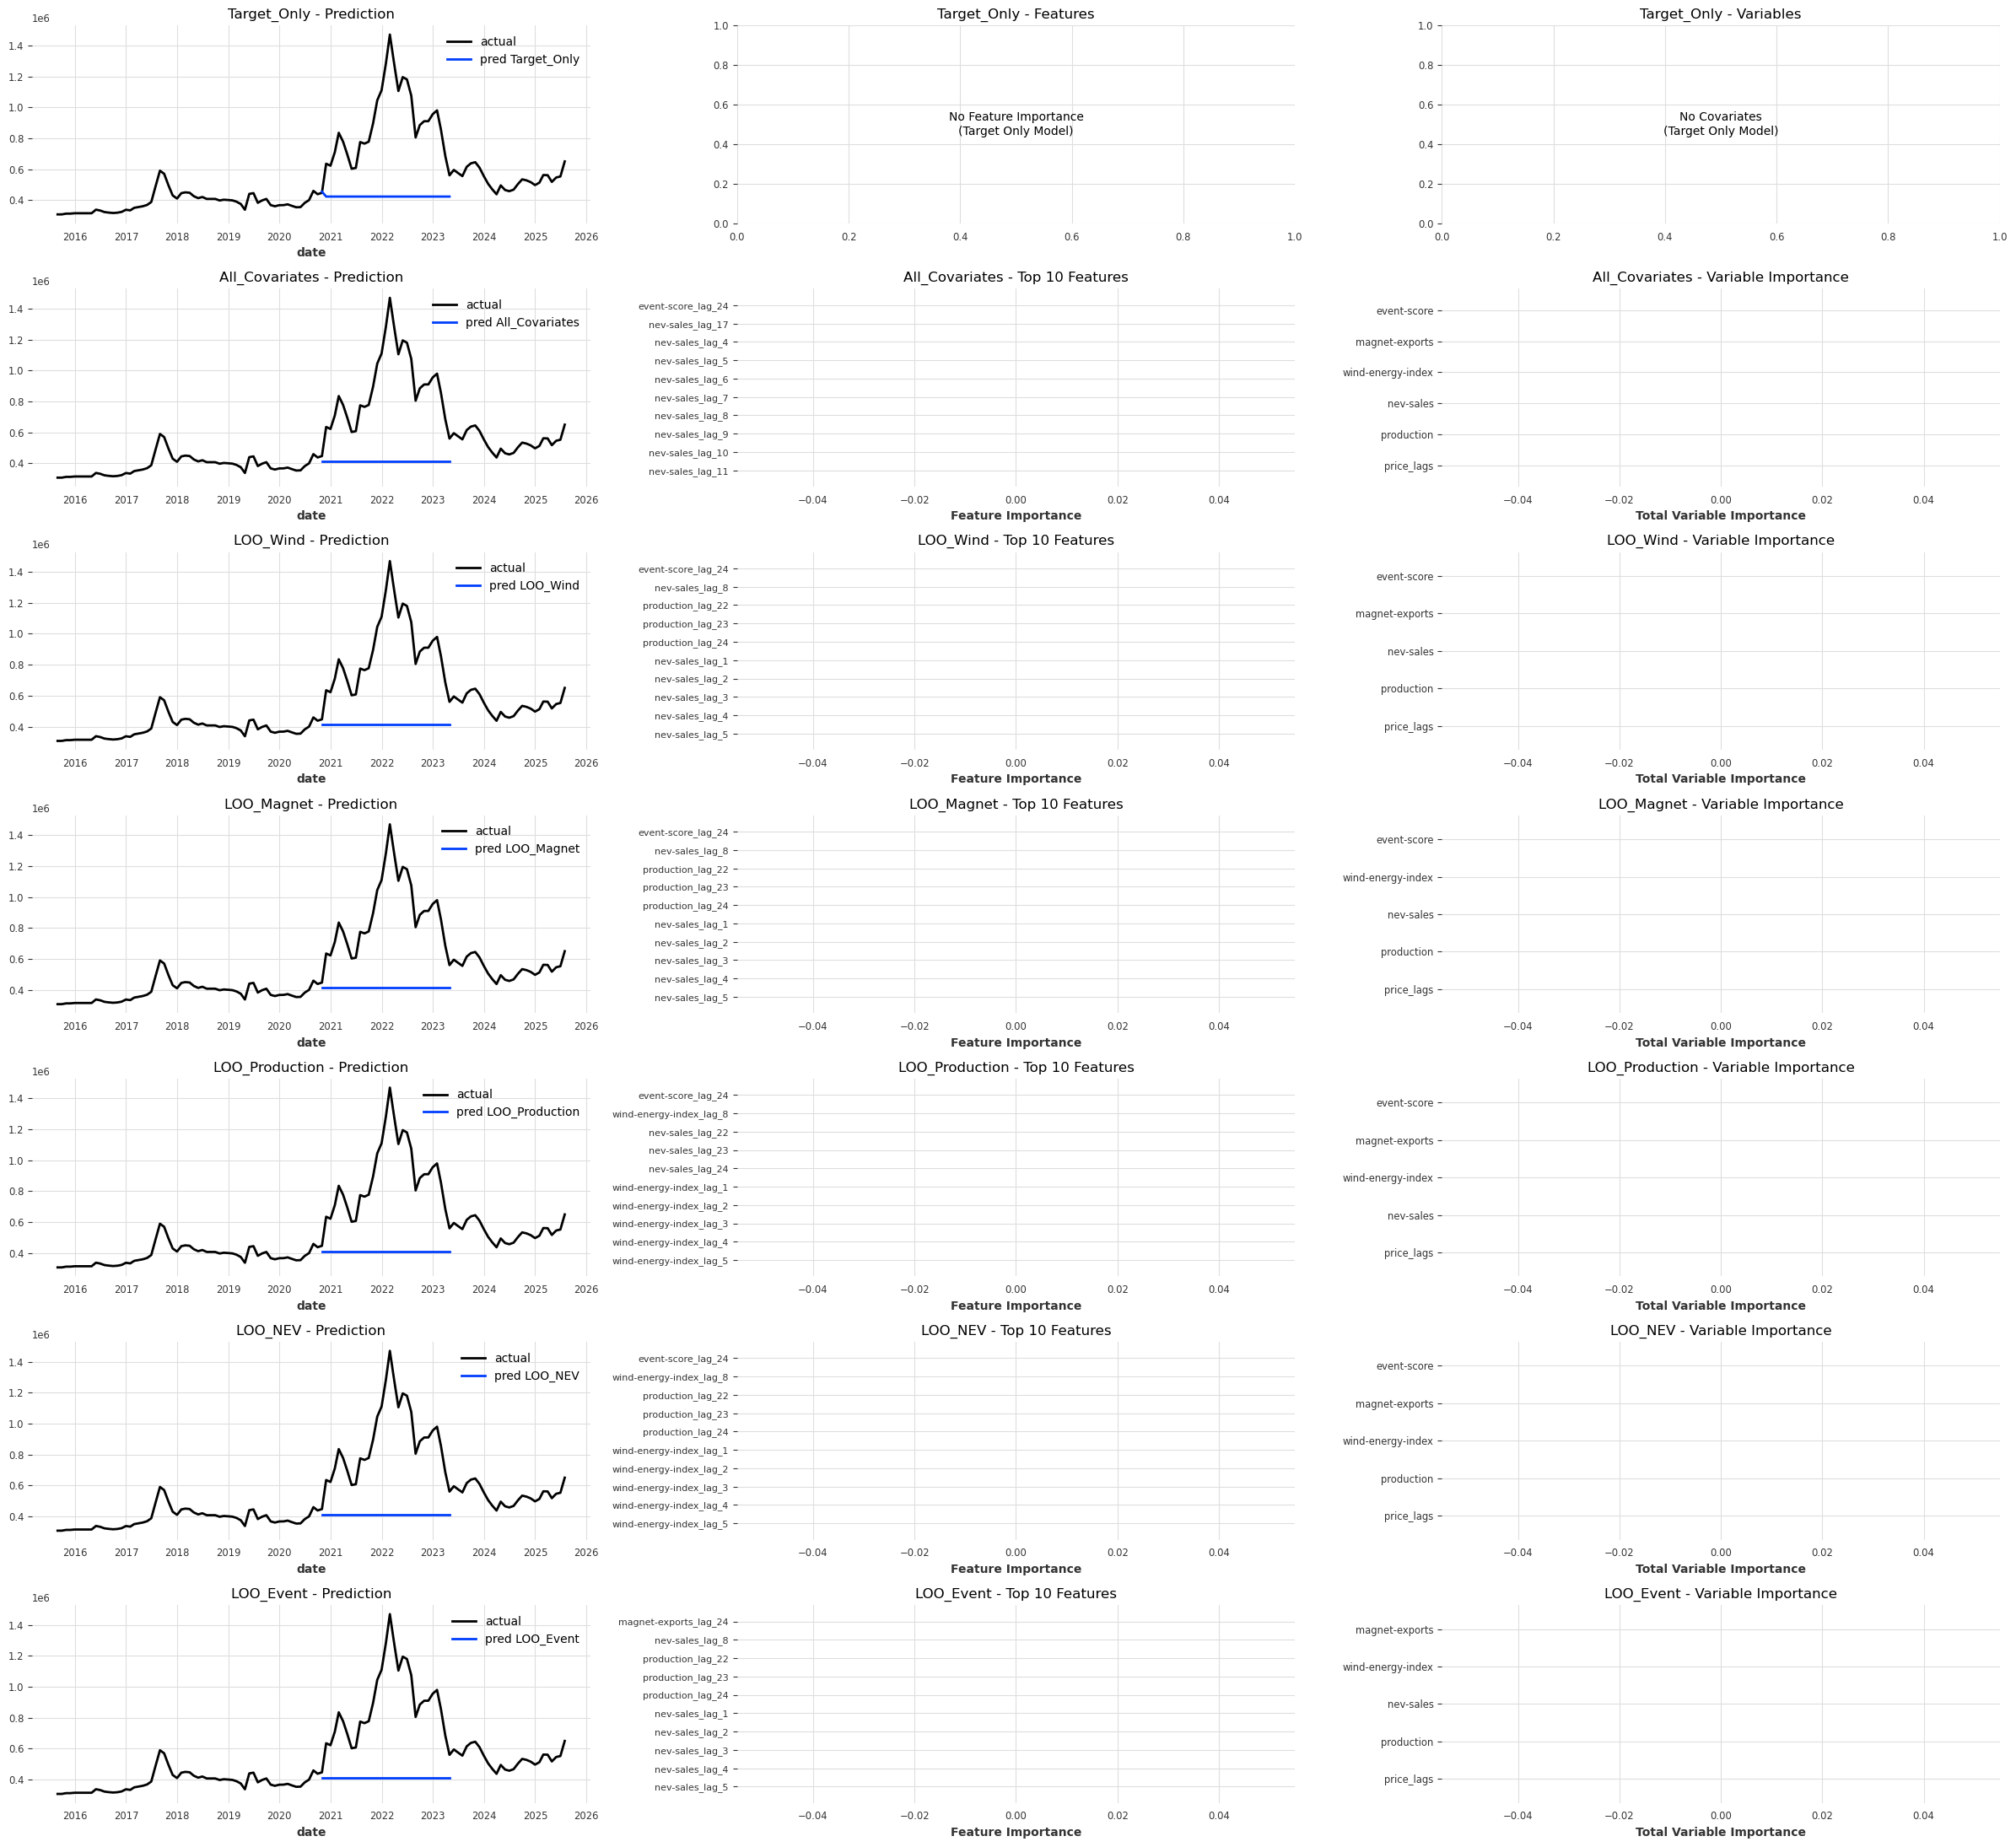

In [8]:
input = 6 # 별 차이 없음
output = 1 # 별 차이 없음
lag_cov = 24 # 별 차이 없음
train_set = train
test_set = val
cov_set = train_cov.concatenate(val_cov)
pred_len = len(test_set)
Model = LightGBMModel

C_0 = Model(lags=input, output_chunk_length=output)
C_0.fit(train_set)
C_all = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_all.fit(train_set, past_covariates=cov_set)
C_loo_w = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_loo_w.fit(train_set, past_covariates=cov_set[['production', 'nev-sales', 'magnet-exports', 'event-score']])
C_loo_m = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_loo_m.fit(train_set, past_covariates=cov_set[['production', 'nev-sales', 'wind-energy-index', 'event-score']])
C_loo_p = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_loo_p.fit(train_set, past_covariates=cov_set[['nev-sales', 'wind-energy-index', 'magnet-exports', 'event-score']])
C_loo_n = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_loo_n.fit(train_set, past_covariates=cov_set[['production', 'wind-energy-index', 'magnet-exports', 'event-score']])
C_loo_e = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_loo_e.fit(train_set, past_covariates=cov_set[['production', 'nev-sales', 'wind-energy-index', 'magnet-exports']])

pred_C_0 = C_0.predict(n=pred_len)
pred_C_all = C_all.predict(n=pred_len)
pred_C_loo_w = C_loo_w.predict(n=pred_len)
pred_C_loo_m = C_loo_m.predict(n=pred_len)
pred_C_loo_p = C_loo_p.predict(n=pred_len)
pred_C_loo_n = C_loo_n.predict(n=pred_len)
pred_C_loo_e = C_loo_e.predict(n=pred_len)

# 평가 실행
predictions_dict = {
    'Target_Only': pred_C_0,
    'All_Covariates': pred_C_all,
    'LOO_Wind': pred_C_loo_w,
    'LOO_Magnet': pred_C_loo_m,
    'LOO_Production': pred_C_loo_p,
    'LOO_NEV': pred_C_loo_n,
    'LOO_Event': pred_C_loo_e
}
evaluate_predictions(Model, train_set, test_set, predictions_dict)

# 예측결과 및 변수 중요도
models = [C_0, C_all, C_loo_w, C_loo_m, C_loo_p, C_loo_n, C_loo_e]
model_names = ['Target_Only', 'All_Covariates', 'LOO_Wind', 'LOO_Magnet', 'LOO_Production', 'LOO_NEV', 'LOO_Event']
predictions = [pred_C_0, pred_C_all, pred_C_loo_w, pred_C_loo_m, pred_C_loo_p, pred_C_loo_n, pred_C_loo_e]
model_vars = [
    [],  # C_0: target only
    ['production', 'nev-sales', 'wind-energy-index', 'magnet-exports', 'event-score'],  # C_all
    ['production', 'nev-sales', 'magnet-exports', 'event-score'],  # C_loo_w (no wind)
    ['production', 'nev-sales', 'wind-energy-index', 'event-score'],  # C_loo_m (no magnet)
    ['nev-sales', 'wind-energy-index', 'magnet-exports', 'event-score'],  # C_loo_p (no production)
    ['production', 'wind-energy-index', 'magnet-exports', 'event-score'],  # C_loo_n (no nev)
    ['production', 'nev-sales', 'wind-energy-index', 'magnet-exports']  # C_loo_e (no event)
]
plot_model_analysis(models, model_names, predictions, model_vars, input, lag_cov)

`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.
`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.
`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.
`predict()` was called with `n > output_

<class 'darts.models.forecasting.catboost_model.CatBoostModel'> 예측 성능 평가 결과
Target_Only          | MAE: 486878.4062 | RMSE: 545232.1491 | MAPE:  51.27% | MASE:  7.7689
All_Covariates       | MAE: 486409.1939 | RMSE: 543343.4888 | MAPE:  51.37% | MASE:  7.7614
LOO_Wind             | MAE: 482290.7239 | RMSE: 539440.8865 | MAPE:  50.88% | MASE:  7.6957
LOO_Magnet           | MAE: 486299.2317 | RMSE: 542563.3832 | MAPE:  51.42% | MASE:  7.7597
LOO_Production       | MAE: 485227.4036 | RMSE: 541378.8522 | MAPE:  51.30% | MASE:  7.7426
LOO_NEV              | MAE: 478977.3690 | RMSE: 536880.3021 | MAPE:  50.45% | MASE:  7.6428
LOO_Event            | MAE: 482582.8145 | RMSE: 539305.8047 | MAPE:  50.95% | MASE:  7.7004


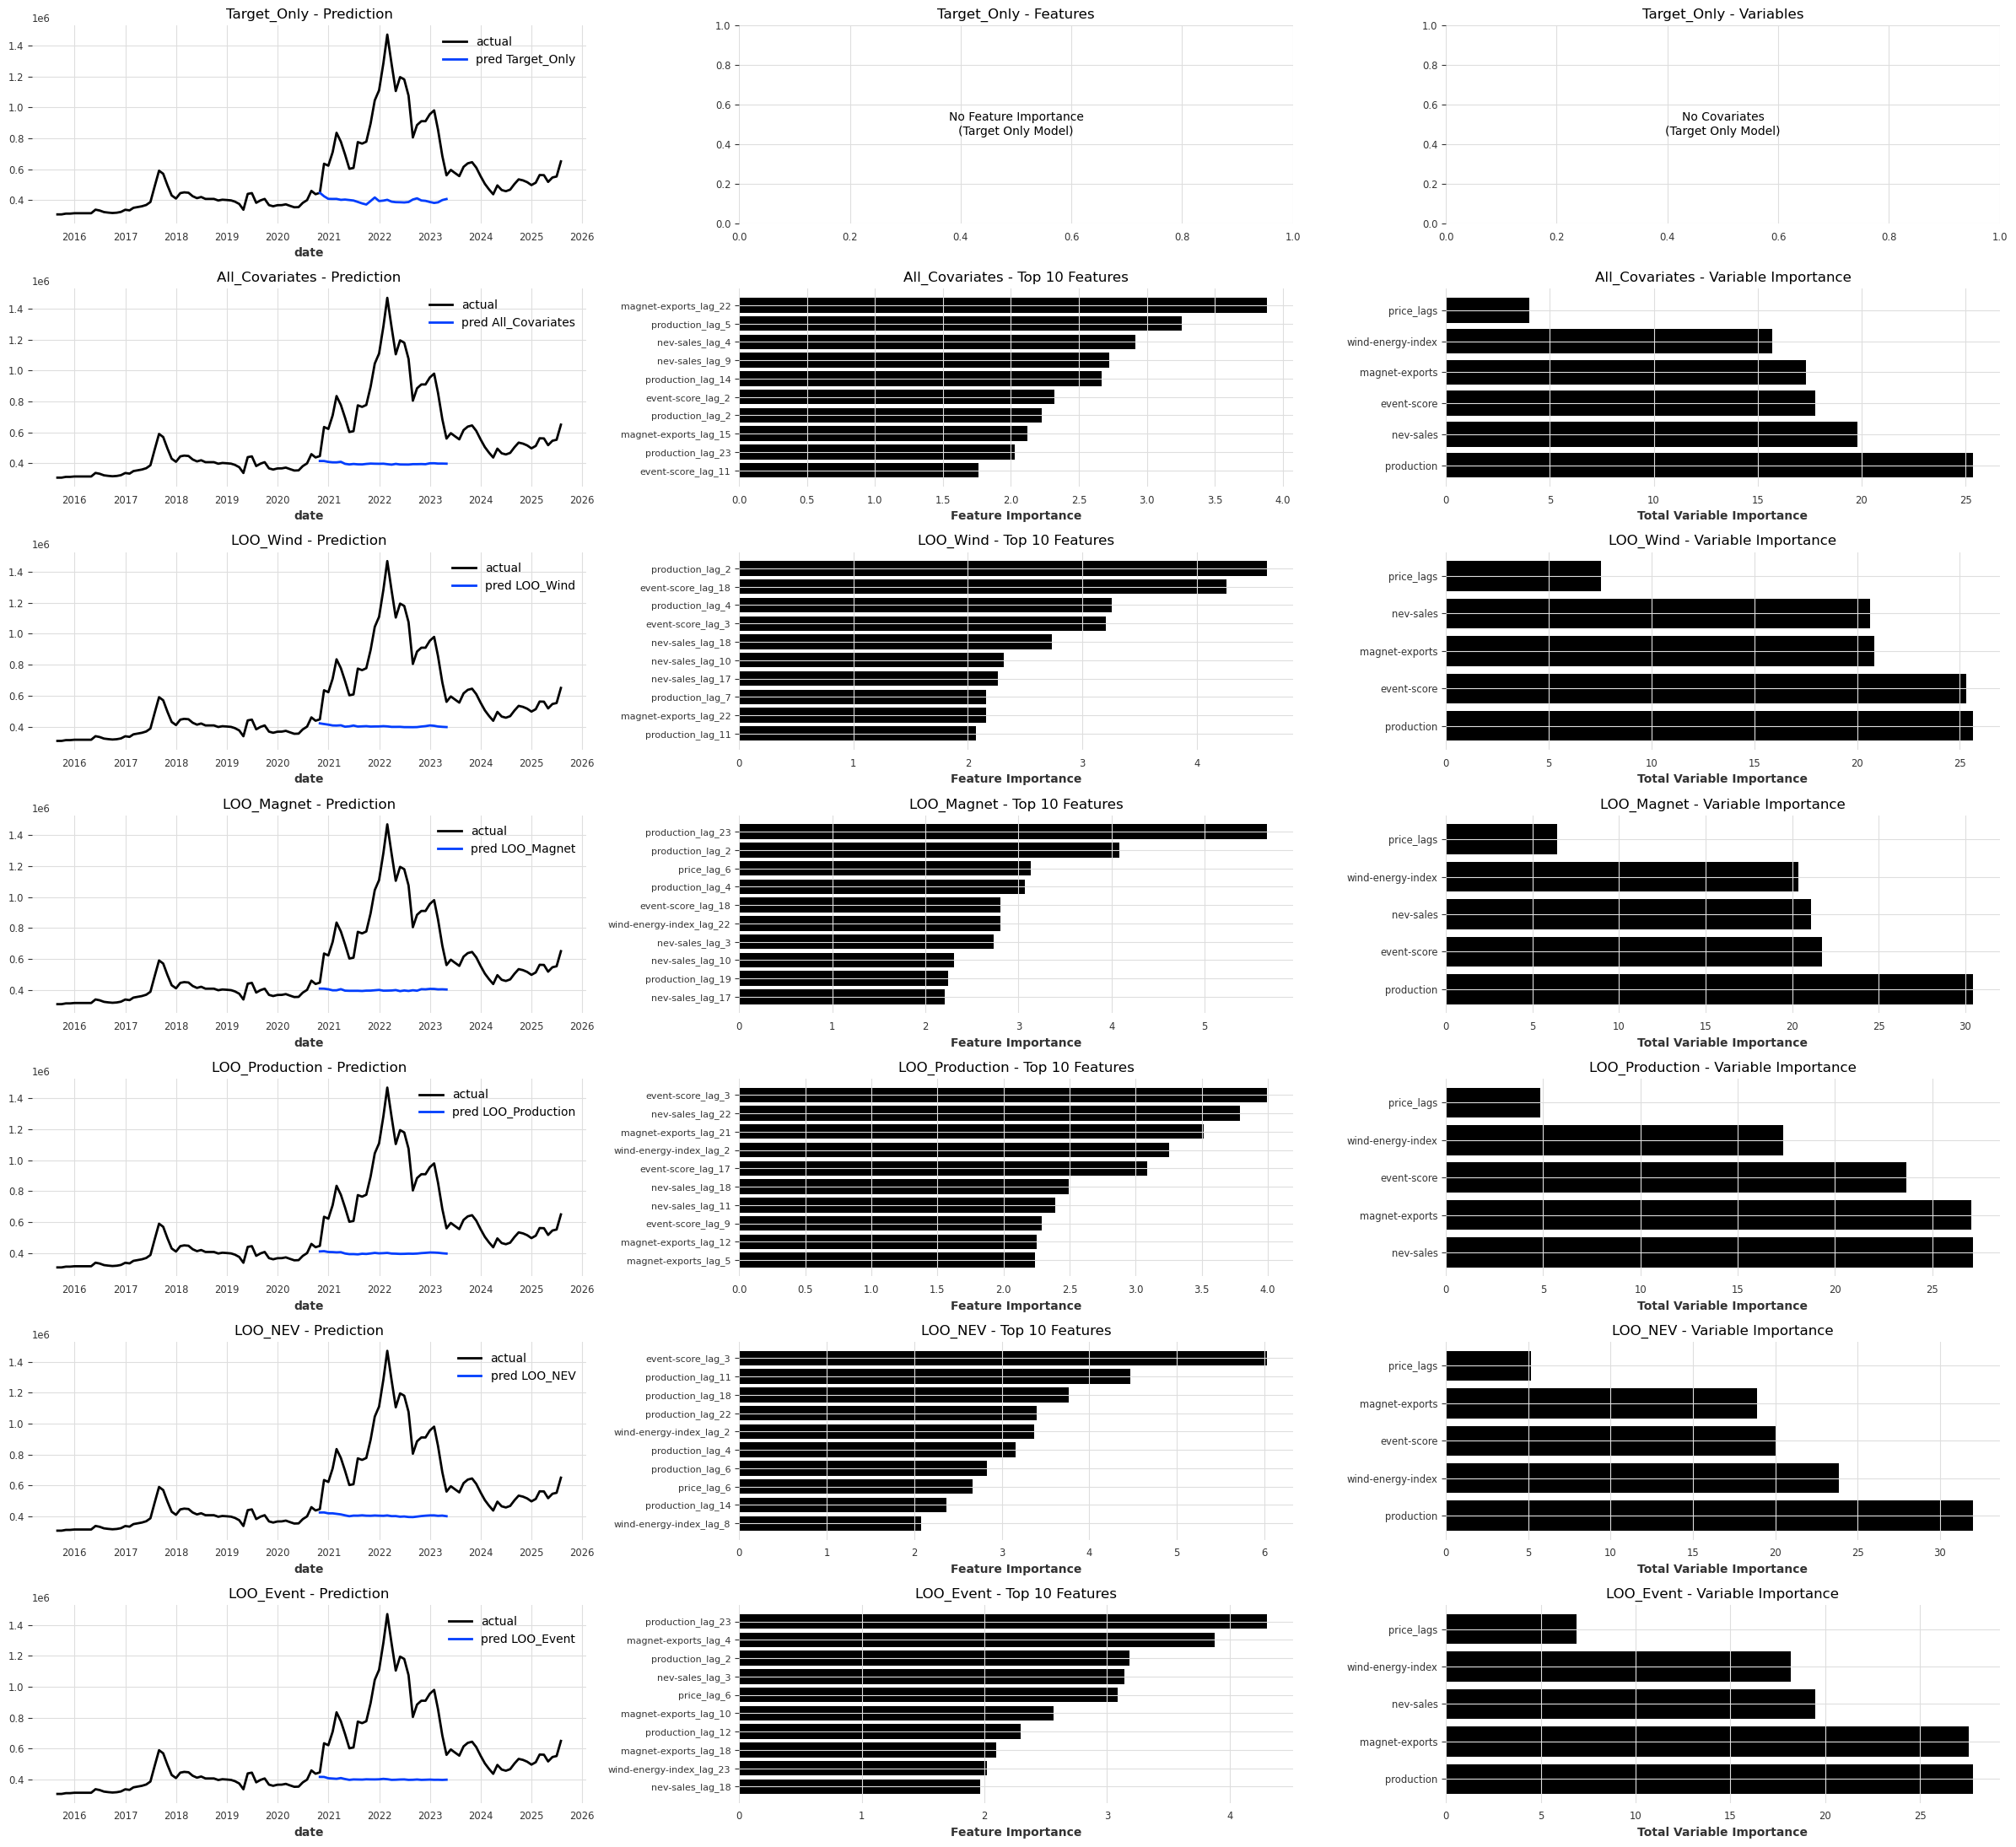

In [9]:
input = 6 # 별 차이 없음
output = 1 # 별 차이 없음
lag_cov = 24 # 별 차이 없음
train_set = train
test_set = val
cov_set = train_cov.concatenate(val_cov)
pred_len = len(test_set)
Model = CatBoostModel

C_0 = Model(lags=input, output_chunk_length=output)
C_0.fit(train_set)
C_all = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_all.fit(train_set, past_covariates=cov_set)
C_loo_w = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_loo_w.fit(train_set, past_covariates=cov_set[['production', 'nev-sales', 'magnet-exports', 'event-score']])
C_loo_m = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_loo_m.fit(train_set, past_covariates=cov_set[['production', 'nev-sales', 'wind-energy-index', 'event-score']])
C_loo_p = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_loo_p.fit(train_set, past_covariates=cov_set[['nev-sales', 'wind-energy-index', 'magnet-exports', 'event-score']])
C_loo_n = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_loo_n.fit(train_set, past_covariates=cov_set[['production', 'wind-energy-index', 'magnet-exports', 'event-score']])
C_loo_e = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_loo_e.fit(train_set, past_covariates=cov_set[['production', 'nev-sales', 'wind-energy-index', 'magnet-exports']])

pred_C_0 = C_0.predict(n=pred_len)
pred_C_all = C_all.predict(n=pred_len)
pred_C_loo_w = C_loo_w.predict(n=pred_len)
pred_C_loo_m = C_loo_m.predict(n=pred_len)
pred_C_loo_p = C_loo_p.predict(n=pred_len)
pred_C_loo_n = C_loo_n.predict(n=pred_len)
pred_C_loo_e = C_loo_e.predict(n=pred_len)

# 평가 실행
predictions_dict = {
    'Target_Only': pred_C_0,
    'All_Covariates': pred_C_all,
    'LOO_Wind': pred_C_loo_w,
    'LOO_Magnet': pred_C_loo_m,
    'LOO_Production': pred_C_loo_p,
    'LOO_NEV': pred_C_loo_n,
    'LOO_Event': pred_C_loo_e
}
evaluate_predictions(Model, train_set, test_set, predictions_dict)

# 예측결과 및 변수 중요도
models = [C_0, C_all, C_loo_w, C_loo_m, C_loo_p, C_loo_n, C_loo_e]
model_names = ['Target_Only', 'All_Covariates', 'LOO_Wind', 'LOO_Magnet', 'LOO_Production', 'LOO_NEV', 'LOO_Event']
predictions = [pred_C_0, pred_C_all, pred_C_loo_w, pred_C_loo_m, pred_C_loo_p, pred_C_loo_n, pred_C_loo_e]
model_vars = [
    [],  # C_0: target only
    ['production', 'nev-sales', 'wind-energy-index', 'magnet-exports', 'event-score'],  # C_all
    ['production', 'nev-sales', 'magnet-exports', 'event-score'],  # C_loo_w (no wind)
    ['production', 'nev-sales', 'wind-energy-index', 'event-score'],  # C_loo_m (no magnet)
    ['nev-sales', 'wind-energy-index', 'magnet-exports', 'event-score'],  # C_loo_p (no production)
    ['production', 'wind-energy-index', 'magnet-exports', 'event-score'],  # C_loo_n (no nev)
    ['production', 'nev-sales', 'wind-energy-index', 'magnet-exports']  # C_loo_e (no event)
]
plot_model_analysis(models, model_names, predictions, model_vars, input, lag_cov)

#### R2 COVID→Recovery
- C0: 타깃 단독(price only)
- Call: 모든 공변량 포함(이벤트는 future_cov로만 사용 가능 시 별도 처리)
- LOO_w/m/p/n/e: Call에서 해당 변수만 제거

`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.
`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.
`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.
`predict()` was called with `n > output_

<class 'darts.models.forecasting.random_forest.RandomForestModel'> 예측 성능 평가 결과
Target_Only          | MAE: 167868.7037 | RMSE: 178869.3979 | MAPE:  32.67% | MASE:  0.4284
All_Covariates       | MAE: 350705.0000 | RMSE: 376186.6050 | MAPE:  68.12% | MASE:  0.8950
LOO_Wind             | MAE: 376353.7037 | RMSE: 405018.1170 | MAPE:  73.12% | MASE:  0.9605
LOO_Magnet           | MAE: 382412.2222 | RMSE: 413870.5632 | MAPE:  74.50% | MASE:  0.9759
LOO_Production       | MAE: 340077.9630 | RMSE: 365553.1672 | MAPE:  66.11% | MASE:  0.8679
LOO_NEV              | MAE: 347160.7407 | RMSE: 374307.7531 | MAPE:  67.57% | MASE:  0.8860
LOO_Event            | MAE: 150485.3704 | RMSE: 160105.7021 | MAPE:  29.09% | MASE:  0.3840


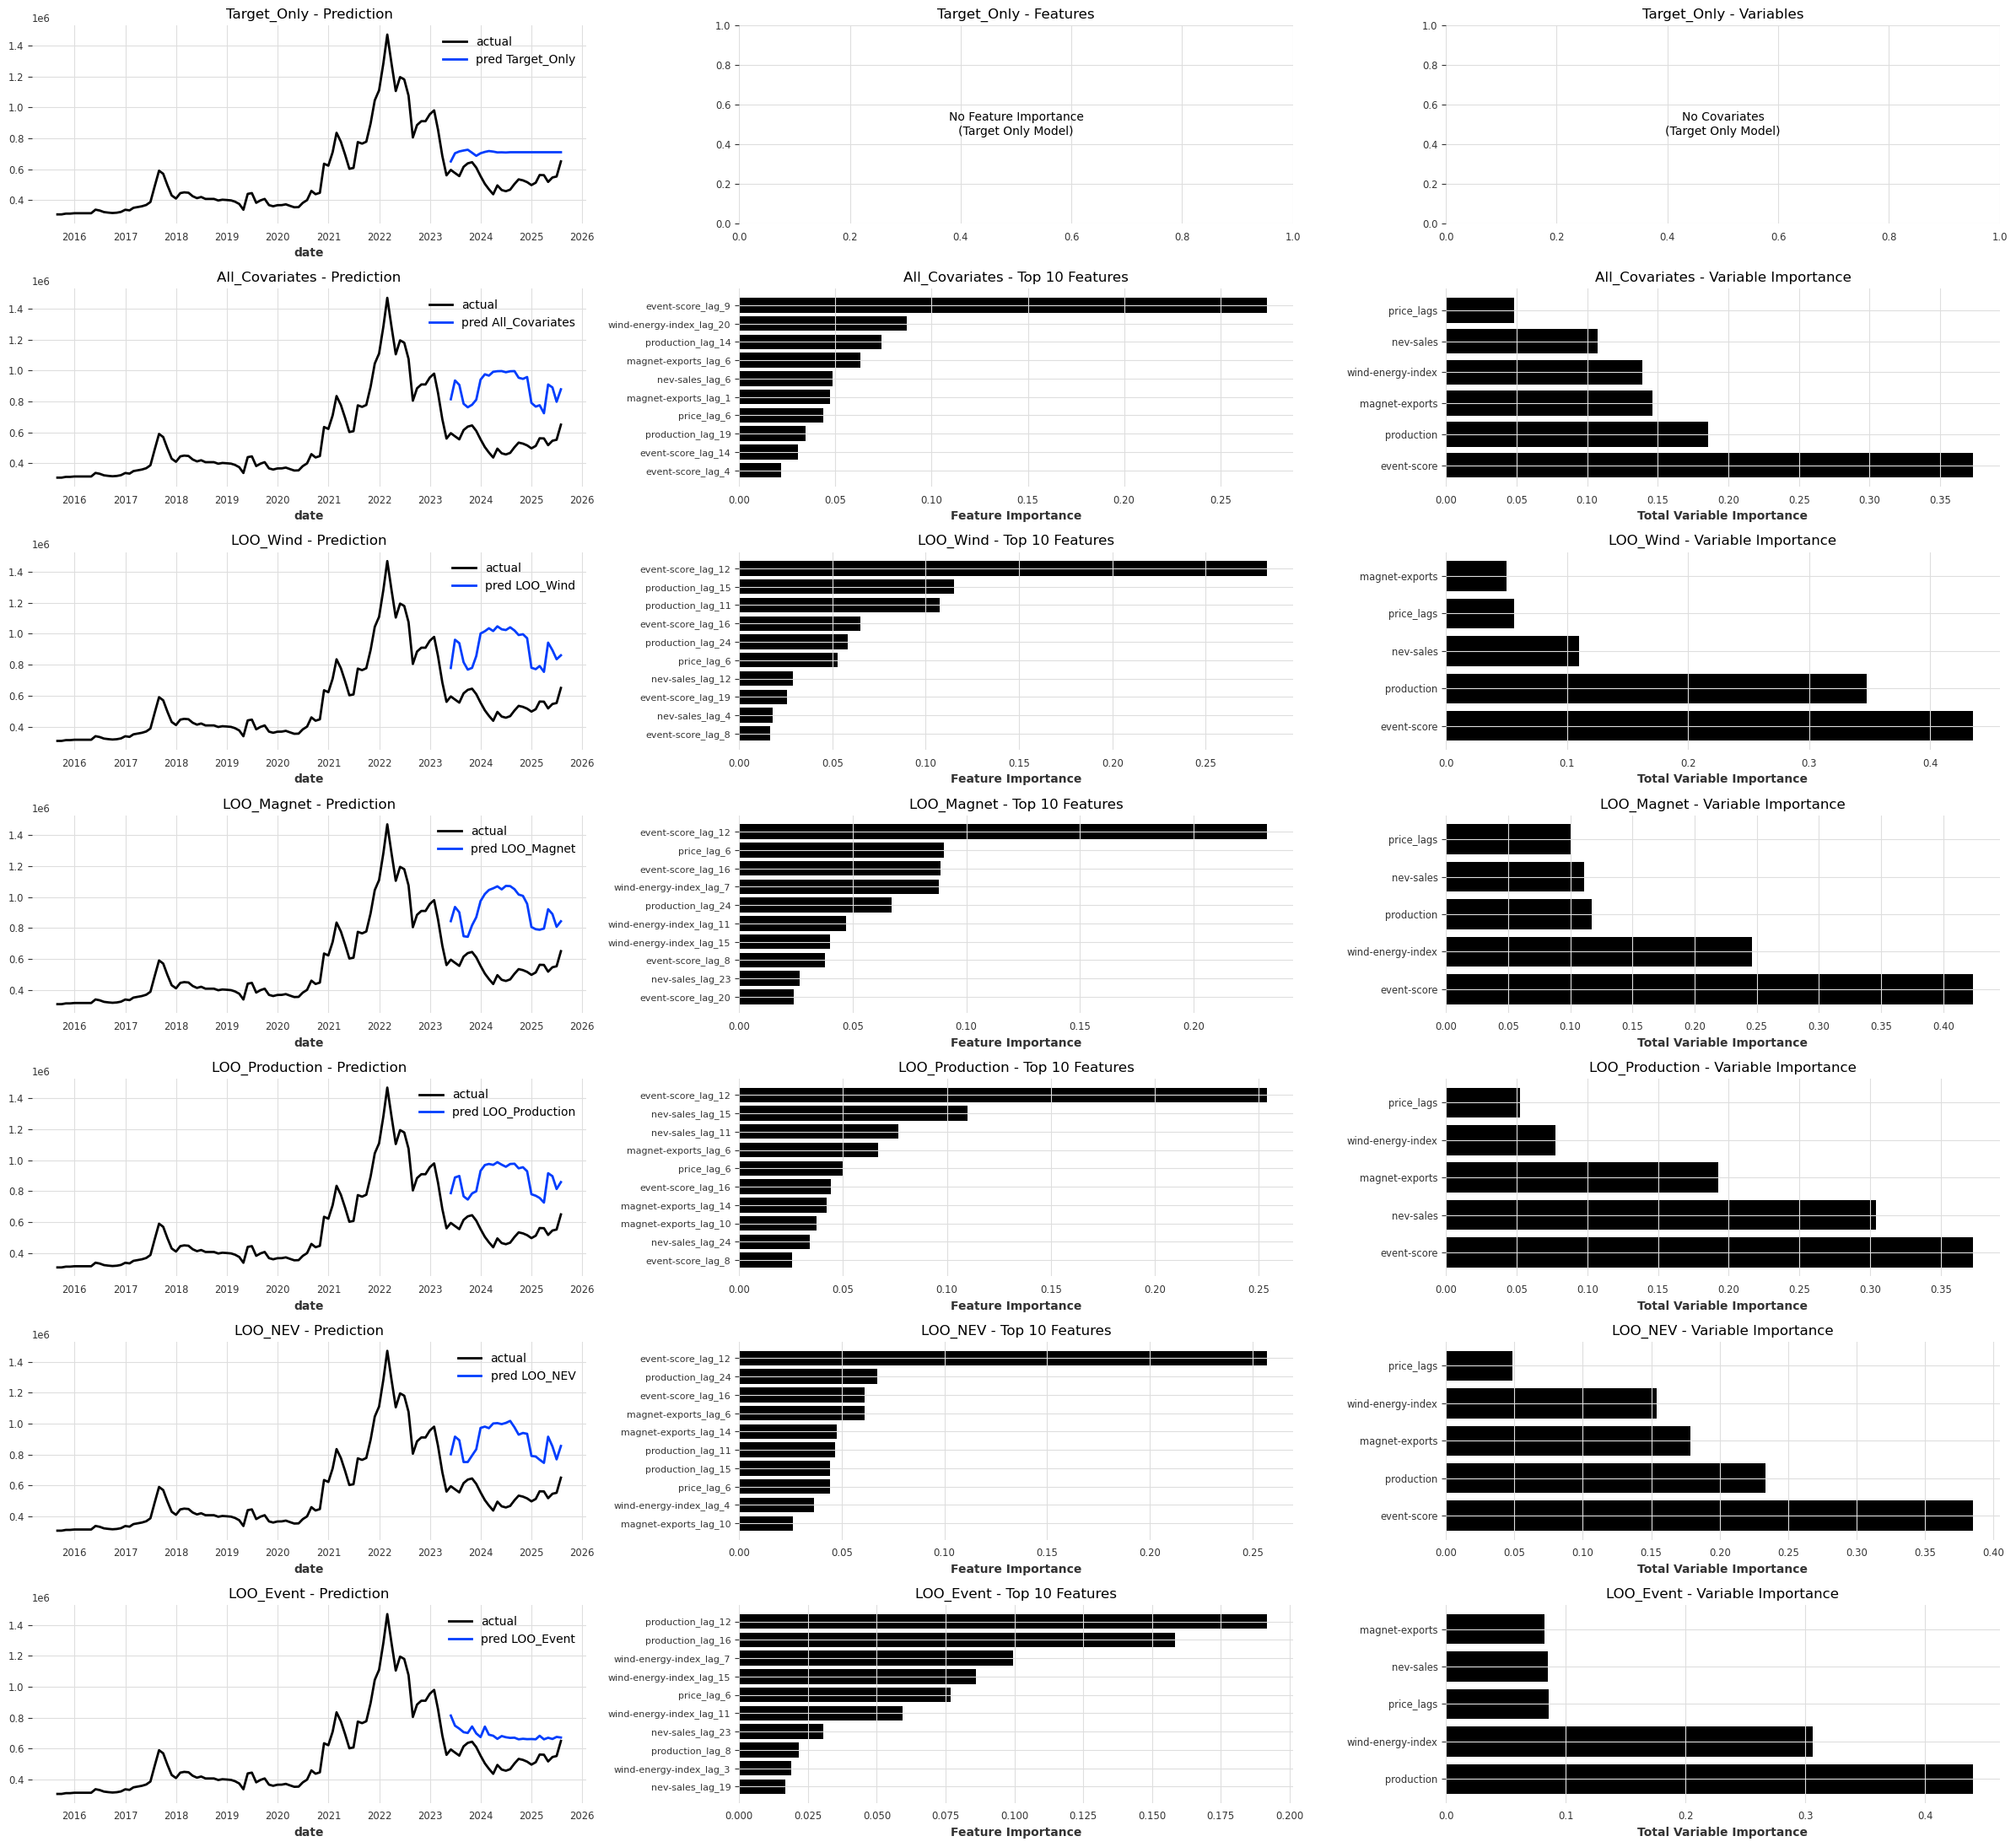

In [10]:
input = 6 # 이건 3, 6 정도 작아야 좋음. 6이 best
output = 1 # 이건 3도 안 됨. 1해야 됨
lag_cov = 24 # 이건 12이상이 좋고, 24가 best
train_set = val
test_set = test
cov_set = train_cov.concatenate(val_cov).concatenate(test_cov)
pred_len = len(test_set)
Model = RandomForestModel

C_0 = Model(lags=input, output_chunk_length=output)
C_0.fit(train_set)
C_all = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_all.fit(train_set, past_covariates=cov_set)
C_loo_w = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_loo_w.fit(train_set, past_covariates=cov_set[['production', 'nev-sales', 'magnet-exports', 'event-score']])
C_loo_m = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_loo_m.fit(train_set, past_covariates=cov_set[['production', 'nev-sales', 'wind-energy-index', 'event-score']])
C_loo_p = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_loo_p.fit(train_set, past_covariates=cov_set[['nev-sales', 'wind-energy-index', 'magnet-exports', 'event-score']])
C_loo_n = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_loo_n.fit(train_set, past_covariates=cov_set[['production', 'wind-energy-index', 'magnet-exports', 'event-score']])
C_loo_e = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_loo_e.fit(train_set, past_covariates=cov_set[['production', 'nev-sales', 'wind-energy-index', 'magnet-exports']])

pred_C_0 = C_0.predict(n=pred_len)
pred_C_all = C_all.predict(n=pred_len)
pred_C_loo_w = C_loo_w.predict(n=pred_len)
pred_C_loo_m = C_loo_m.predict(n=pred_len)
pred_C_loo_p = C_loo_p.predict(n=pred_len)
pred_C_loo_n = C_loo_n.predict(n=pred_len)
pred_C_loo_e = C_loo_e.predict(n=pred_len)

# 평가 실행
predictions_dict = {
    'Target_Only': pred_C_0,
    'All_Covariates': pred_C_all,
    'LOO_Wind': pred_C_loo_w,
    'LOO_Magnet': pred_C_loo_m,
    'LOO_Production': pred_C_loo_p,
    'LOO_NEV': pred_C_loo_n,
    'LOO_Event': pred_C_loo_e
}
evaluate_predictions(Model, train_set, test_set, predictions_dict)

# 예측결과 및 변수 중요도
models = [C_0, C_all, C_loo_w, C_loo_m, C_loo_p, C_loo_n, C_loo_e]
model_names = ['Target_Only', 'All_Covariates', 'LOO_Wind', 'LOO_Magnet', 'LOO_Production', 'LOO_NEV', 'LOO_Event']
predictions = [pred_C_0, pred_C_all, pred_C_loo_w, pred_C_loo_m, pred_C_loo_p, pred_C_loo_n, pred_C_loo_e]
model_vars = [
    [],  # C_0: target only
    ['production', 'nev-sales', 'wind-energy-index', 'magnet-exports', 'event-score'],  # C_all
    ['production', 'nev-sales', 'magnet-exports', 'event-score'],  # C_loo_w (no wind)
    ['production', 'nev-sales', 'wind-energy-index', 'event-score'],  # C_loo_m (no magnet)
    ['nev-sales', 'wind-energy-index', 'magnet-exports', 'event-score'],  # C_loo_p (no production)
    ['production', 'wind-energy-index', 'magnet-exports', 'event-score'],  # C_loo_n (no nev)
    ['production', 'nev-sales', 'wind-energy-index', 'magnet-exports']  # C_loo_e (no event)
]
plot_model_analysis(models, model_names, predictions, model_vars, input, lag_cov)

`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.
`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.
`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.
`predict()` was called with `n > output_

<class 'darts.models.forecasting.xgboost.XGBModel'> 예측 성능 평가 결과
Target_Only          | MAE: 387189.4861 | RMSE: 466790.4141 | MAPE:  75.44% | MASE:  0.9881
All_Covariates       | MAE: 331560.7986 | RMSE: 379934.6943 | MAPE:  64.75% | MASE:  0.8462
LOO_Wind             | MAE: 405048.7500 | RMSE: 457296.6194 | MAPE:  78.92% | MASE:  1.0337
LOO_Magnet           | MAE: 534561.1991 | RMSE: 601359.3256 | MAPE: 104.09% | MASE:  1.3642
LOO_Production       | MAE: 332387.1296 | RMSE: 382263.7510 | MAPE:  64.95% | MASE:  0.8483
LOO_NEV              | MAE: 327170.8449 | RMSE: 378487.4318 | MAPE:  64.05% | MASE:  0.8350
LOO_Event            | MAE: 78405.6806 | RMSE: 89116.1826 | MAPE:  15.14% | MASE:  0.2001


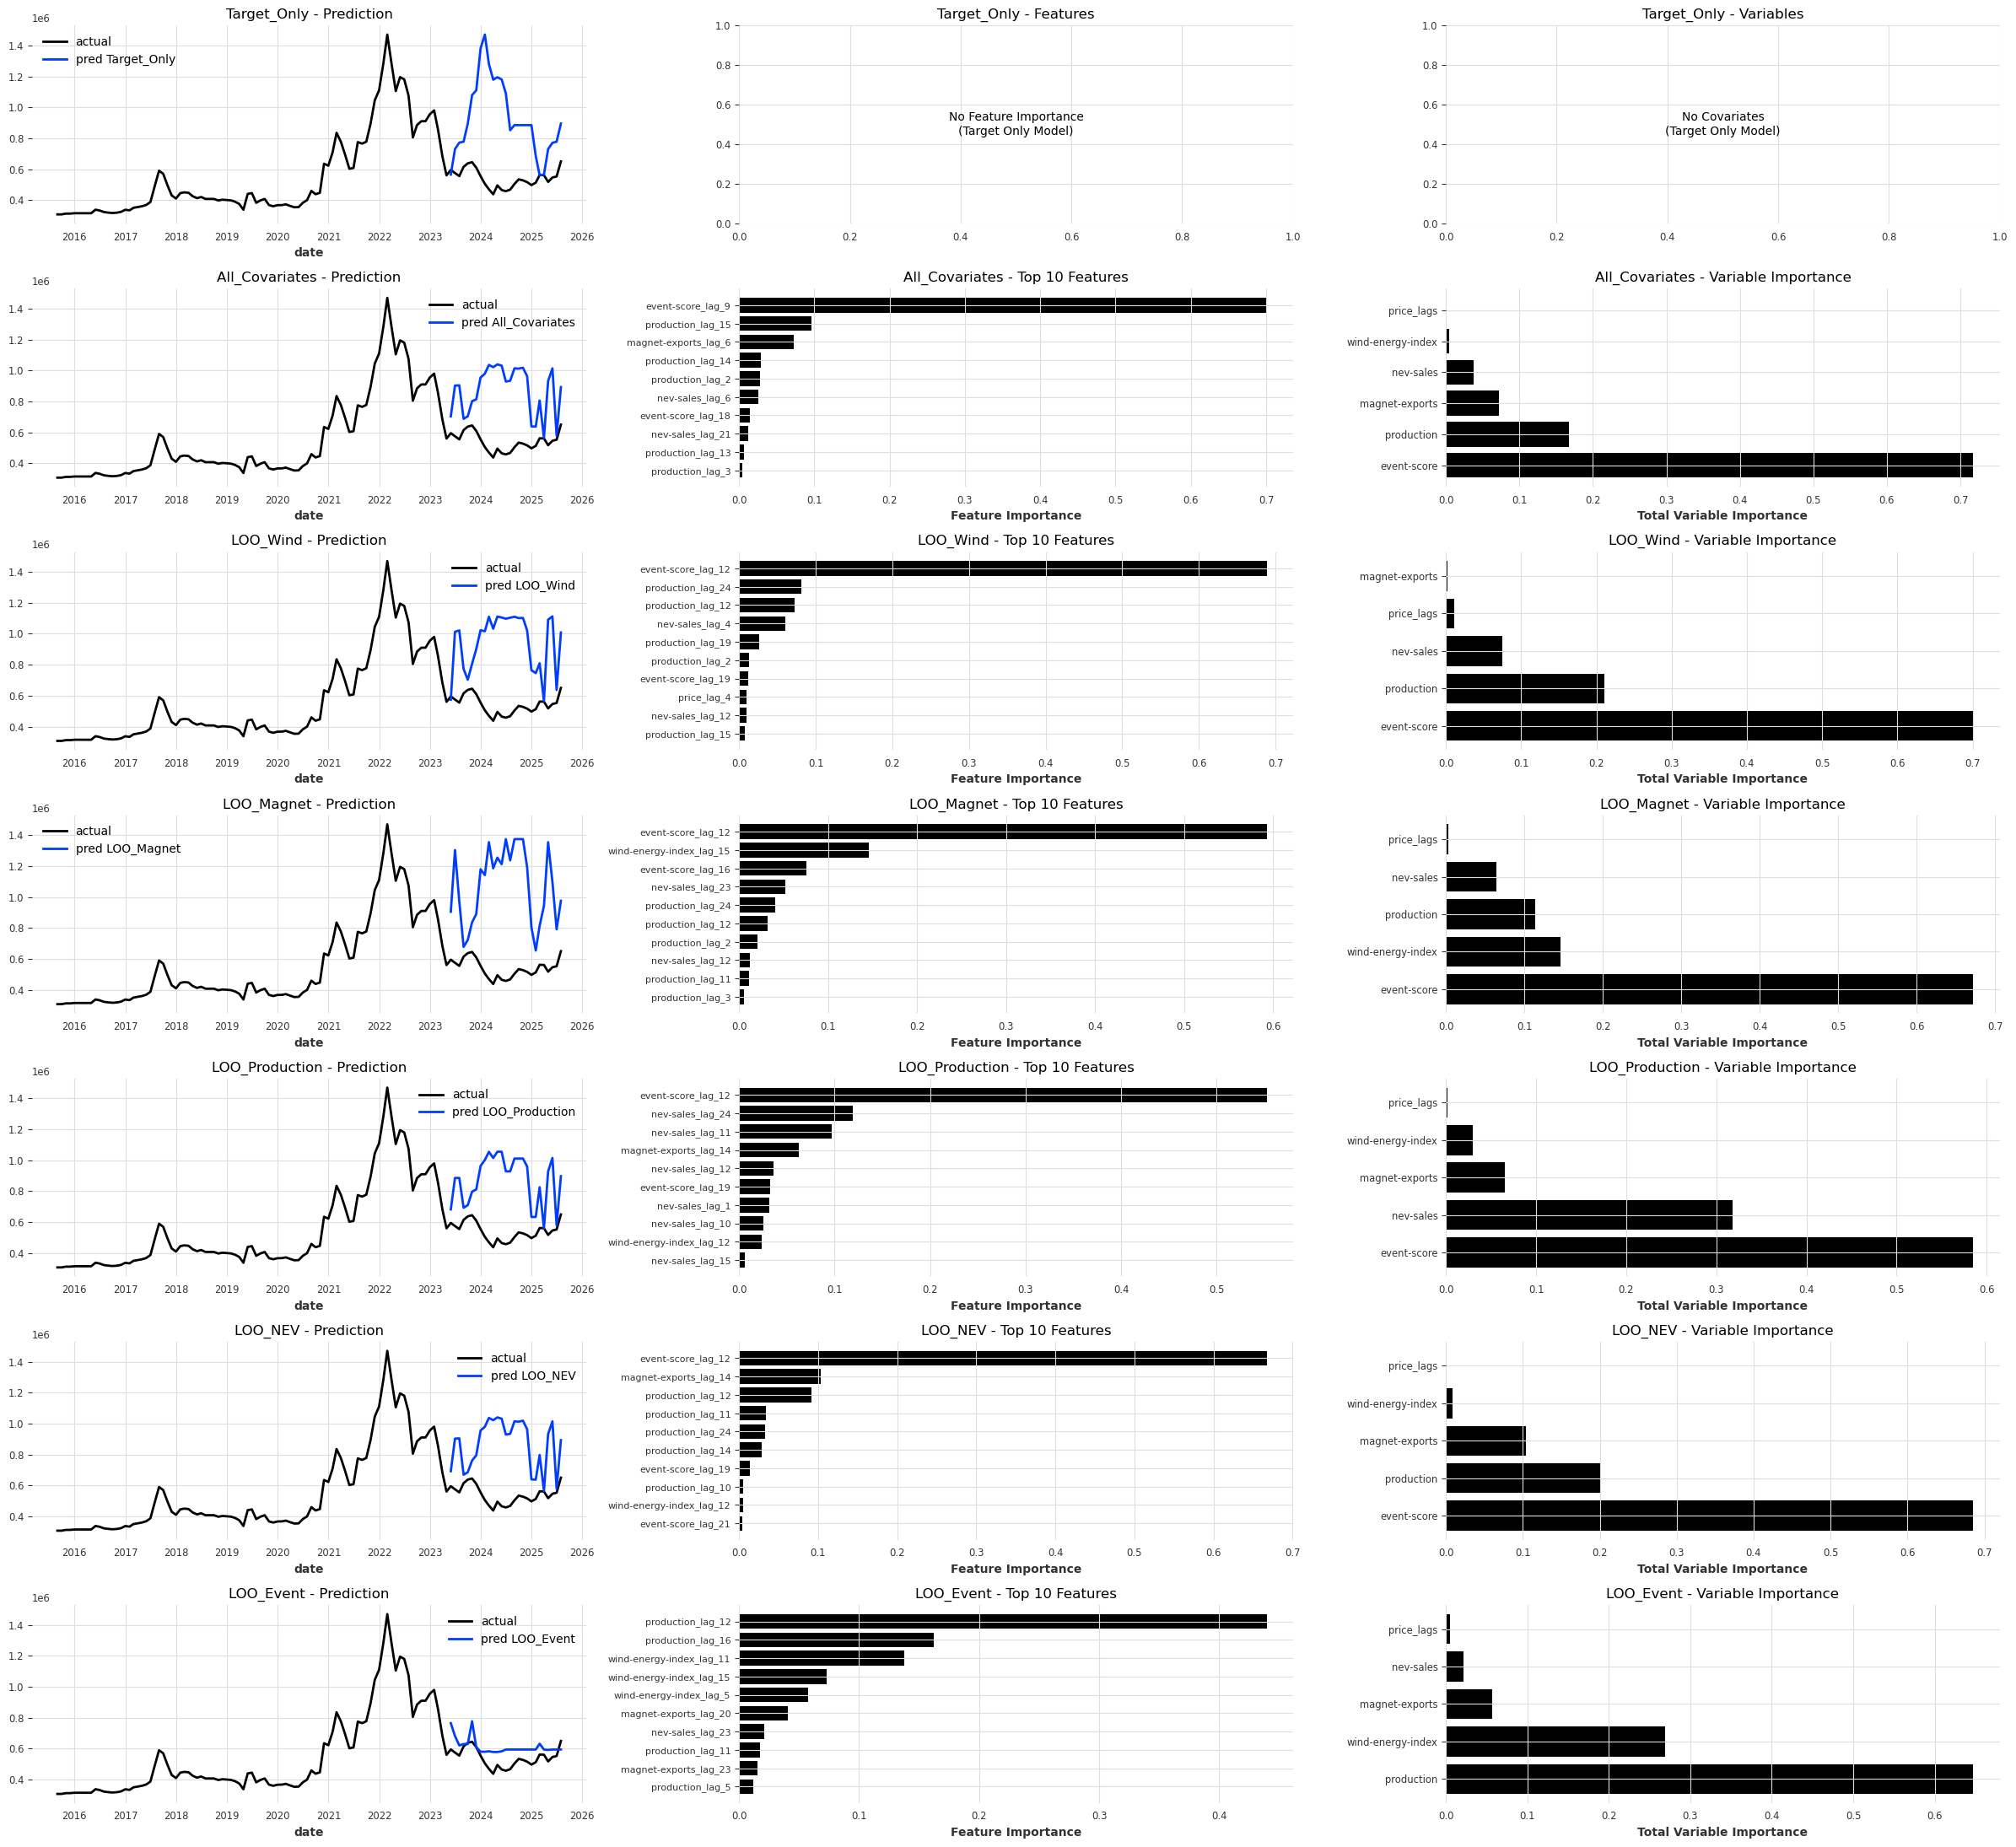

In [11]:
input = 6 # 이건 3, 6 정도 작아야 좋음. 6이 best
output = 1 # 이건 3도 안 됨. 1해야 됨
lag_cov = 24 # 이건 12이상이 좋고, 24가 best
train_set = val
test_set = test
cov_set = train_cov.concatenate(val_cov).concatenate(test_cov)
pred_len = len(test_set)
Model = XGBModel

C_0 = Model(lags=input, output_chunk_length=output)
C_0.fit(train_set)
C_all = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_all.fit(train_set, past_covariates=cov_set)
C_loo_w = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_loo_w.fit(train_set, past_covariates=cov_set[['production', 'nev-sales', 'magnet-exports', 'event-score']])
C_loo_m = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_loo_m.fit(train_set, past_covariates=cov_set[['production', 'nev-sales', 'wind-energy-index', 'event-score']])
C_loo_p = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_loo_p.fit(train_set, past_covariates=cov_set[['nev-sales', 'wind-energy-index', 'magnet-exports', 'event-score']])
C_loo_n = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_loo_n.fit(train_set, past_covariates=cov_set[['production', 'wind-energy-index', 'magnet-exports', 'event-score']])
C_loo_e = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_loo_e.fit(train_set, past_covariates=cov_set[['production', 'nev-sales', 'wind-energy-index', 'magnet-exports']])

pred_C_0 = C_0.predict(n=pred_len)
pred_C_all = C_all.predict(n=pred_len)
pred_C_loo_w = C_loo_w.predict(n=pred_len)
pred_C_loo_m = C_loo_m.predict(n=pred_len)
pred_C_loo_p = C_loo_p.predict(n=pred_len)
pred_C_loo_n = C_loo_n.predict(n=pred_len)
pred_C_loo_e = C_loo_e.predict(n=pred_len)

# 평가 실행
predictions_dict = {
    'Target_Only': pred_C_0,
    'All_Covariates': pred_C_all,
    'LOO_Wind': pred_C_loo_w,
    'LOO_Magnet': pred_C_loo_m,
    'LOO_Production': pred_C_loo_p,
    'LOO_NEV': pred_C_loo_n,
    'LOO_Event': pred_C_loo_e
}
evaluate_predictions(Model, train_set, test_set, predictions_dict)

# 예측결과 및 변수 중요도
models = [C_0, C_all, C_loo_w, C_loo_m, C_loo_p, C_loo_n, C_loo_e]
model_names = ['Target_Only', 'All_Covariates', 'LOO_Wind', 'LOO_Magnet', 'LOO_Production', 'LOO_NEV', 'LOO_Event']
predictions = [pred_C_0, pred_C_all, pred_C_loo_w, pred_C_loo_m, pred_C_loo_p, pred_C_loo_n, pred_C_loo_e]
model_vars = [
    [],  # C_0: target only
    ['production', 'nev-sales', 'wind-energy-index', 'magnet-exports', 'event-score'],  # C_all
    ['production', 'nev-sales', 'magnet-exports', 'event-score'],  # C_loo_w (no wind)
    ['production', 'nev-sales', 'wind-energy-index', 'event-score'],  # C_loo_m (no magnet)
    ['nev-sales', 'wind-energy-index', 'magnet-exports', 'event-score'],  # C_loo_p (no production)
    ['production', 'wind-energy-index', 'magnet-exports', 'event-score'],  # C_loo_n (no nev)
    ['production', 'nev-sales', 'wind-energy-index', 'magnet-exports']  # C_loo_e (no event)
]
plot_model_analysis(models, model_names, predictions, model_vars, input, lag_cov)

e:\Programs\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\Programs\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\Programs\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\Programs\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\Programs\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\Programs\anaconda3\Lib\site-packages\sklearn\utils\v

[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 25, number of used features: 0
[LightGBM] [Info] Start training from score 936320.000000
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the

e:\Programs\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\Programs\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\Programs\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\Programs\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\Programs\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\Programs\anaconda3\Lib\site-packages\sklearn\utils\v

<class 'darts.models.forecasting.lgbm.LightGBMModel'> 예측 성능 평가 결과
Target_Only          | MAE: 396875.5556 | RMSE: 401075.4175 | MAPE:  75.56% | MASE:  1.0128
All_Covariates       | MAE: 396875.5556 | RMSE: 401075.4175 | MAPE:  75.56% | MASE:  1.0128
LOO_Wind             | MAE: 396875.5556 | RMSE: 401075.4175 | MAPE:  75.56% | MASE:  1.0128
LOO_Magnet           | MAE: 396875.5556 | RMSE: 401075.4175 | MAPE:  75.56% | MASE:  1.0128
LOO_Production       | MAE: 396875.5556 | RMSE: 401075.4175 | MAPE:  75.56% | MASE:  1.0128
LOO_NEV              | MAE: 396875.5556 | RMSE: 401075.4175 | MAPE:  75.56% | MASE:  1.0128
LOO_Event            | MAE: 396875.5556 | RMSE: 401075.4175 | MAPE:  75.56% | MASE:  1.0128


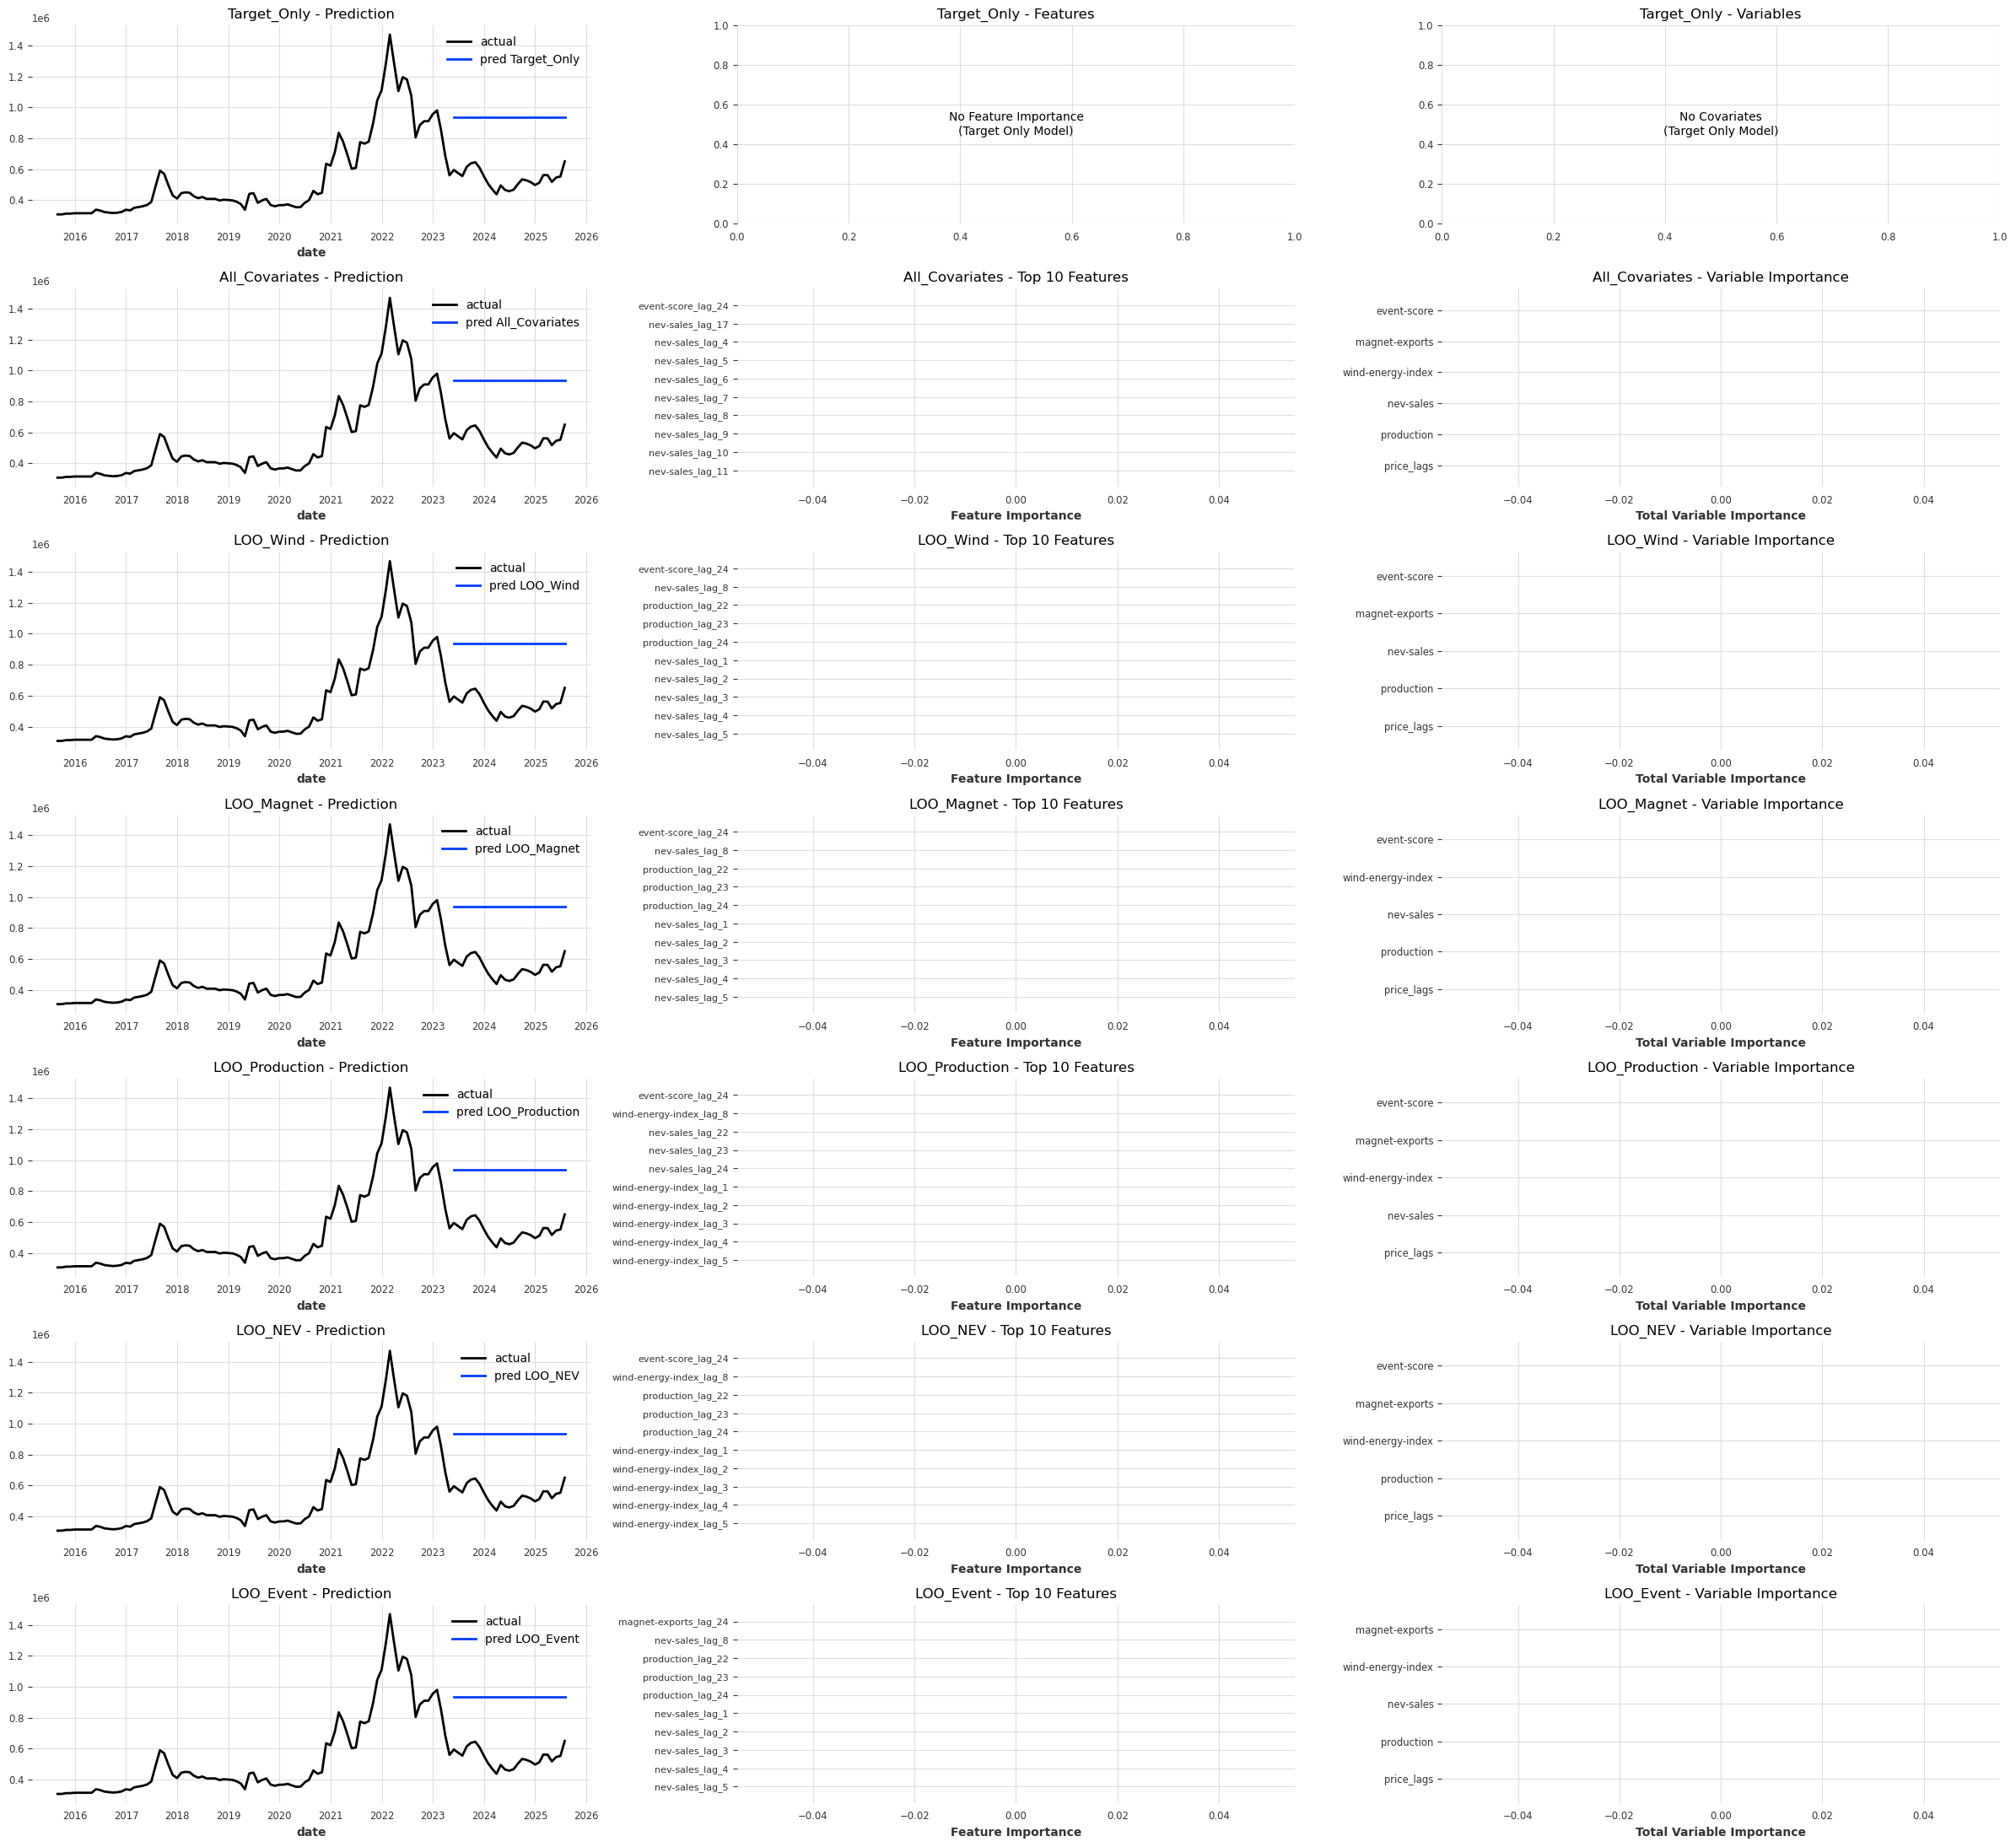

In [12]:
input = 6 # 이건 3, 6 정도 작아야 좋음. 6이 best
output = 1 # 이건 3도 안 됨. 1해야 됨
lag_cov = 24 # 이건 12이상이 좋고, 24가 best
train_set = val
test_set = test
cov_set = train_cov.concatenate(val_cov).concatenate(test_cov)
pred_len = len(test_set)
Model = LightGBMModel

C_0 = Model(lags=input, output_chunk_length=output)
C_0.fit(train_set)
C_all = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_all.fit(train_set, past_covariates=cov_set)
C_loo_w = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_loo_w.fit(train_set, past_covariates=cov_set[['production', 'nev-sales', 'magnet-exports', 'event-score']])
C_loo_m = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_loo_m.fit(train_set, past_covariates=cov_set[['production', 'nev-sales', 'wind-energy-index', 'event-score']])
C_loo_p = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_loo_p.fit(train_set, past_covariates=cov_set[['nev-sales', 'wind-energy-index', 'magnet-exports', 'event-score']])
C_loo_n = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_loo_n.fit(train_set, past_covariates=cov_set[['production', 'wind-energy-index', 'magnet-exports', 'event-score']])
C_loo_e = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_loo_e.fit(train_set, past_covariates=cov_set[['production', 'nev-sales', 'wind-energy-index', 'magnet-exports']])

pred_C_0 = C_0.predict(n=pred_len)
pred_C_all = C_all.predict(n=pred_len)
pred_C_loo_w = C_loo_w.predict(n=pred_len)
pred_C_loo_m = C_loo_m.predict(n=pred_len)
pred_C_loo_p = C_loo_p.predict(n=pred_len)
pred_C_loo_n = C_loo_n.predict(n=pred_len)
pred_C_loo_e = C_loo_e.predict(n=pred_len)

# 평가 실행
predictions_dict = {
    'Target_Only': pred_C_0,
    'All_Covariates': pred_C_all,
    'LOO_Wind': pred_C_loo_w,
    'LOO_Magnet': pred_C_loo_m,
    'LOO_Production': pred_C_loo_p,
    'LOO_NEV': pred_C_loo_n,
    'LOO_Event': pred_C_loo_e
}
evaluate_predictions(Model, train_set, test_set, predictions_dict)

# 예측결과 및 변수 중요도
models = [C_0, C_all, C_loo_w, C_loo_m, C_loo_p, C_loo_n, C_loo_e]
model_names = ['Target_Only', 'All_Covariates', 'LOO_Wind', 'LOO_Magnet', 'LOO_Production', 'LOO_NEV', 'LOO_Event']
predictions = [pred_C_0, pred_C_all, pred_C_loo_w, pred_C_loo_m, pred_C_loo_p, pred_C_loo_n, pred_C_loo_e]
model_vars = [
    [],  # C_0: target only
    ['production', 'nev-sales', 'wind-energy-index', 'magnet-exports', 'event-score'],  # C_all
    ['production', 'nev-sales', 'magnet-exports', 'event-score'],  # C_loo_w (no wind)
    ['production', 'nev-sales', 'wind-energy-index', 'event-score'],  # C_loo_m (no magnet)
    ['nev-sales', 'wind-energy-index', 'magnet-exports', 'event-score'],  # C_loo_p (no production)
    ['production', 'wind-energy-index', 'magnet-exports', 'event-score'],  # C_loo_n (no nev)
    ['production', 'nev-sales', 'wind-energy-index', 'magnet-exports']  # C_loo_e (no event)
]
plot_model_analysis(models, model_names, predictions, model_vars, input, lag_cov)

`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.
`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.
`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.
`predict()` was called with `n > output_

<class 'darts.models.forecasting.catboost_model.CatBoostModel'> 예측 성능 평가 결과
Target_Only          | MAE: 262754.3846 | RMSE: 277254.2643 | MAPE:  49.89% | MASE:  0.6706
All_Covariates       | MAE: 338478.6609 | RMSE: 350316.0126 | MAPE:  65.21% | MASE:  0.8638
LOO_Wind             | MAE: 360683.9860 | RMSE: 373517.5554 | MAPE:  69.49% | MASE:  0.9205
LOO_Magnet           | MAE: 359545.0347 | RMSE: 374487.5013 | MAPE:  69.41% | MASE:  0.9176
LOO_Production       | MAE: 327340.5026 | RMSE: 341289.5710 | MAPE:  63.16% | MASE:  0.8354
LOO_NEV              | MAE: 337989.1205 | RMSE: 352890.1139 | MAPE:  65.30% | MASE:  0.8626
LOO_Event            | MAE: 266239.8464 | RMSE: 273035.1437 | MAPE:  51.04% | MASE:  0.6795


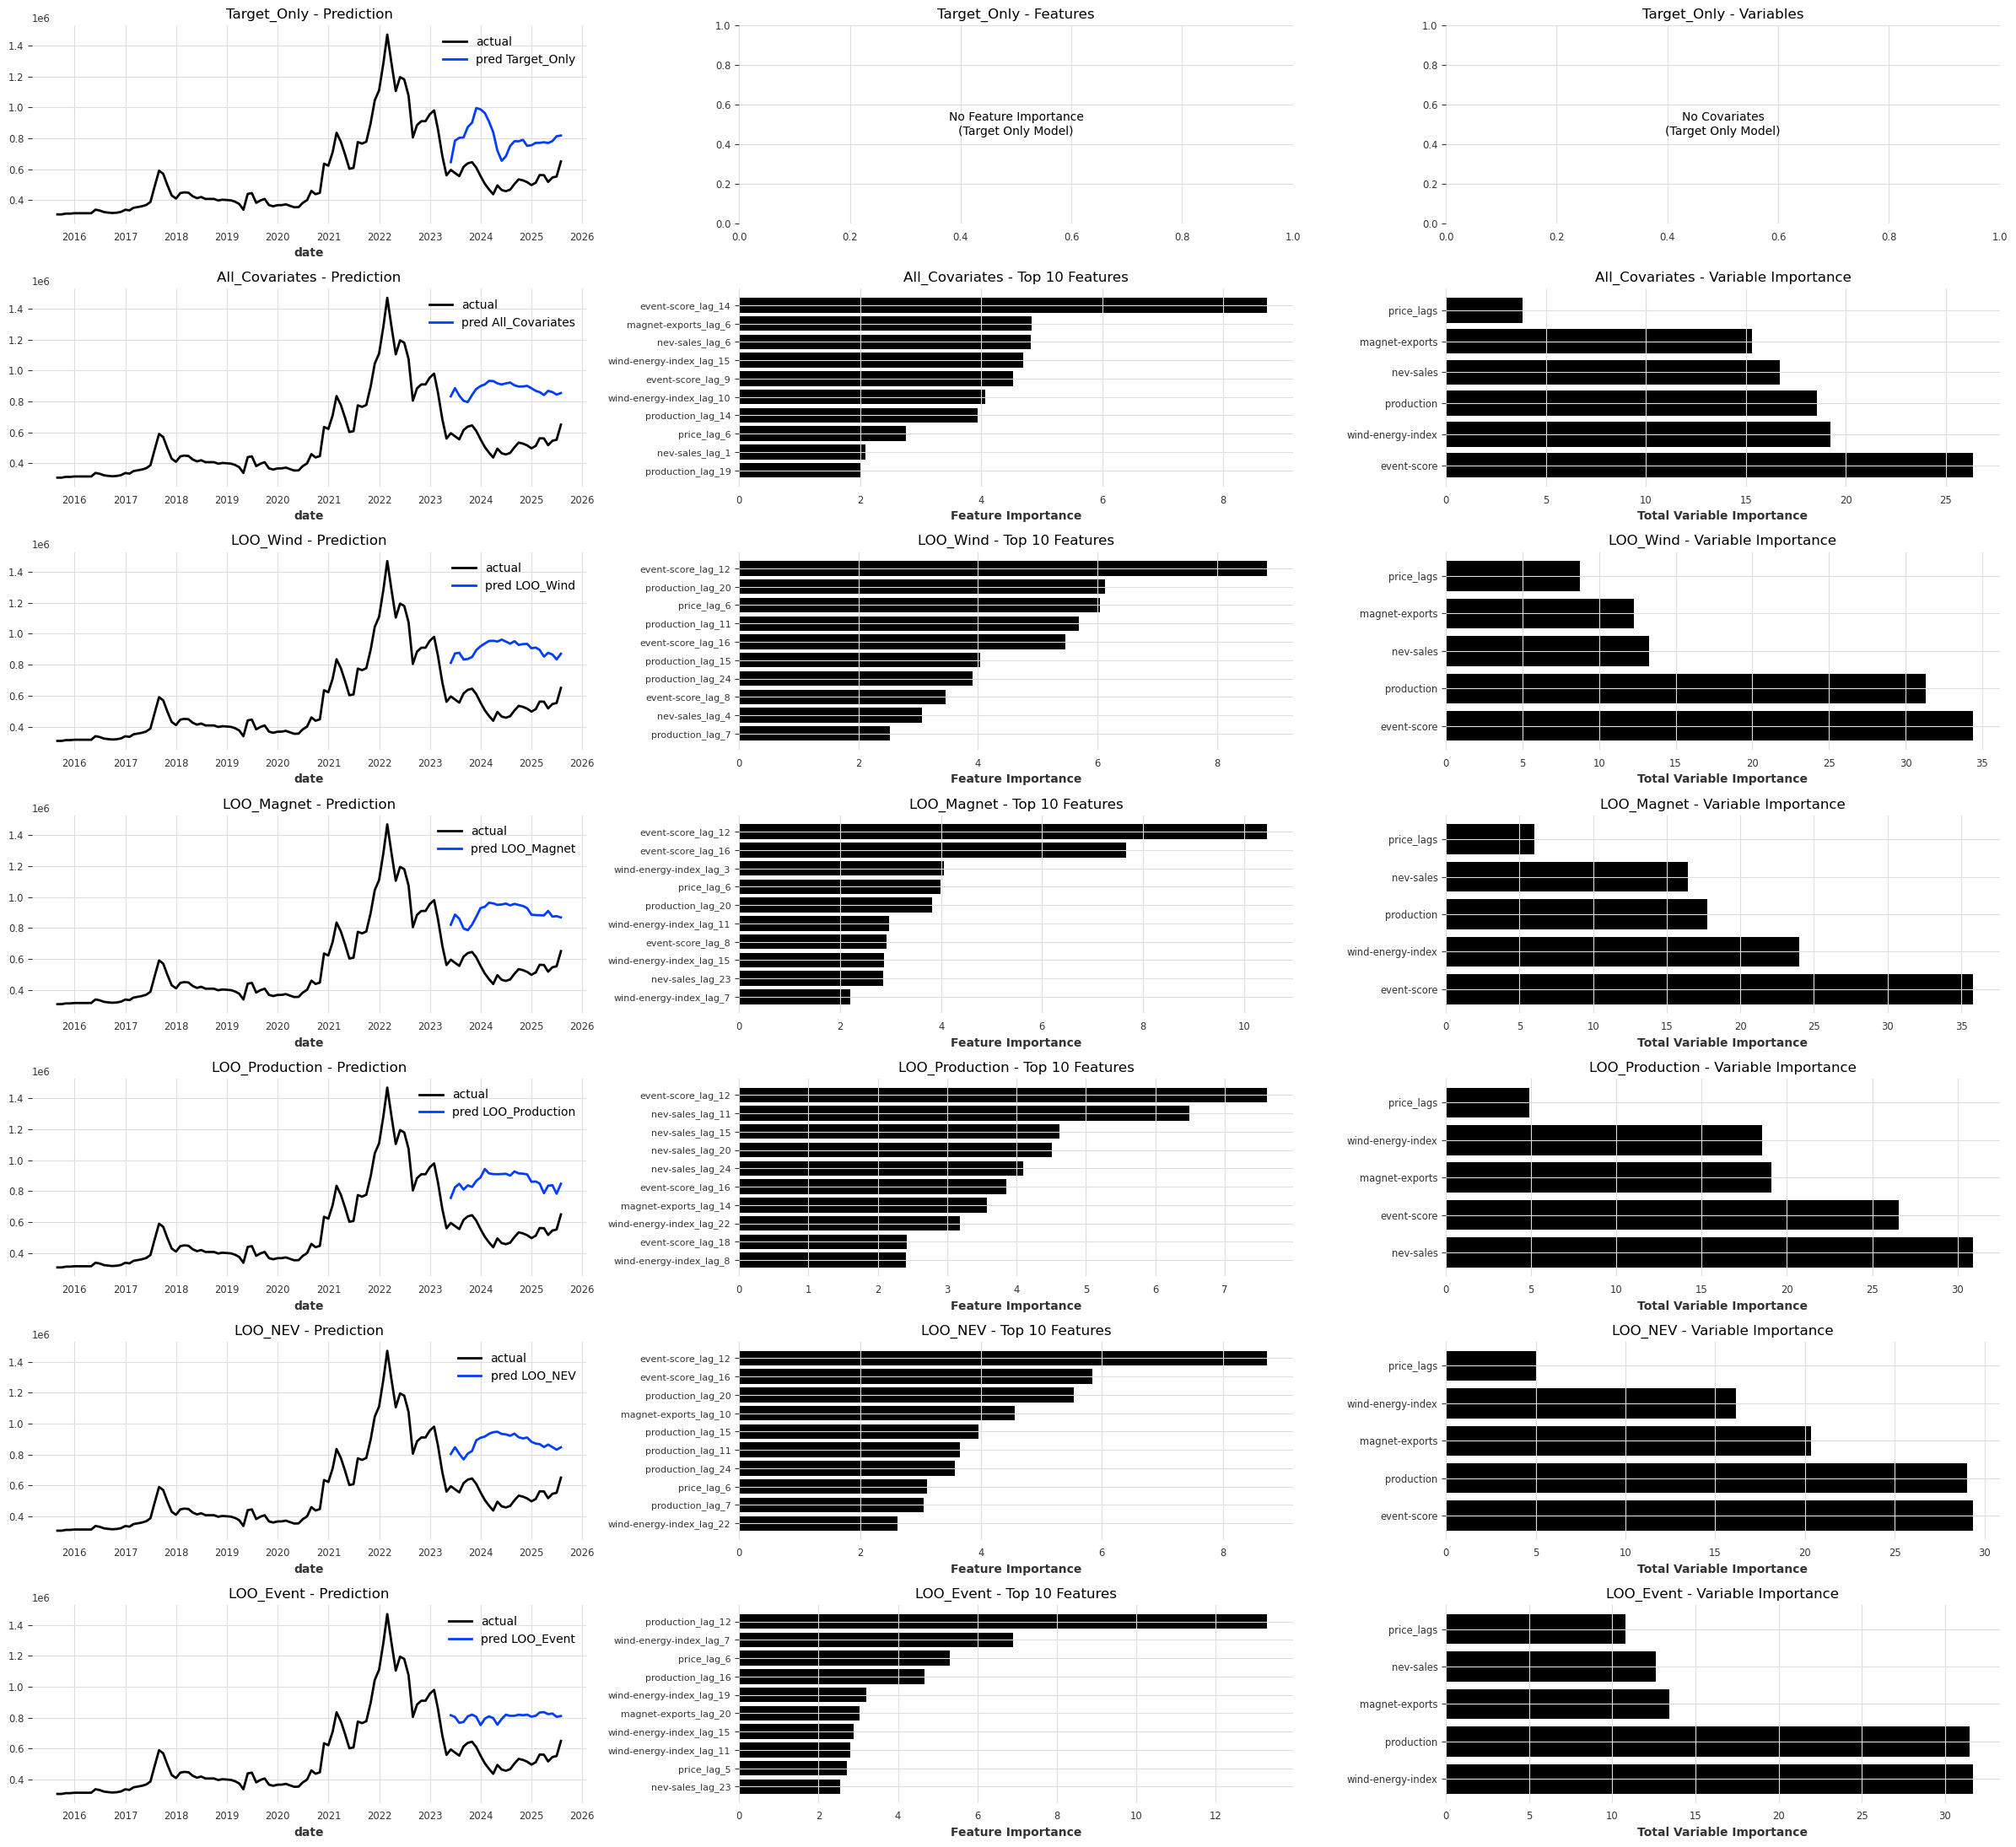

In [14]:
input = 6 # 이건 3, 6 정도 작아야 좋음. 6이 best
output = 1 # 이건 3도 안 됨. 1해야 됨
lag_cov = 24 # 이건 24이상이 좋고, 24가 best
train_set = val
test_set = test
cov_set = train_cov.concatenate(val_cov).concatenate(test_cov)
pred_len = len(test_set)
Model = CatBoostModel

C_0 = Model(lags=input, output_chunk_length=output)
C_0.fit(train_set)
C_all = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_all.fit(train_set, past_covariates=cov_set)
C_loo_w = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_loo_w.fit(train_set, past_covariates=cov_set[['production', 'nev-sales', 'magnet-exports', 'event-score']])
C_loo_m = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_loo_m.fit(train_set, past_covariates=cov_set[['production', 'nev-sales', 'wind-energy-index', 'event-score']])
C_loo_p = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_loo_p.fit(train_set, past_covariates=cov_set[['nev-sales', 'wind-energy-index', 'magnet-exports', 'event-score']])
C_loo_n = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_loo_n.fit(train_set, past_covariates=cov_set[['production', 'wind-energy-index', 'magnet-exports', 'event-score']])
C_loo_e = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_loo_e.fit(train_set, past_covariates=cov_set[['production', 'nev-sales', 'wind-energy-index', 'magnet-exports']])

pred_C_0 = C_0.predict(n=pred_len)
pred_C_all = C_all.predict(n=pred_len)
pred_C_loo_w = C_loo_w.predict(n=pred_len)
pred_C_loo_m = C_loo_m.predict(n=pred_len)
pred_C_loo_p = C_loo_p.predict(n=pred_len)
pred_C_loo_n = C_loo_n.predict(n=pred_len)
pred_C_loo_e = C_loo_e.predict(n=pred_len)

# 평가 실행
predictions_dict = {
    'Target_Only': pred_C_0,
    'All_Covariates': pred_C_all,
    'LOO_Wind': pred_C_loo_w,
    'LOO_Magnet': pred_C_loo_m,
    'LOO_Production': pred_C_loo_p,
    'LOO_NEV': pred_C_loo_n,
    'LOO_Event': pred_C_loo_e
}
evaluate_predictions(Model, train_set, test_set, predictions_dict)

# 예측결과 및 변수 중요도
models = [C_0, C_all, C_loo_w, C_loo_m, C_loo_p, C_loo_n, C_loo_e]
model_names = ['Target_Only', 'All_Covariates', 'LOO_Wind', 'LOO_Magnet', 'LOO_Production', 'LOO_NEV', 'LOO_Event']
predictions = [pred_C_0, pred_C_all, pred_C_loo_w, pred_C_loo_m, pred_C_loo_p, pred_C_loo_n, pred_C_loo_e]
model_vars = [
    [],  # C_0: target only
    ['production', 'nev-sales', 'wind-energy-index', 'magnet-exports', 'event-score'],  # C_all
    ['production', 'nev-sales', 'magnet-exports', 'event-score'],  # C_loo_w (no wind)
    ['production', 'nev-sales', 'wind-energy-index', 'event-score'],  # C_loo_m (no magnet)
    ['nev-sales', 'wind-energy-index', 'magnet-exports', 'event-score'],  # C_loo_p (no production)
    ['production', 'wind-energy-index', 'magnet-exports', 'event-score'],  # C_loo_n (no nev)
    ['production', 'nev-sales', 'wind-energy-index', 'magnet-exports']  # C_loo_e (no event)
]
plot_model_analysis(models, model_names, predictions, model_vars, input, lag_cov)

#### R3 Pre+COVID→Recovery
- C0: 타깃 단독(price only)
- Call: 모든 공변량 포함(이벤트는 future_cov로만 사용 가능 시 별도 처리)
- LOO_w/m/p/n/e: Call에서 해당 변수만 제거

`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.
`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.
`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.
`predict()` was called with `n > output_

<class 'darts.models.forecasting.random_forest.RandomForestModel'> 예측 성능 평가 결과
Target_Only          | MAE: 231072.2222 | RMSE: 257700.8092 | MAPE:  45.29% | MASE:  1.3140
All_Covariates       | MAE: 287587.4074 | RMSE: 299315.8545 | MAPE:  55.19% | MASE:  1.6354
LOO_Wind             | MAE: 371147.4074 | RMSE: 392953.5871 | MAPE:  71.84% | MASE:  2.1106
LOO_Magnet           | MAE: 262871.4815 | RMSE: 274038.9211 | MAPE:  50.51% | MASE:  1.4948
LOO_Production       | MAE: 273370.1852 | RMSE: 285117.3930 | MAPE:  52.41% | MASE:  1.5545
LOO_NEV              | MAE: 238832.7778 | RMSE: 251273.0908 | MAPE:  46.07% | MASE:  1.3581
LOO_Event            | MAE: 139561.8519 | RMSE: 152390.9717 | MAPE:  26.46% | MASE:  0.7936


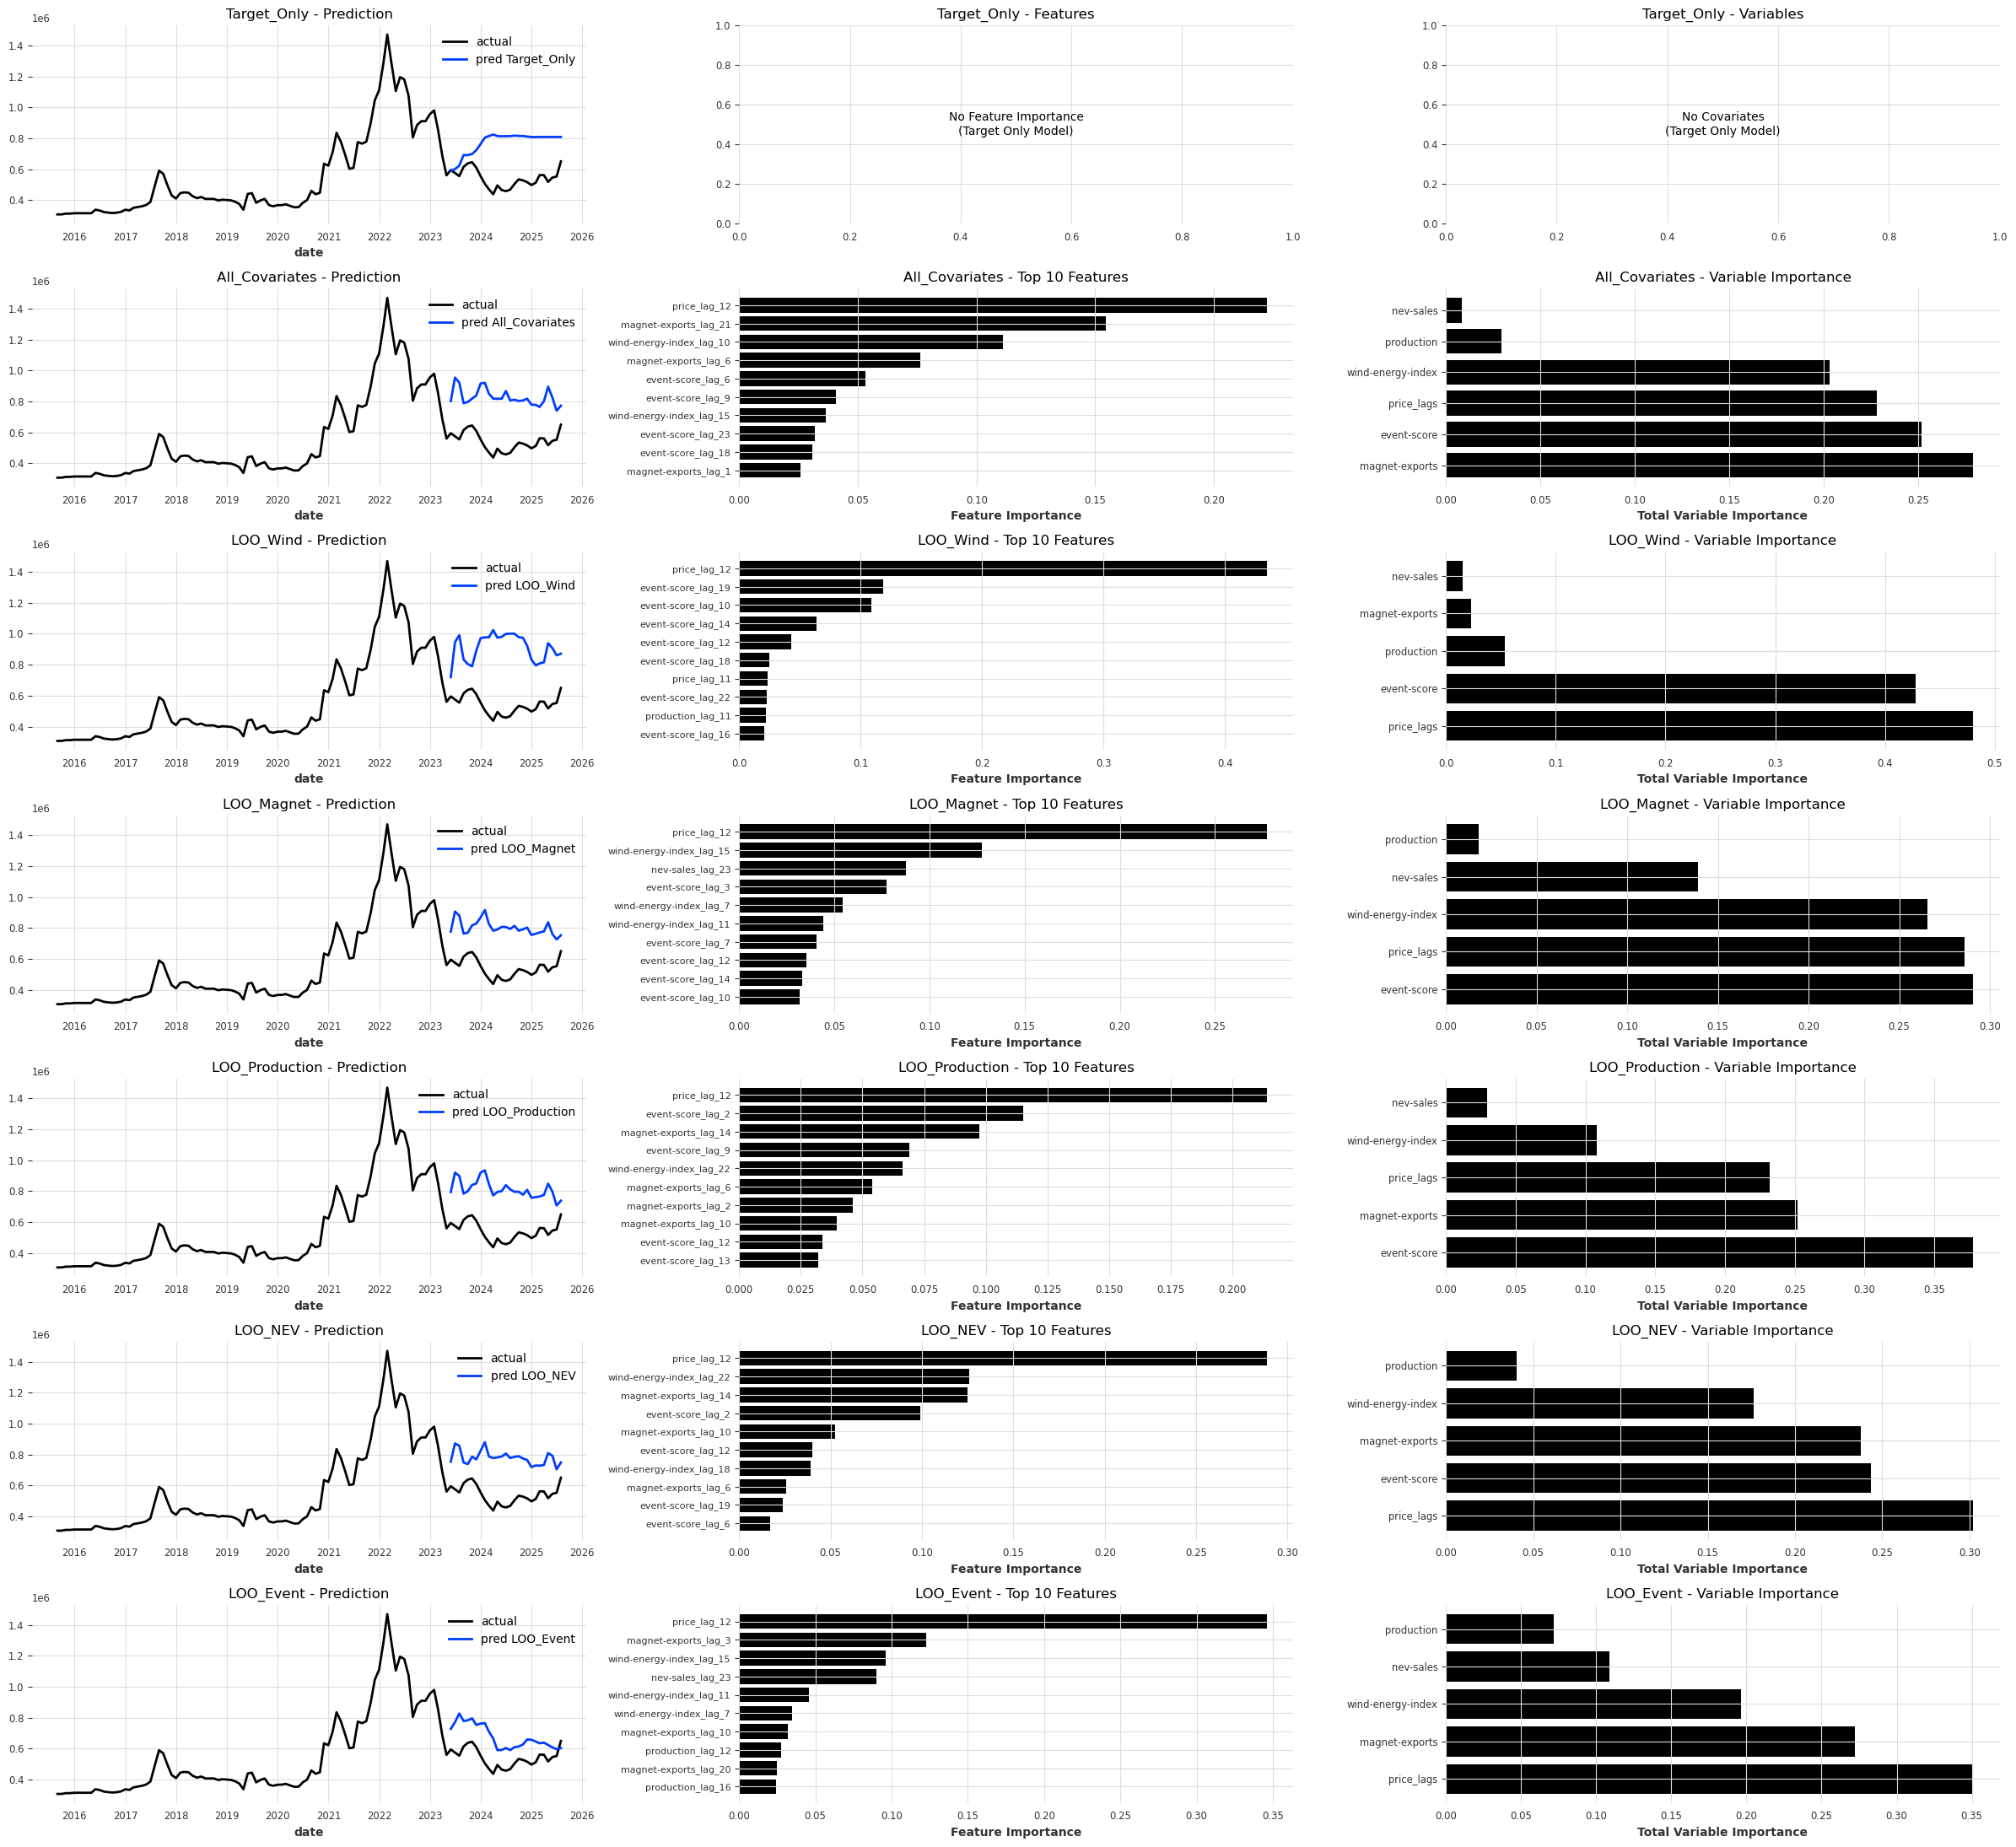

In [15]:
input = 12 # 이건 3, 6, 12 큰 영향 없음. 그래도 많을수록 좋음
output = 1 # 이건 3도 안 됨. 1해야 됨
lag_cov = 24 # 이건 24이상이 좋고, 24가 best
train_set = train.concatenate(val)
test_set = test
cov_set = train_cov.concatenate(val_cov).concatenate(test_cov)
pred_len = len(test_set)
Model = RandomForestModel

C_0 = Model(lags=input, output_chunk_length=output)
C_0.fit(train_set)
C_all = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_all.fit(train_set, past_covariates=cov_set)
C_loo_w = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_loo_w.fit(train_set, past_covariates=cov_set[['production', 'nev-sales', 'magnet-exports', 'event-score']])
C_loo_m = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_loo_m.fit(train_set, past_covariates=cov_set[['production', 'nev-sales', 'wind-energy-index', 'event-score']])
C_loo_p = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_loo_p.fit(train_set, past_covariates=cov_set[['nev-sales', 'wind-energy-index', 'magnet-exports', 'event-score']])
C_loo_n = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_loo_n.fit(train_set, past_covariates=cov_set[['production', 'wind-energy-index', 'magnet-exports', 'event-score']])
C_loo_e = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_loo_e.fit(train_set, past_covariates=cov_set[['production', 'nev-sales', 'wind-energy-index', 'magnet-exports']])

pred_C_0 = C_0.predict(n=pred_len)
pred_C_all = C_all.predict(n=pred_len)
pred_C_loo_w = C_loo_w.predict(n=pred_len)
pred_C_loo_m = C_loo_m.predict(n=pred_len)
pred_C_loo_p = C_loo_p.predict(n=pred_len)
pred_C_loo_n = C_loo_n.predict(n=pred_len)
pred_C_loo_e = C_loo_e.predict(n=pred_len)

# 평가 실행
predictions_dict = {
    'Target_Only': pred_C_0,
    'All_Covariates': pred_C_all,
    'LOO_Wind': pred_C_loo_w,
    'LOO_Magnet': pred_C_loo_m,
    'LOO_Production': pred_C_loo_p,
    'LOO_NEV': pred_C_loo_n,
    'LOO_Event': pred_C_loo_e
}
evaluate_predictions(Model, train_set, test_set, predictions_dict)

# 예측결과 및 변수 중요도
models = [C_0, C_all, C_loo_w, C_loo_m, C_loo_p, C_loo_n, C_loo_e]
model_names = ['Target_Only', 'All_Covariates', 'LOO_Wind', 'LOO_Magnet', 'LOO_Production', 'LOO_NEV', 'LOO_Event']
predictions = [pred_C_0, pred_C_all, pred_C_loo_w, pred_C_loo_m, pred_C_loo_p, pred_C_loo_n, pred_C_loo_e]
model_vars = [
    [],  # C_0: target only
    ['production', 'nev-sales', 'wind-energy-index', 'magnet-exports', 'event-score'],  # C_all
    ['production', 'nev-sales', 'magnet-exports', 'event-score'],  # C_loo_w (no wind)
    ['production', 'nev-sales', 'wind-energy-index', 'event-score'],  # C_loo_m (no magnet)
    ['nev-sales', 'wind-energy-index', 'magnet-exports', 'event-score'],  # C_loo_p (no production)
    ['production', 'wind-energy-index', 'magnet-exports', 'event-score'],  # C_loo_n (no nev)
    ['production', 'nev-sales', 'wind-energy-index', 'magnet-exports']  # C_loo_e (no event)
]
plot_model_analysis(models, model_names, predictions, model_vars, input, lag_cov)

`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.
`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.
`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.
`predict()` was called with `n > output_

<class 'darts.models.forecasting.xgboost.XGBModel'> 예측 성능 평가 결과
Target_Only          | MAE: 115045.4190 | RMSE: 125583.9954 | MAPE:  20.60% | MASE:  0.6542
All_Covariates       | MAE: 49615.7257 | RMSE: 60499.6132 | MAPE:   9.24% | MASE:  0.2821
LOO_Wind             | MAE: 274673.6227 | RMSE: 320707.7483 | MAPE:  53.45% | MASE:  1.5620
LOO_Magnet           | MAE: 74281.4988 | RMSE: 108511.7649 | MAPE:  13.78% | MASE:  0.4224
LOO_Production       | MAE: 49912.4248 | RMSE: 59974.9839 | MAPE:   9.39% | MASE:  0.2838
LOO_NEV              | MAE: 72380.0660 | RMSE: 100456.0314 | MAPE:  13.43% | MASE:  0.4116
LOO_Event            | MAE: 58285.3877 | RMSE: 67920.1343 | MAPE:  11.46% | MASE:  0.3314


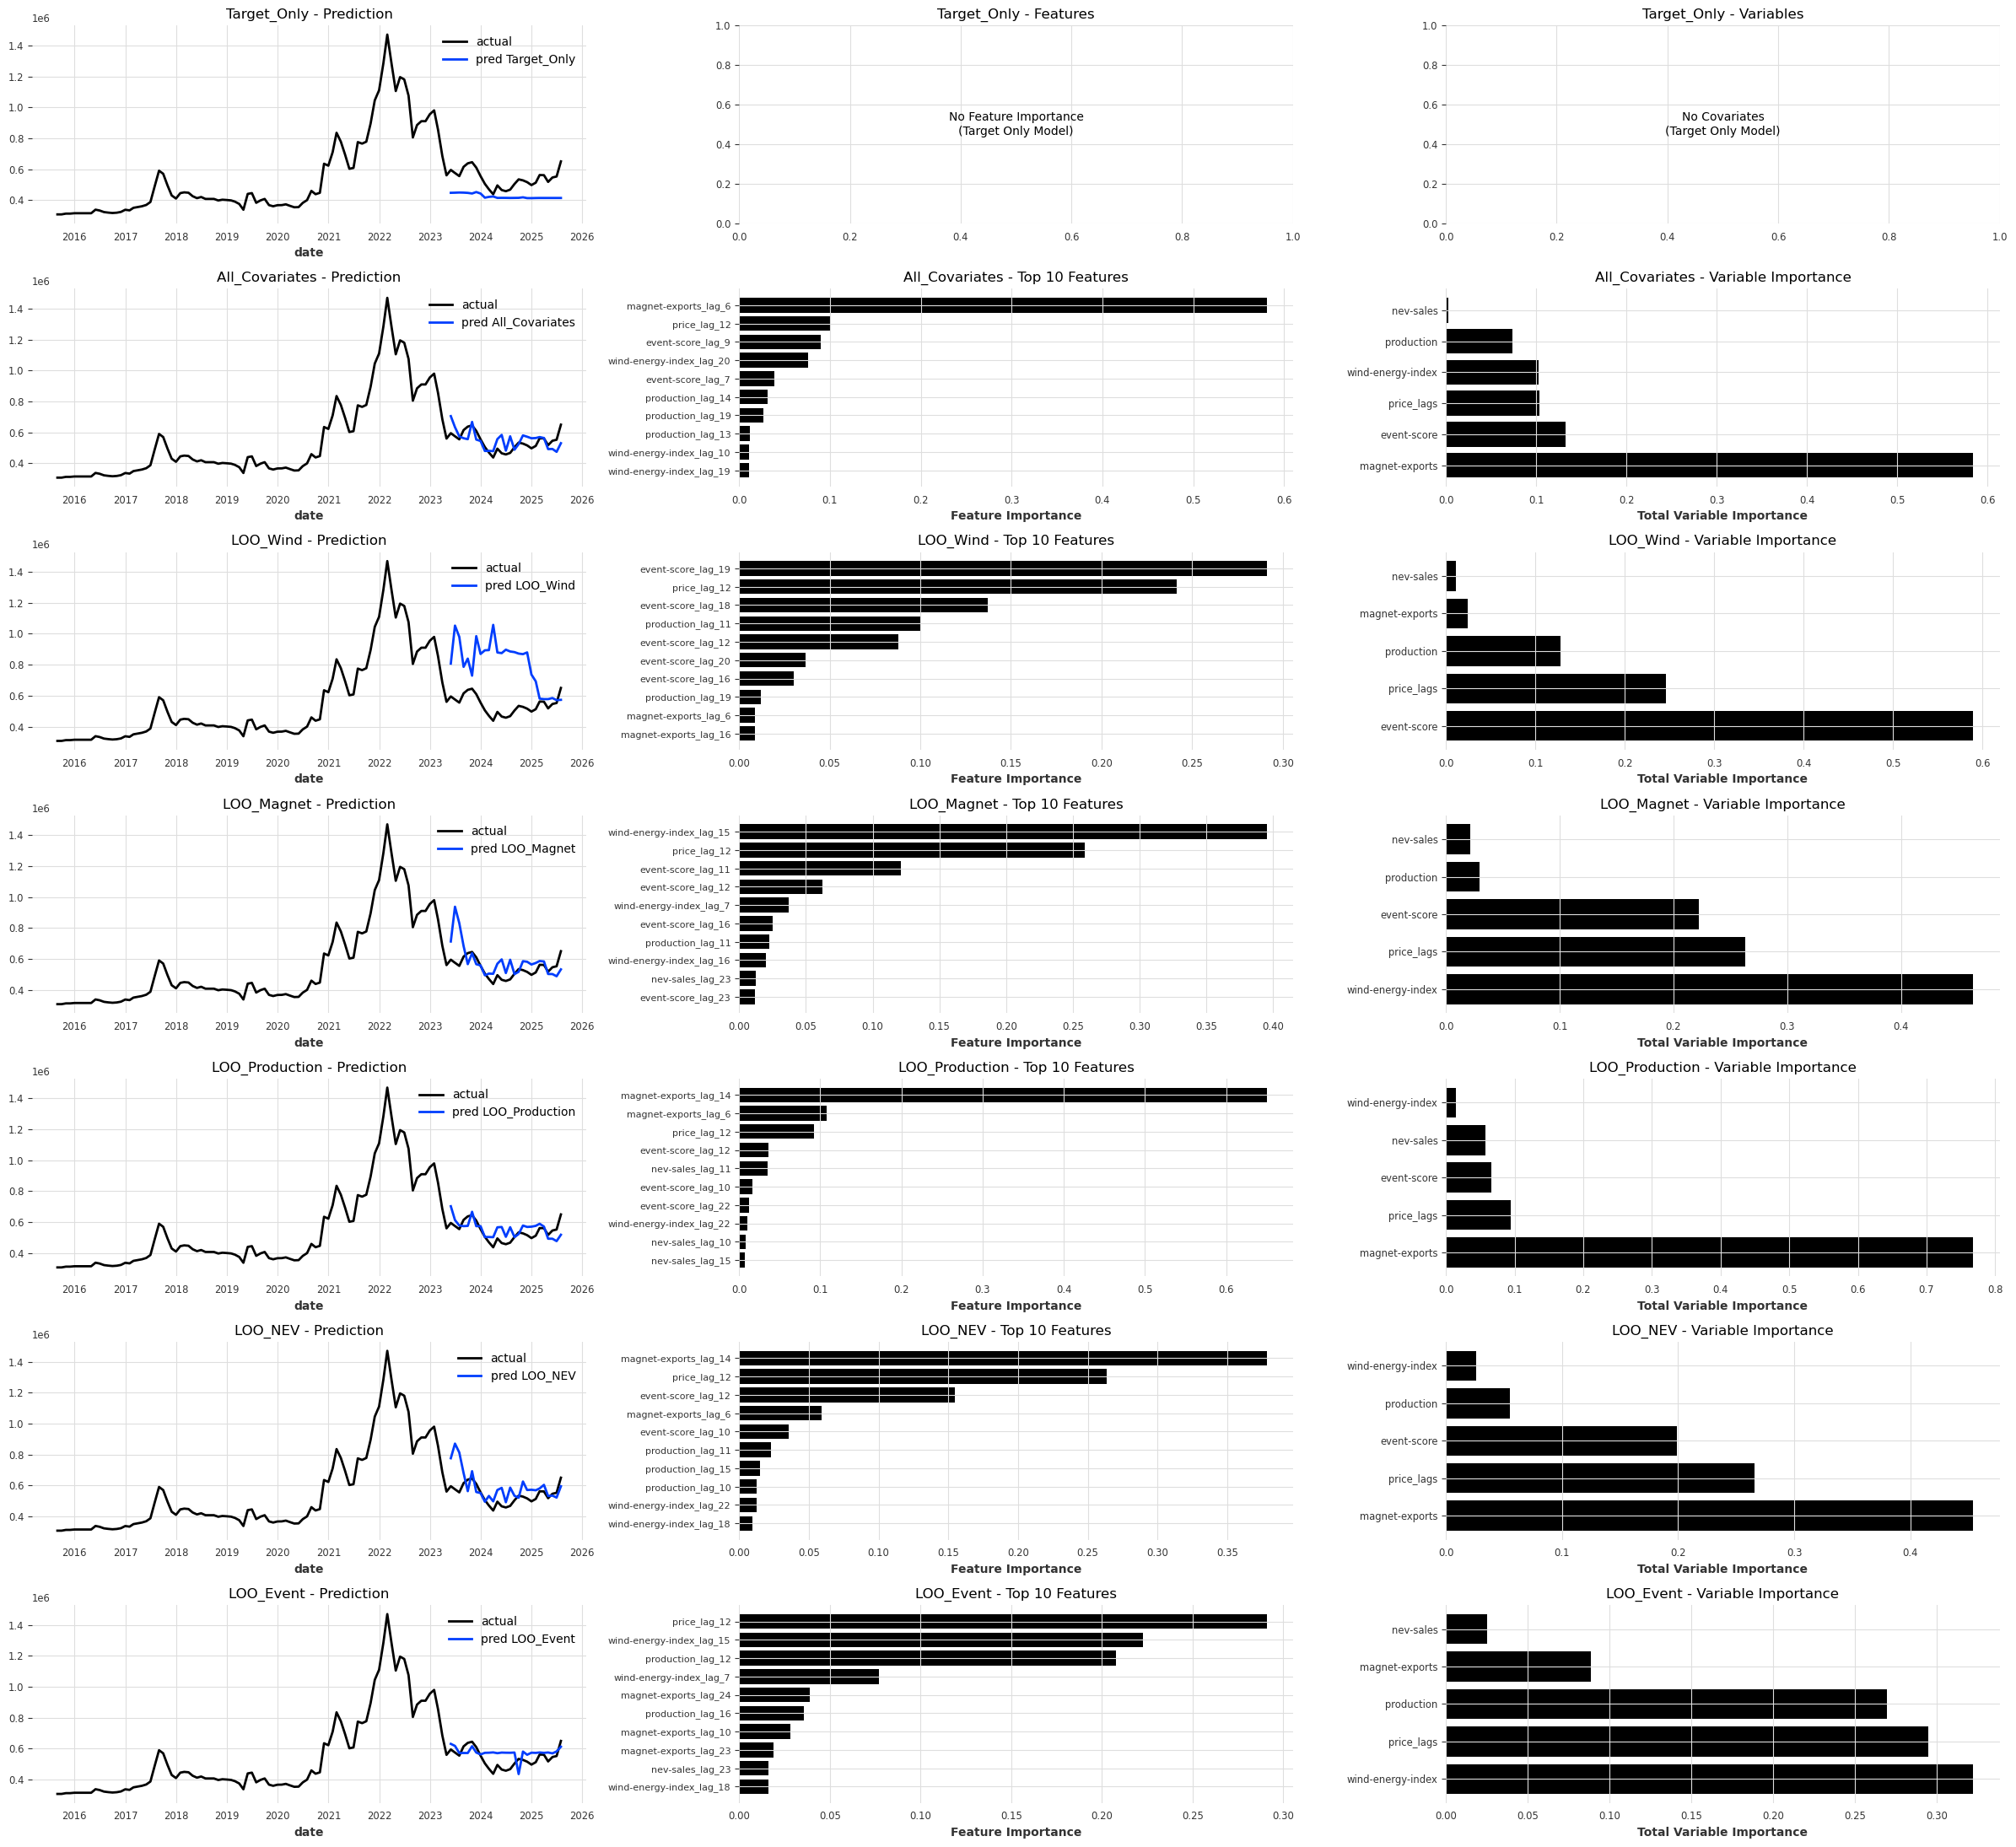

In [16]:
input = 12 # 이건 3, 6, 12 큰 차이 없음. 그래도 많을수록 좋음
output = 1 # 이건 3도 안 됨. 1해야 됨
lag_cov = 24 # 이건 24이상이 좋고, 24가 best
train_set = train.concatenate(val)
test_set = test
cov_set = train_cov.concatenate(val_cov).concatenate(test_cov)
pred_len = len(test_set)
Model = XGBModel

C_0 = Model(lags=input, output_chunk_length=output)
C_0.fit(train_set)
C_all = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_all.fit(train_set, past_covariates=cov_set)
C_loo_w = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_loo_w.fit(train_set, past_covariates=cov_set[['production', 'nev-sales', 'magnet-exports', 'event-score']])
C_loo_m = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_loo_m.fit(train_set, past_covariates=cov_set[['production', 'nev-sales', 'wind-energy-index', 'event-score']])
C_loo_p = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_loo_p.fit(train_set, past_covariates=cov_set[['nev-sales', 'wind-energy-index', 'magnet-exports', 'event-score']])
C_loo_n = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_loo_n.fit(train_set, past_covariates=cov_set[['production', 'wind-energy-index', 'magnet-exports', 'event-score']])
C_loo_e = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_loo_e.fit(train_set, past_covariates=cov_set[['production', 'nev-sales', 'wind-energy-index', 'magnet-exports']])

pred_C_0 = C_0.predict(n=pred_len)
pred_C_all = C_all.predict(n=pred_len)
pred_C_loo_w = C_loo_w.predict(n=pred_len)
pred_C_loo_m = C_loo_m.predict(n=pred_len)
pred_C_loo_p = C_loo_p.predict(n=pred_len)
pred_C_loo_n = C_loo_n.predict(n=pred_len)
pred_C_loo_e = C_loo_e.predict(n=pred_len)

# 평가 실행
predictions_dict = {
    'Target_Only': pred_C_0,
    'All_Covariates': pred_C_all,
    'LOO_Wind': pred_C_loo_w,
    'LOO_Magnet': pred_C_loo_m,
    'LOO_Production': pred_C_loo_p,
    'LOO_NEV': pred_C_loo_n,
    'LOO_Event': pred_C_loo_e
}
evaluate_predictions(Model, train_set, test_set, predictions_dict)

# 예측결과 및 변수 중요도
models = [C_0, C_all, C_loo_w, C_loo_m, C_loo_p, C_loo_n, C_loo_e]
model_names = ['Target_Only', 'All_Covariates', 'LOO_Wind', 'LOO_Magnet', 'LOO_Production', 'LOO_NEV', 'LOO_Event']
predictions = [pred_C_0, pred_C_all, pred_C_loo_w, pred_C_loo_m, pred_C_loo_p, pred_C_loo_n, pred_C_loo_e]
model_vars = [
    [],  # C_0: target only
    ['production', 'nev-sales', 'wind-energy-index', 'magnet-exports', 'event-score'],  # C_all
    ['production', 'nev-sales', 'magnet-exports', 'event-score'],  # C_loo_w (no wind)
    ['production', 'nev-sales', 'wind-energy-index', 'event-score'],  # C_loo_m (no magnet)
    ['nev-sales', 'wind-energy-index', 'magnet-exports', 'event-score'],  # C_loo_p (no production)
    ['production', 'wind-energy-index', 'magnet-exports', 'event-score'],  # C_loo_n (no nev)
    ['production', 'nev-sales', 'wind-energy-index', 'magnet-exports']  # C_loo_e (no event)
]
plot_model_analysis(models, model_names, predictions, model_vars, input, lag_cov)

e:\Programs\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\Programs\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\Programs\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\Programs\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\Programs\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\Programs\anaconda3\Lib\site-packages\sklearn\utils\v

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000078 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 319
[LightGBM] [Info] Number of data points in the train set: 81, number of used features: 12
[LightGBM] [Info] Start training from score 584820.987654
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

e:\Programs\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\Programs\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\Programs\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\Programs\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\Programs\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\Programs\anaconda3\Lib\site-packages\sklearn\utils\v

<class 'darts.models.forecasting.lgbm.LightGBMModel'> 예측 성능 평가 결과
Target_Only          | MAE: 444109.1024 | RMSE: 458861.5273 | MAPE:  84.96% | MASE:  2.5255
All_Covariates       | MAE: 183161.5913 | RMSE: 196235.2213 | MAPE:  34.99% | MASE:  1.0416
LOO_Wind             | MAE: 296457.2607 | RMSE: 308273.6681 | MAPE:  56.84% | MASE:  1.6858
LOO_Magnet           | MAE: 246489.2283 | RMSE: 260863.3862 | MAPE:  47.27% | MASE:  1.4017
LOO_Production       | MAE: 163713.2460 | RMSE: 181604.1407 | MAPE:  31.35% | MASE:  0.9310
LOO_NEV              | MAE: 159929.8779 | RMSE: 176483.8594 | MAPE:  30.68% | MASE:  0.9095
LOO_Event            | MAE: 196219.3830 | RMSE: 206127.0077 | MAPE:  37.15% | MASE:  1.1158


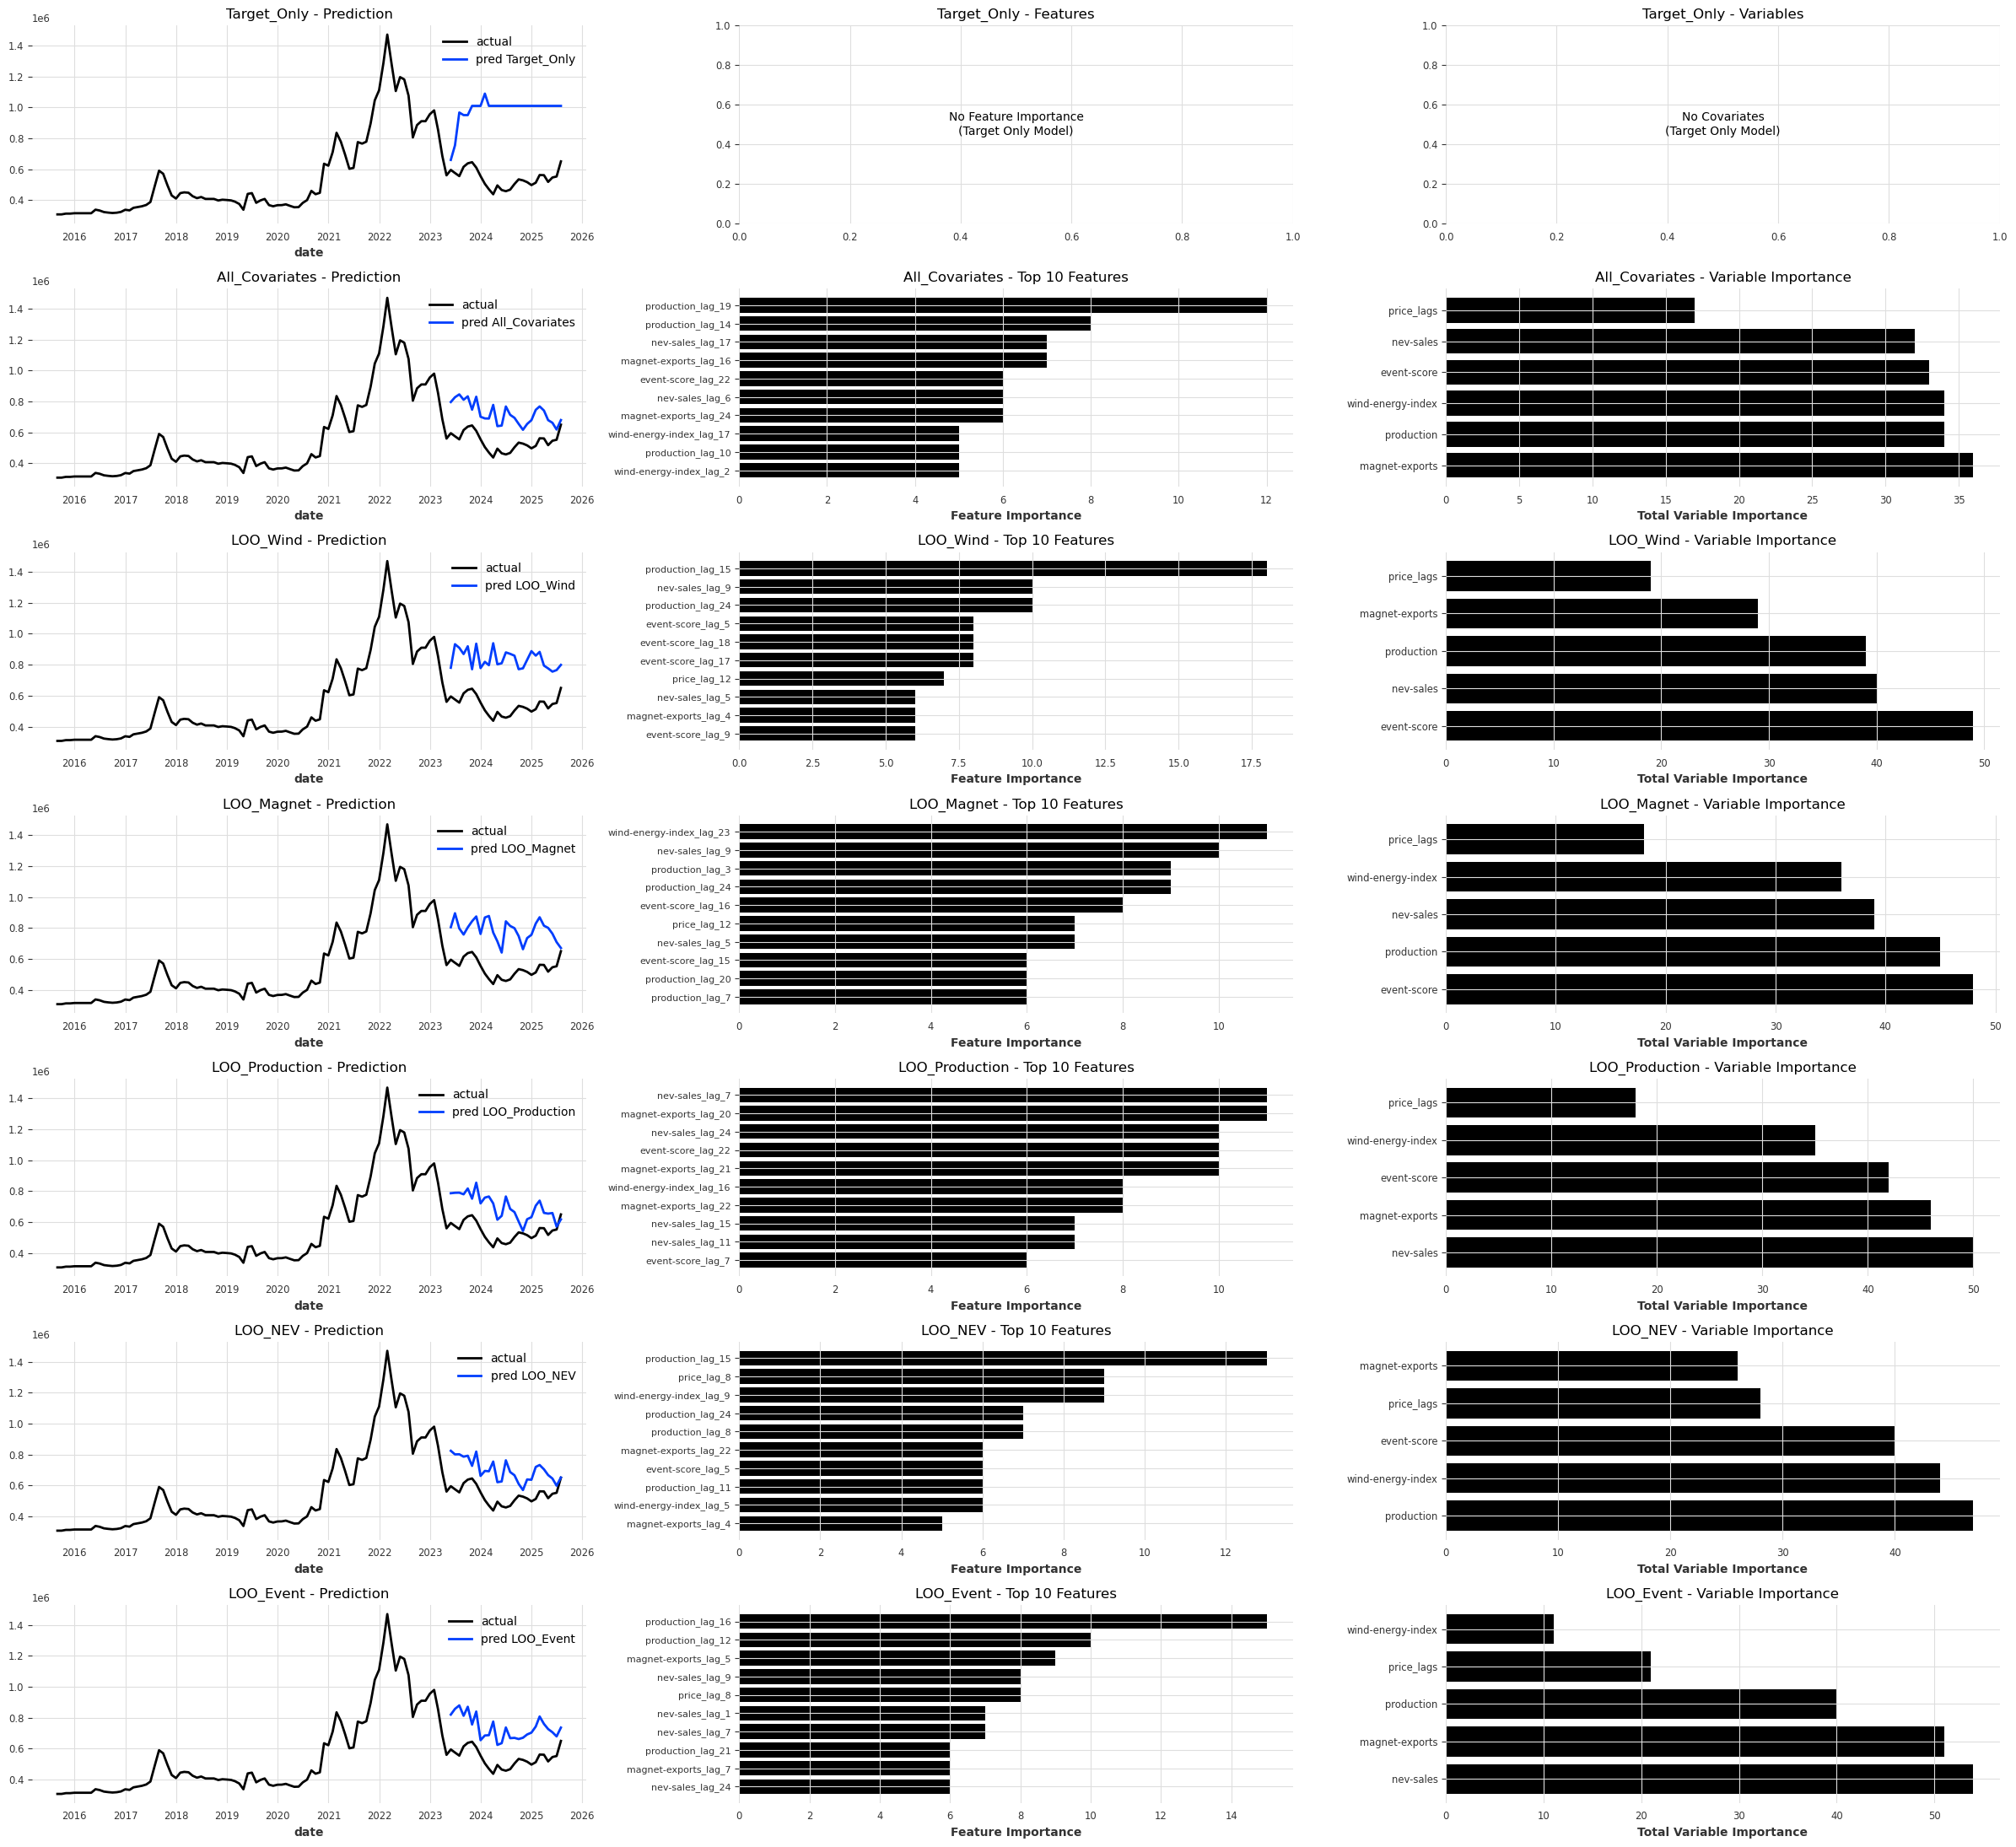

In [17]:
input = 12 # 이건 3, 6, 12 큰 차이 없음. 그래도 많을수록 좋음
output = 1 # 이건 3도 안 됨. 1해야 됨
lag_cov = 24 # 이건 24이상이 좋고, 24가 best
train_set = train.concatenate(val)
test_set = test
cov_set = train_cov.concatenate(val_cov).concatenate(test_cov)
pred_len = len(test_set)
Model = LightGBMModel

C_0 = Model(lags=input, output_chunk_length=output)
C_0.fit(train_set)
C_all = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_all.fit(train_set, past_covariates=cov_set)
C_loo_w = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_loo_w.fit(train_set, past_covariates=cov_set[['production', 'nev-sales', 'magnet-exports', 'event-score']])
C_loo_m = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_loo_m.fit(train_set, past_covariates=cov_set[['production', 'nev-sales', 'wind-energy-index', 'event-score']])
C_loo_p = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_loo_p.fit(train_set, past_covariates=cov_set[['nev-sales', 'wind-energy-index', 'magnet-exports', 'event-score']])
C_loo_n = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_loo_n.fit(train_set, past_covariates=cov_set[['production', 'wind-energy-index', 'magnet-exports', 'event-score']])
C_loo_e = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_loo_e.fit(train_set, past_covariates=cov_set[['production', 'nev-sales', 'wind-energy-index', 'magnet-exports']])

pred_C_0 = C_0.predict(n=pred_len)
pred_C_all = C_all.predict(n=pred_len)
pred_C_loo_w = C_loo_w.predict(n=pred_len)
pred_C_loo_m = C_loo_m.predict(n=pred_len)
pred_C_loo_p = C_loo_p.predict(n=pred_len)
pred_C_loo_n = C_loo_n.predict(n=pred_len)
pred_C_loo_e = C_loo_e.predict(n=pred_len)

# 평가 실행
predictions_dict = {
    'Target_Only': pred_C_0,
    'All_Covariates': pred_C_all,
    'LOO_Wind': pred_C_loo_w,
    'LOO_Magnet': pred_C_loo_m,
    'LOO_Production': pred_C_loo_p,
    'LOO_NEV': pred_C_loo_n,
    'LOO_Event': pred_C_loo_e
}
evaluate_predictions(Model, train_set, test_set, predictions_dict)

# 예측결과 및 변수 중요도
models = [C_0, C_all, C_loo_w, C_loo_m, C_loo_p, C_loo_n, C_loo_e]
model_names = ['Target_Only', 'All_Covariates', 'LOO_Wind', 'LOO_Magnet', 'LOO_Production', 'LOO_NEV', 'LOO_Event']
predictions = [pred_C_0, pred_C_all, pred_C_loo_w, pred_C_loo_m, pred_C_loo_p, pred_C_loo_n, pred_C_loo_e]
model_vars = [
    [],  # C_0: target only
    ['production', 'nev-sales', 'wind-energy-index', 'magnet-exports', 'event-score'],  # C_all
    ['production', 'nev-sales', 'magnet-exports', 'event-score'],  # C_loo_w (no wind)
    ['production', 'nev-sales', 'wind-energy-index', 'event-score'],  # C_loo_m (no magnet)
    ['nev-sales', 'wind-energy-index', 'magnet-exports', 'event-score'],  # C_loo_p (no production)
    ['production', 'wind-energy-index', 'magnet-exports', 'event-score'],  # C_loo_n (no nev)
    ['production', 'nev-sales', 'wind-energy-index', 'magnet-exports']  # C_loo_e (no event)
]
plot_model_analysis(models, model_names, predictions, model_vars, input, lag_cov)

`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.
`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.
`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.
`predict()` was called with `n > output_

<class 'darts.models.forecasting.catboost_model.CatBoostModel'> 예측 성능 평가 결과
Target_Only          | MAE: 373319.7559 | RMSE: 422866.9544 | MAPE:  73.01% | MASE:  2.1229
All_Covariates       | MAE: 155832.1148 | RMSE: 165685.5071 | MAPE:  30.24% | MASE:  0.8862
LOO_Wind             | MAE: 209150.9257 | RMSE: 223081.0449 | MAPE:  40.67% | MASE:  1.1894
LOO_Magnet           | MAE: 180459.2966 | RMSE: 191483.2018 | MAPE:  34.97% | MASE:  1.0262
LOO_Production       | MAE: 158164.4911 | RMSE: 167586.2394 | MAPE:  30.48% | MASE:  0.8994
LOO_NEV              | MAE: 161218.2097 | RMSE: 170982.7044 | MAPE:  31.22% | MASE:  0.9168
LOO_Event            | MAE: 134560.0671 | RMSE: 142027.1796 | MAPE:  26.00% | MASE:  0.7652


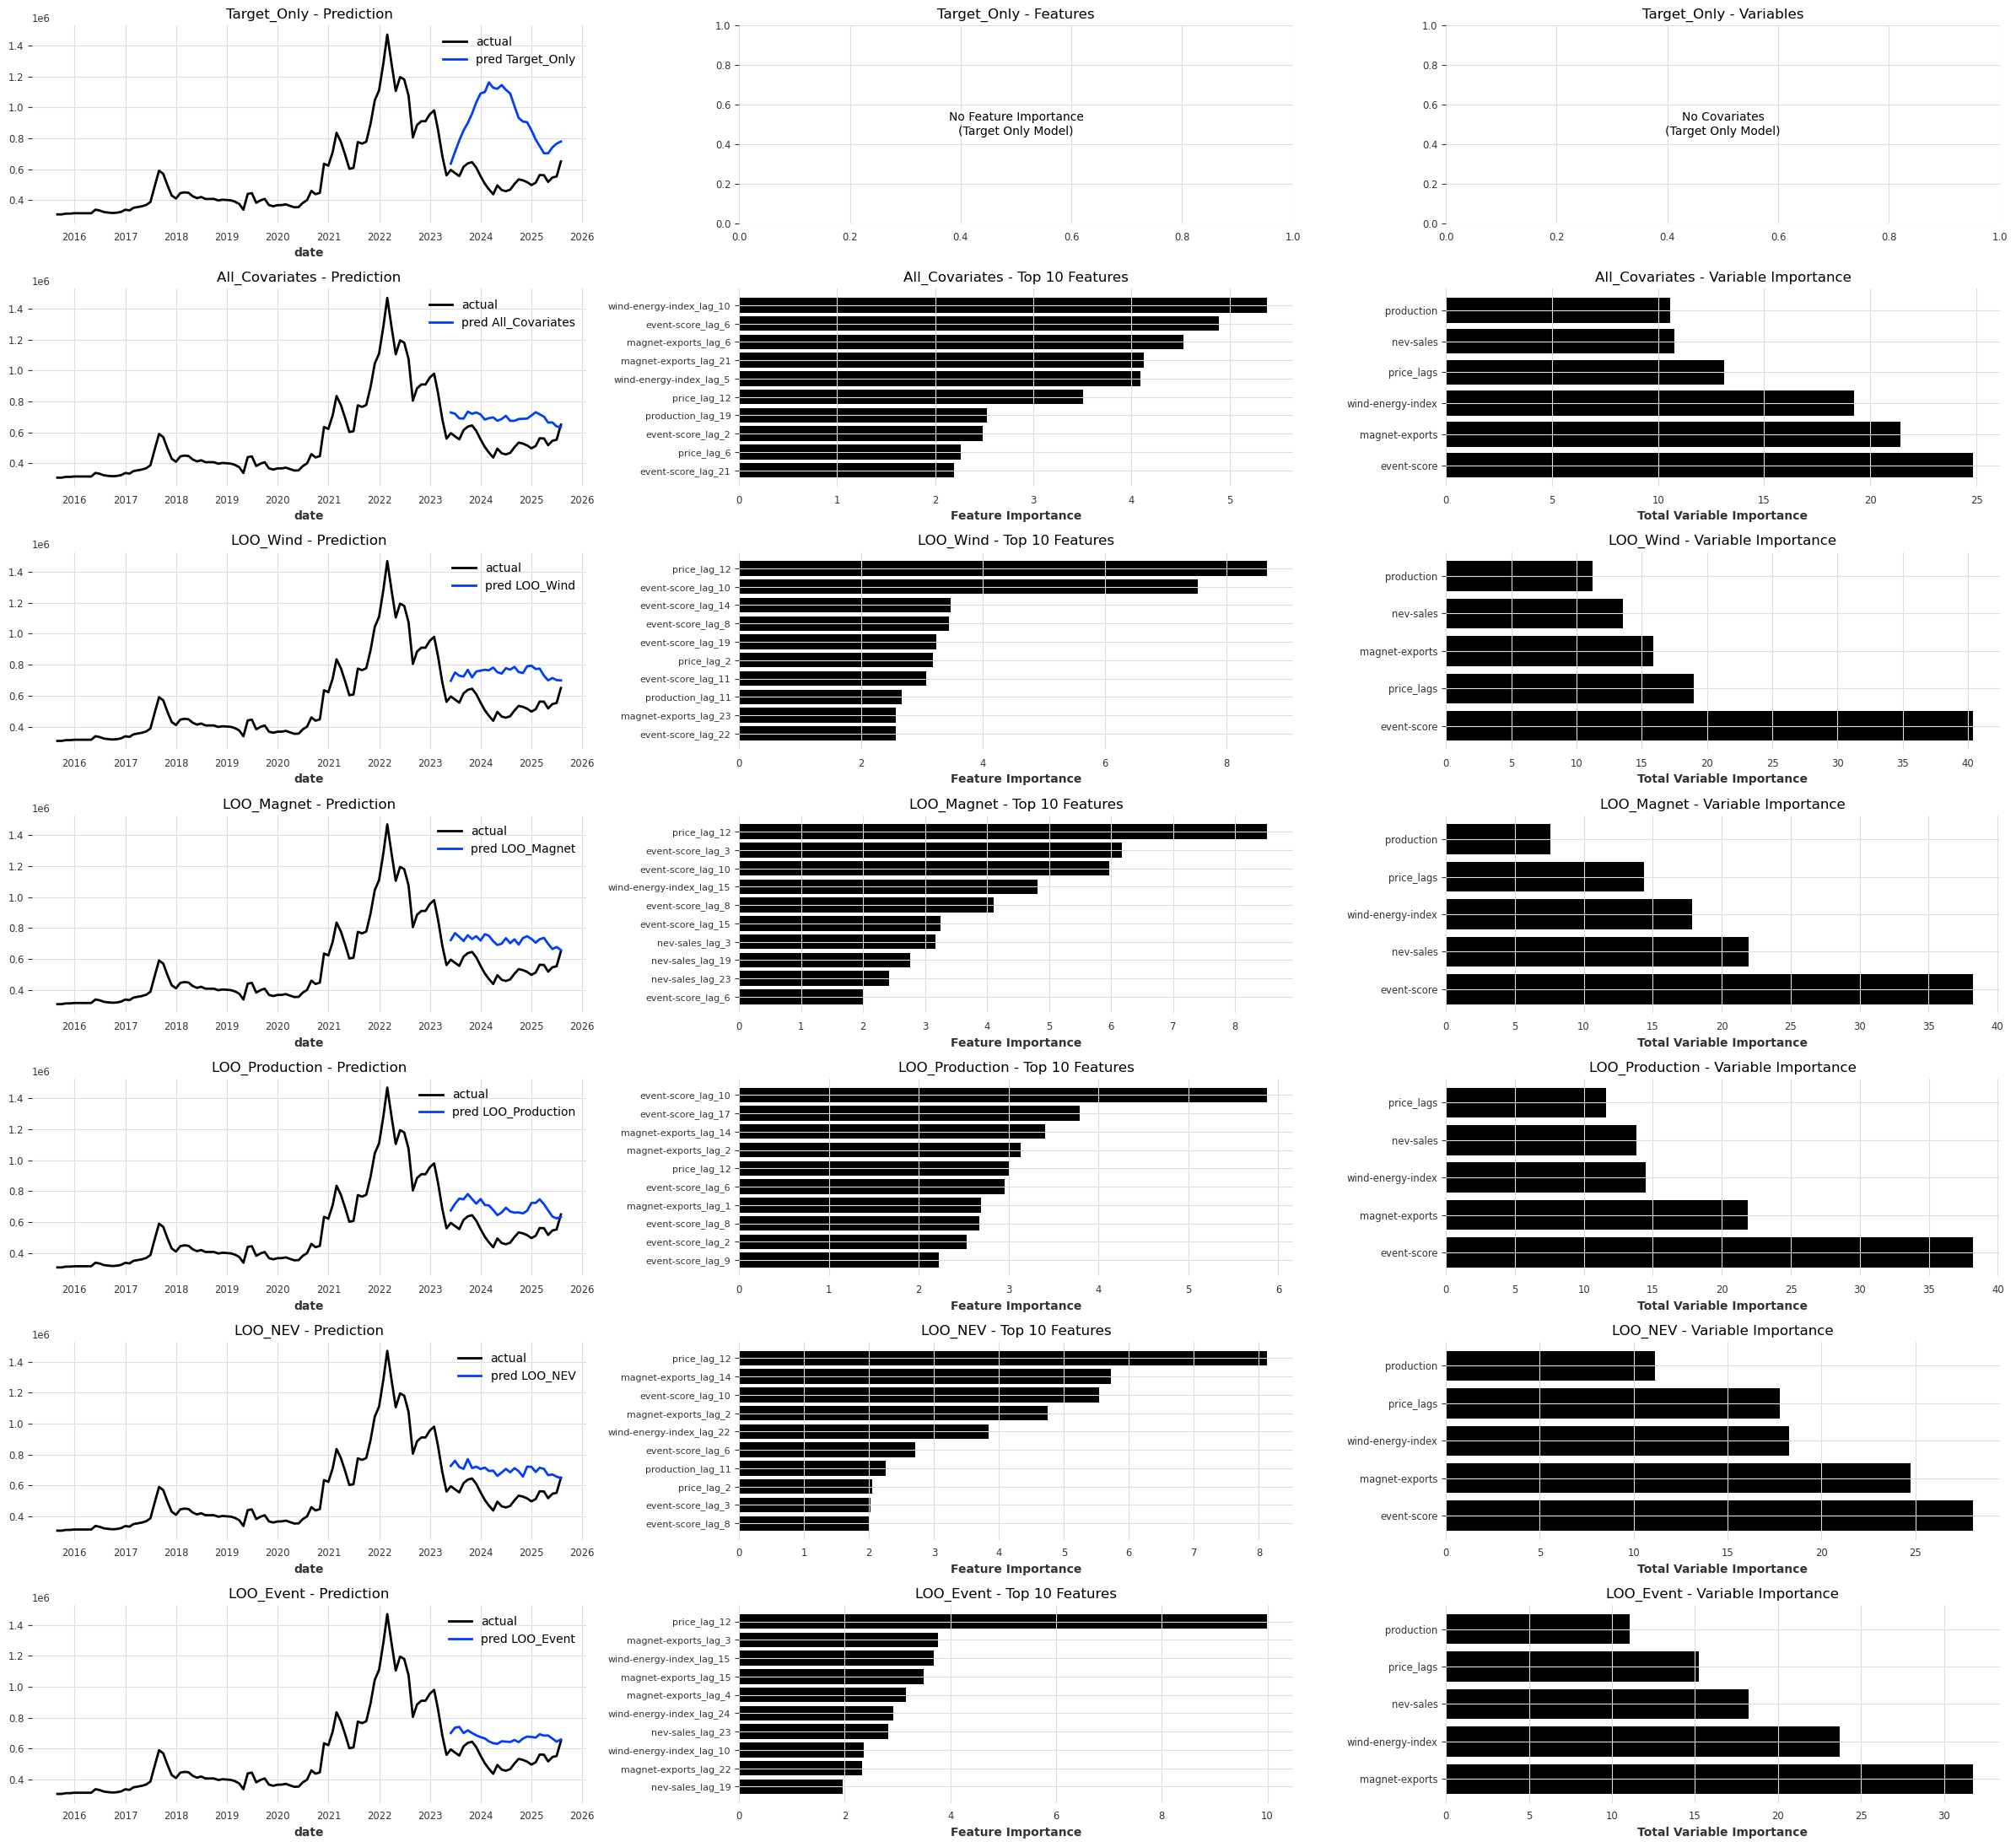

In [18]:
input = 12 # 이건 3, 6, 12 큰 차이 없음. 그래도 많을수록 좋음
output = 1 # 이건 3도 안 됨. 1해야 됨
lag_cov = 24 # 이건 24이상이 좋고, 24가 best
train_set = train.concatenate(val)
test_set = test
cov_set = train_cov.concatenate(val_cov).concatenate(test_cov)
pred_len = len(test_set)
Model = CatBoostModel

C_0 = Model(lags=input, output_chunk_length=output)
C_0.fit(train_set)
C_all = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_all.fit(train_set, past_covariates=cov_set)
C_loo_w = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_loo_w.fit(train_set, past_covariates=cov_set[['production', 'nev-sales', 'magnet-exports', 'event-score']])
C_loo_m = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_loo_m.fit(train_set, past_covariates=cov_set[['production', 'nev-sales', 'wind-energy-index', 'event-score']])
C_loo_p = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_loo_p.fit(train_set, past_covariates=cov_set[['nev-sales', 'wind-energy-index', 'magnet-exports', 'event-score']])
C_loo_n = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_loo_n.fit(train_set, past_covariates=cov_set[['production', 'wind-energy-index', 'magnet-exports', 'event-score']])
C_loo_e = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov)
C_loo_e.fit(train_set, past_covariates=cov_set[['production', 'nev-sales', 'wind-energy-index', 'magnet-exports']])

pred_C_0 = C_0.predict(n=pred_len)
pred_C_all = C_all.predict(n=pred_len)
pred_C_loo_w = C_loo_w.predict(n=pred_len)
pred_C_loo_m = C_loo_m.predict(n=pred_len)
pred_C_loo_p = C_loo_p.predict(n=pred_len)
pred_C_loo_n = C_loo_n.predict(n=pred_len)
pred_C_loo_e = C_loo_e.predict(n=pred_len)

# 평가 실행
predictions_dict = {
    'Target_Only': pred_C_0,
    'All_Covariates': pred_C_all,
    'LOO_Wind': pred_C_loo_w,
    'LOO_Magnet': pred_C_loo_m,
    'LOO_Production': pred_C_loo_p,
    'LOO_NEV': pred_C_loo_n,
    'LOO_Event': pred_C_loo_e
}
evaluate_predictions(Model, train_set, test_set, predictions_dict)

# 예측결과 및 변수 중요도
models = [C_0, C_all, C_loo_w, C_loo_m, C_loo_p, C_loo_n, C_loo_e]
model_names = ['Target_Only', 'All_Covariates', 'LOO_Wind', 'LOO_Magnet', 'LOO_Production', 'LOO_NEV', 'LOO_Event']
predictions = [pred_C_0, pred_C_all, pred_C_loo_w, pred_C_loo_m, pred_C_loo_p, pred_C_loo_n, pred_C_loo_e]
model_vars = [
    [],  # C_0: target only
    ['production', 'nev-sales', 'wind-energy-index', 'magnet-exports', 'event-score'],  # C_all
    ['production', 'nev-sales', 'magnet-exports', 'event-score'],  # C_loo_w (no wind)
    ['production', 'nev-sales', 'wind-energy-index', 'event-score'],  # C_loo_m (no magnet)
    ['nev-sales', 'wind-energy-index', 'magnet-exports', 'event-score'],  # C_loo_p (no production)
    ['production', 'wind-energy-index', 'magnet-exports', 'event-score'],  # C_loo_n (no nev)
    ['production', 'nev-sales', 'wind-energy-index', 'magnet-exports']  # C_loo_e (no event)
]
plot_model_analysis(models, model_names, predictions, model_vars, input, lag_cov)

#### Future cov forcasting

In [ ]:
# past_cov = series_filled[['production', 'nev-sales', 'wind-energy-index', 'magnet-exports', 'event-score']]

<Figure size 600x300 with 0 Axes>

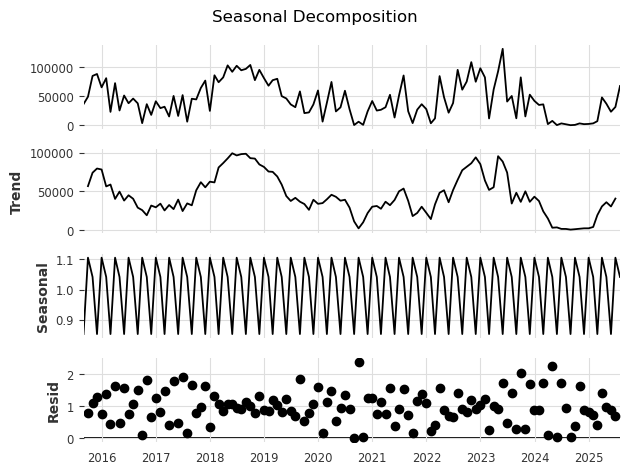

In [245]:
from statsmodels.tsa.seasonal import seasonal_decompose

cov_name = 'production'
cov = past_cov[cov_name].to_dataframe()

result3 = seasonal_decompose(cov, model='additive', period=3)
result6 = seasonal_decompose(cov, model='multiplicative', period=6)
result12 = seasonal_decompose(cov, model='multiplicative', period=3)

plt.figure(figsize=(6, 3))
result12.plot()
plt.suptitle('Seasonal Decomposition')
plt.tight_layout()
plt.show()

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000044 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 528
[LightGBM] [Info] Number of data points in the train set: 62, number of used features: 24
[LightGBM] [Info] Start training from score 50115.975145
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

e:\Programs\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\Programs\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\Programs\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\Programs\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\Programs\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\Programs\anaconda3\Lib\site-packages\sklearn\utils\v

RandomForest | MAE: 27207.9109 | RMSE: 31379.34 | sMAPE:  93.83%
XGBoost      | MAE: 22180.1770 | RMSE: 28003.12 | sMAPE:  91.92%
LightGBM     | MAE: 31483.2886 | RMSE: 35610.53 | sMAPE: 101.50%
CatBoost     | MAE: 28548.2805 | RMSE: 32469.42 | sMAPE:  95.14%


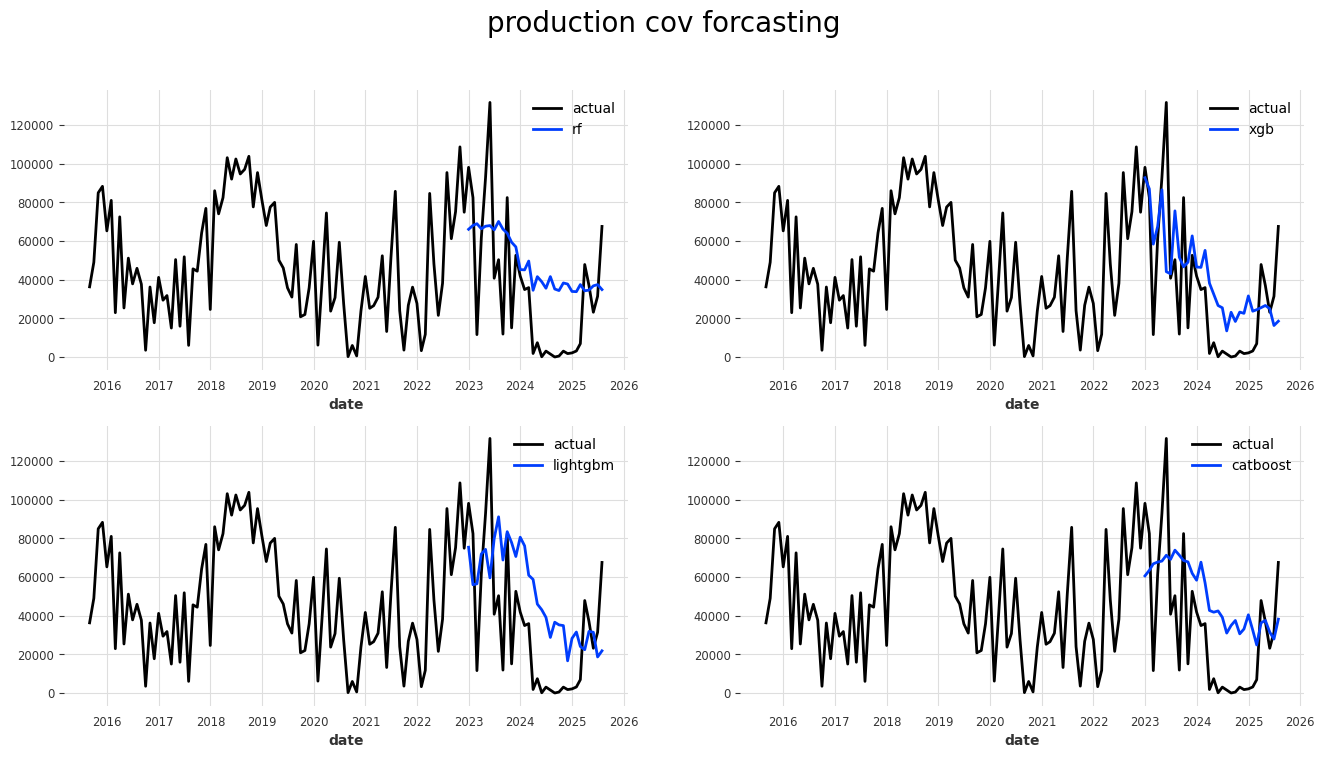

In [28]:
input = 24 # 
output = 3 # 
percentage = 0.74
cov_name = 'production'
cov = past_cov[cov_name]

# train, test 분리

split_idx = int(len(cov) * percentage)  # 80% 지점
train = cov[:split_idx]
test = cov[split_idx:]
pred_len = len(test)

rf = RandomForestModel(lags=input, output_chunk_length=output)
rf.fit(train)
xgb = XGBModel(lags=input, output_chunk_length=output)
xgb.fit(train)
lightgbm = LightGBMModel(lags=input, output_chunk_length=output)
lightgbm.fit(train)
catboost = CatBoostModel(lags=input, output_chunk_length=output)
catboost.fit(train)

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
plt.suptitle(f'{cov_name} cov forcasting', fontsize=20)
pred_rf = rf.predict(n=pred_len)
cov.plot(label='actual', ax=axes[0,0])
pred_rf.plot(label='rf', ax=axes[0,0])

pred_xgb = xgb.predict(n=pred_len)
cov.plot(label='actual', ax=axes[0,1])
pred_xgb.plot(label='xgb', ax=axes[0,1])

pred_lightgbm = lightgbm.predict(n=pred_len)
cov.plot(label='actual', ax=axes[1,0])
pred_lightgbm.plot(label='lightgbm', ax=axes[1,0])

pred_catboost = catboost.predict(n=pred_len)
cov.plot(label='actual', ax=axes[1,1])
pred_catboost.plot(label='catboost', ax=axes[1,1])

print(f"RandomForest | MAE: {mae(test, pred_rf):7.4f} | RMSE: {rmse(test, pred_rf):8.2f} | sMAPE: {smape(test, pred_rf):6.2f}%")
print(f"XGBoost      | MAE: {mae(test, pred_xgb):7.4f} | RMSE: {rmse(test, pred_xgb):8.2f} | sMAPE: {smape(test, pred_xgb):6.2f}%")
print(f"LightGBM     | MAE: {mae(test, pred_lightgbm):7.4f} | RMSE: {rmse(test, pred_lightgbm):8.2f} | sMAPE: {smape(test, pred_lightgbm):6.2f}%")
print(f"CatBoost     | MAE: {mae(test, pred_catboost):7.4f} | RMSE: {rmse(test, pred_catboost):8.2f} | sMAPE: {smape(test, pred_catboost):6.2f}%")

In [31]:
future_pred = xgb.predict(n=len(test)+12, show_warnings=False)
print(future_pred[-12:])

<TimeSeries (DataArray) (date: 12, component: 1, sample: 1)> Size: 48B
array([[[ 18726.879]],

       [[ 18303.791]],

       [[ 28773.012]],

       [[ 16954.217]],

       [[ 44695.555]],

       [[ 39595.906]],

       [[ 39933.23 ]],

       [[ 38684.184]],

       [[ 78986.39 ]],

       [[ 77764.805]],

       [[ 61944.344]],

       [[102327.7  ]]], dtype=float32)
Coordinates:
  * date       (date) datetime64[ns] 96B 2025-08-31 2025-09-30 ... 2026-07-31
  * component  (component) object 8B 'production'
Dimensions without coordinates: sample
Attributes:
    static_covariates:  None
    hierarchy:          None
    metadata:           None


<Figure size 600x300 with 0 Axes>

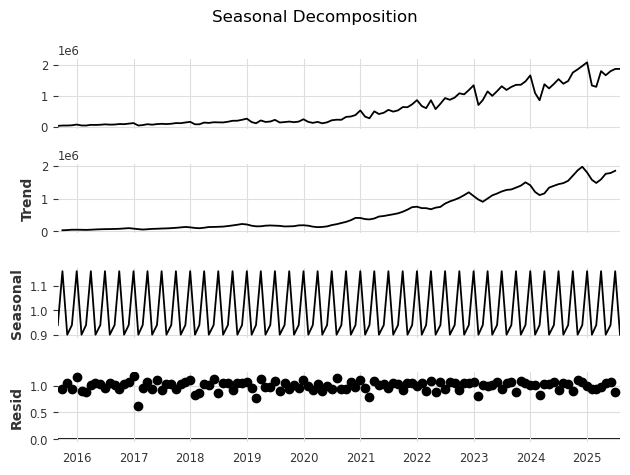

In [262]:
from statsmodels.tsa.seasonal import seasonal_decompose

cov_name = 'nev-sales'
cov = past_cov[cov_name].to_dataframe()

result3 = seasonal_decompose(cov, model='additive', period=3)
result6 = seasonal_decompose(cov, model='multiplicative', period=6)
result12 = seasonal_decompose(cov, model='multiplicative', period=3)

plt.figure(figsize=(6, 3))
result12.plot()
plt.suptitle('Seasonal Decomposition')
plt.tight_layout()
plt.show()

e:\Programs\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


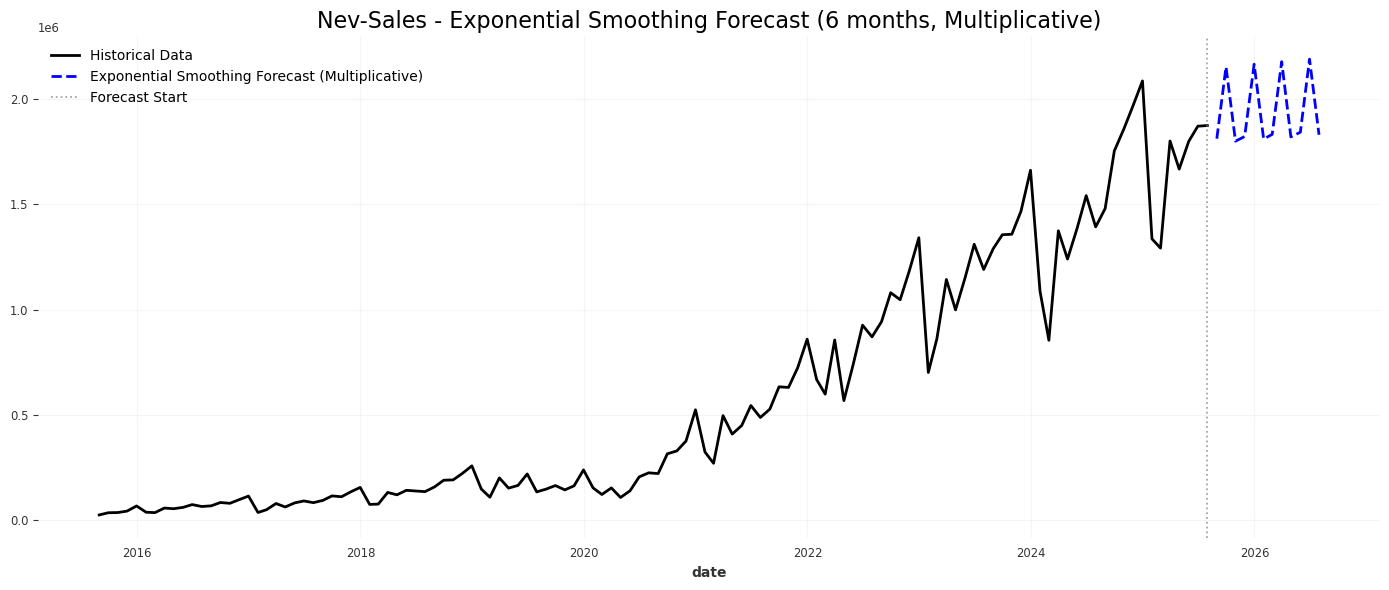


📅 Exponential Smoothing 6개월 예측값 (Multiplicative):
   Month 1: 1810003.4362
   Month 2: 2150787.8852
   Month 3: 1798202.2248
   Month 4: 1820208.2593
   Month 5: 2162891.3091
   Month 6: 1808302.5487
   Month 7: 1830413.0825
   Month 8: 2174994.7330
   Month 9: 1818402.8726
   Month 10: 1840617.9056
   Month 11: 2187098.1569
   Month 12: 1828503.1965

📊 모델 정보:
계절성 모드: Multiplicative
계절 주기: 3개월
예측 기간: 6개월


In [27]:
from darts.models import ExponentialSmoothing
import matplotlib.pyplot as plt
from darts import TimeSeries
import pandas as pd
import numpy as np

# SeasonalityMode를 올바른 위치에서 가져옵니다.
from darts.utils.utils import SeasonalityMode

cov_name = 'nev-sales'
cov = past_cov[cov_name]

# 1. Exponential Smoothing (multiplicative seasonal 고려)
# 'seasonal' 파라미터에 Enum 타입을 사용합니다.
exp_smooth = ExponentialSmoothing(
    seasonal_periods=3,
    seasonal=SeasonalityMode.MULTIPLICATIVE  # ✅ 수정된 부분
)
exp_smooth.fit(cov)
pred_exp = exp_smooth.predict(n=12, show_warnings=False)

# 2. 시각화
plt.figure(figsize=(14, 6))
cov.plot(label='Historical Data', color='black', linewidth=2)
pred_exp.plot(label='Exponential Smoothing Forecast (Multiplicative)', color='blue', linewidth=2, linestyle='--')
plt.axvline(x=cov.end_time(), color='gray', linestyle=':', alpha=0.7, label='Forecast Start')
plt.title(f'{cov_name.title()} - Exponential Smoothing Forecast (6 months, Multiplicative)', fontsize=16)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 3. 예측값 출력
print(f"\n📅 Exponential Smoothing 6개월 예측값 (Multiplicative):")
for i, value in enumerate(pred_exp.values().flatten()):
    print(f"   Month {i+1}: {value:.4f}")

# 4. 모델 정보 확인
print(f"\n📊 모델 정보:")
print(f"계절성 모드: Multiplicative")
print(f"계절 주기: 3개월")
print(f"예측 기간: 6개월")

[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 6, number of used features: 0
[LightGBM] [Info] Start training from score 429073549.333333
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet t

e:\Programs\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\Programs\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\Programs\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\Programs\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\Programs\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\Programs\anaconda3\Lib\site-packages\sklearn\utils\v

<Axes: xlabel='date'>

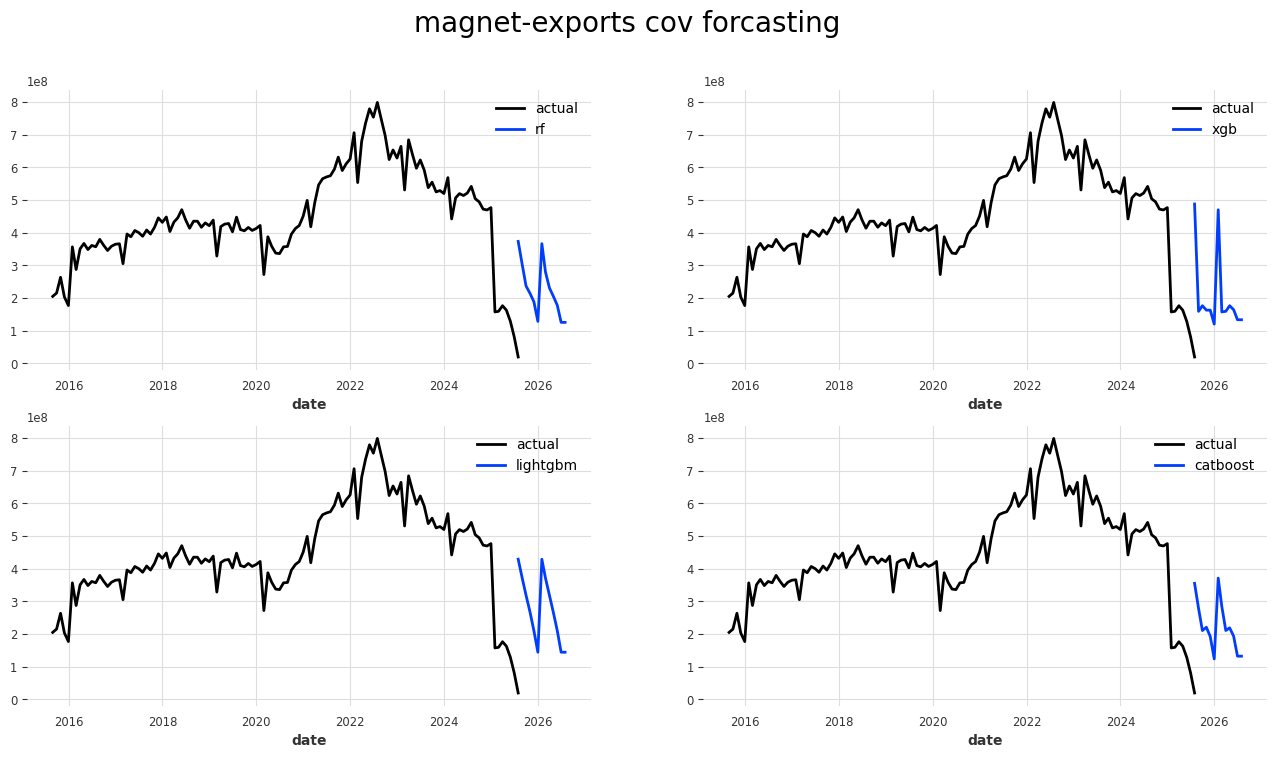

In [25]:
input = 12 # 
output = 6 # 
percentage = 0.8
cov_name = 'magnet-exports'
cov = past_cov[cov_name]

# train, test 분리

split_idx = int(len(cov) * percentage)  # 80% 지점
train = cov[:split_idx]
test = cov[split_idx:]

new_cov = test
split_idx = int(len(new_cov) * 0.999)
train = new_cov[:split_idx]
test = new_cov[split_idx:]
pred_len = len(test)+12

rf = RandomForestModel(lags=input, output_chunk_length=output)
rf.fit(train)
xgb = XGBModel(lags=input, output_chunk_length=output)
xgb.fit(train)
lightgbm = LightGBMModel(lags=input, output_chunk_length=output)
lightgbm.fit(train)
catboost = CatBoostModel(lags=input, output_chunk_length=output)
catboost.fit(train)

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
plt.suptitle(f'{cov_name} cov forcasting', fontsize=20)
pred_rf = rf.predict(n=pred_len)
cov.plot(label='actual', ax=axes[0,0])
pred_rf.plot(label='rf', ax=axes[0,0])

pred_xgb = xgb.predict(n=pred_len)
cov.plot(label='actual', ax=axes[0,1])
pred_xgb.plot(label='xgb', ax=axes[0,1])

pred_lightgbm = lightgbm.predict(n=pred_len)
cov.plot(label='actual', ax=axes[1,0])
pred_lightgbm.plot(label='lightgbm', ax=axes[1,0])

pred_catboost = catboost.predict(n=pred_len)
cov.plot(label='actual', ax=axes[1,1])
pred_catboost.plot(label='catboost', ax=axes[1,1])

# print(f"RandomForest | MAE: {mae(test, pred_rf):7.4f} | RMSE: {rmse(test, pred_rf):8.2f} | sMAPE: {smape(test, pred_rf):6.2f}%")
# print(f"XGBoost      | MAE: {mae(test, pred_xgb):7.4f} | RMSE: {rmse(test, pred_xgb):8.2f} | sMAPE: {smape(test, pred_xgb):6.2f}%")
# print(f"LightGBM     | MAE: {mae(test, pred_lightgbm):7.4f} | RMSE: {rmse(test, pred_lightgbm):8.2f} | sMAPE: {smape(test, pred_lightgbm):6.2f}%")
# print(f"CatBoost     | MAE: {mae(test, pred_catboost):7.4f} | RMSE: {rmse(test, pred_catboost):8.2f} | sMAPE: {smape(test, pred_catboost):6.2f}%")

In [26]:
print(pred_xgb)

<TimeSeries (DataArray) (date: 13, component: 1, sample: 1)> Size: 52B
array([[[4.87713088e+08]],

       [[1.59443296e+08]],

       [[1.76587280e+08]],

       [[1.62978288e+08]],

       [[1.63030288e+08]],

       [[1.20348280e+08]],

       [[4.70096992e+08]],

       [[1.57674144e+08]],

       [[1.59443648e+08]],

       [[1.76586800e+08]],

       [[1.64350384e+08]],

       [[1.33657464e+08]],

       [[1.33657464e+08]]], dtype=float32)
Coordinates:
  * date       (date) datetime64[ns] 104B 2025-07-31 2025-08-31 ... 2026-07-31
  * component  (component) object 8B 'magnet-exports'
Dimensions without coordinates: sample
Attributes:
    static_covariates:  None
    hierarchy:          None
    metadata:           None


<Figure size 600x300 with 0 Axes>

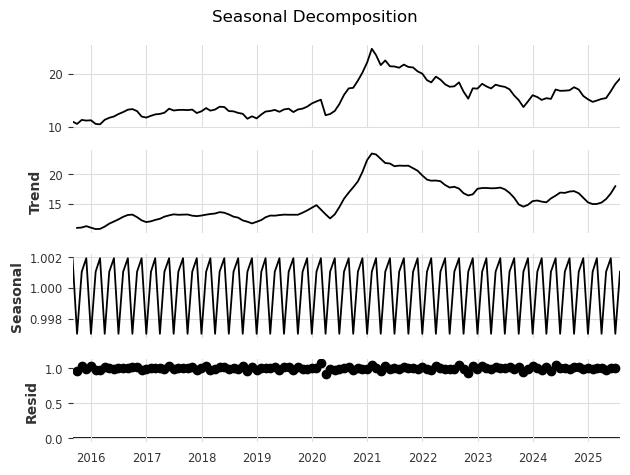

In [320]:
from statsmodels.tsa.seasonal import seasonal_decompose

cov_name = 'wind-energy-index'
cov = past_cov[cov_name].to_dataframe()

result3 = seasonal_decompose(cov, model='additive', period=3)
result6 = seasonal_decompose(cov, model='multiplicative', period=6)
result12 = seasonal_decompose(cov, model='multiplicative', period=3)

plt.figure(figsize=(6, 3))
result12.plot()
plt.suptitle('Seasonal Decomposition')
plt.tight_layout()
plt.show()

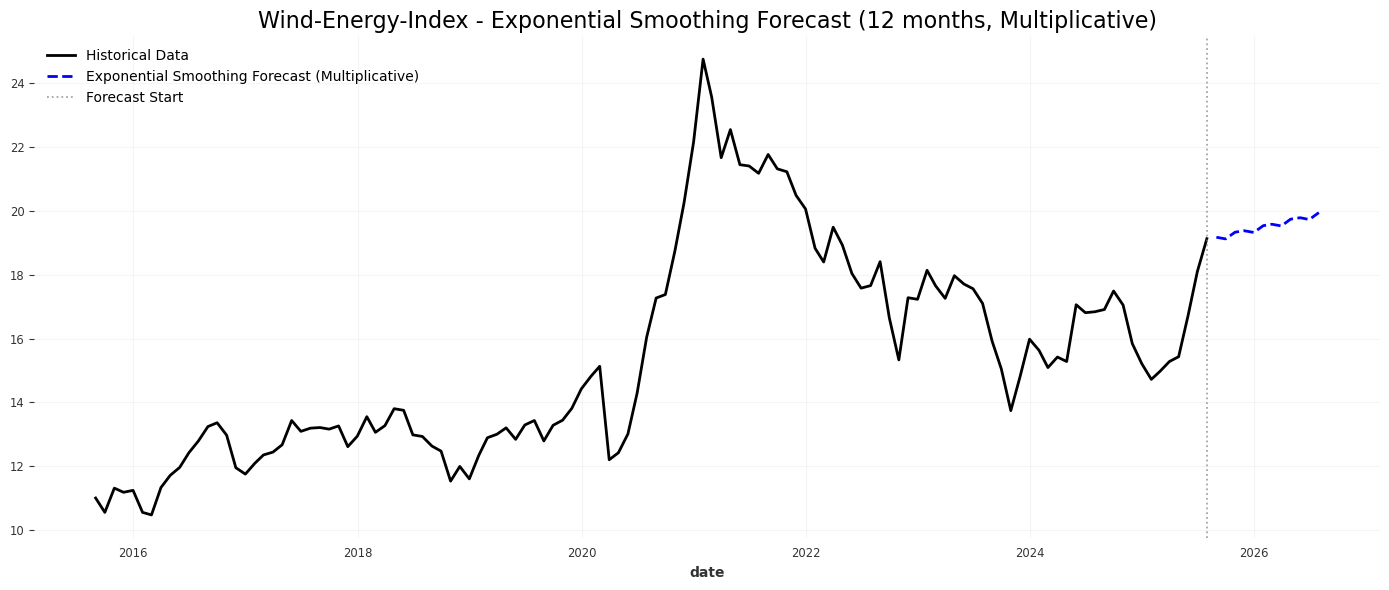


📅 Exponential Smoothing 12개월 예측값 (Multiplicative):
   Month 1: 19.1753
   Month 2: 19.1235
   Month 3: 19.3344
   Month 4: 19.3795
   Month 5: 19.3264
   Month 6: 19.5388
   Month 7: 19.5836
   Month 8: 19.5293
   Month 9: 19.7433
   Month 10: 19.7878
   Month 11: 19.7322
   Month 12: 19.9477

📊 모델 정보:
계절성 모드: Multiplicative
계절 주기: 3개월
예측 기간: 6개월


In [24]:
from darts.models import ExponentialSmoothing
import matplotlib.pyplot as plt
from darts import TimeSeries
import pandas as pd
import numpy as np

# SeasonalityMode를 올바른 위치에서 가져옵니다.
from darts.utils.utils import SeasonalityMode

cov_name = 'wind-energy-index'
cov = past_cov[cov_name]

# 1. Exponential Smoothing (multiplicative seasonal 고려)
# 'seasonal' 파라미터에 Enum 타입을 사용합니다.
exp_smooth = ExponentialSmoothing(
    seasonal_periods=3,
    seasonal=SeasonalityMode.MULTIPLICATIVE  # ✅ 수정된 부분
)
exp_smooth.fit(cov)
pred_exp = exp_smooth.predict(n=12, show_warnings=False)

# 2. 시각화
plt.figure(figsize=(14, 6))
cov.plot(label='Historical Data', color='black', linewidth=2)
pred_exp.plot(label='Exponential Smoothing Forecast (Multiplicative)', color='blue', linewidth=2, linestyle='--')
plt.axvline(x=cov.end_time(), color='gray', linestyle=':', alpha=0.7, label='Forecast Start')
plt.title(f'{cov_name.title()} - Exponential Smoothing Forecast (12 months, Multiplicative)', fontsize=16)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 3. 예측값 출력
print(f"\n📅 Exponential Smoothing 12개월 예측값 (Multiplicative):")
for i, value in enumerate(pred_exp.values().flatten()):
    print(f"   Month {i+1}: {value:.4f}")

# 4. 모델 정보 확인
print(f"\n📊 모델 정보:")
print(f"계절성 모드: Multiplicative")
print(f"계절 주기: 3개월")
print(f"예측 기간: 6개월")

#### Senario forcasting

In [32]:
# past_cov
future_production = [18726.879, 18303.791, 28773.012, 16954.217, 44695.555, 39595.906, 39933.23, 38684.184, 78986.39, 77764.805, 61944.344, 102327.7]
future_nev_sales = [1810003.4362, 2150787.8852, 1798202.2248, 1820208.2593, 2162891.3091, 1808302.5487, 1830413.0825, 2174994.7330, 1818402.8726, 1840617.9056, 2187098.1569, 1828503.1965]
future_wind_energy = [19.1753, 19.1235, 19.3344, 19.3795, 19.3264, 19.5388, 19.5836, 19.5293, 19.7433, 19.7878, 19.7322, 19.9477]
future_magnet_exports = [1.59443296e+08, 1.76587280e+08, 1.62978288e+08, 1.63030288e+08, 1.20348280e+08, 4.70096992e+08, 1.57674144e+08, 1.59443648e+08, 1.76586800e+08, 1.64350384e+08, 1.33657464e+08, 1.33657464e+08]

# 미래 시점 생성 (현재 데이터 다음 12개월)
future_dates = pd.date_range(
    start=past_cov.end_time() + past_cov.freq,
    periods=12,
    freq=past_cov.freq
)
print("미래 시점들:", future_dates)

미래 시점들: DatetimeIndex(['2025-08-31', '2025-09-30', '2025-10-31', '2025-11-30',
               '2025-12-31', '2026-01-31', '2026-02-28', '2026-03-31',
               '2026-04-30', '2026-05-31', '2026-06-30', '2026-07-31'],
              dtype='datetime64[ns]', freq='ME')


`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.


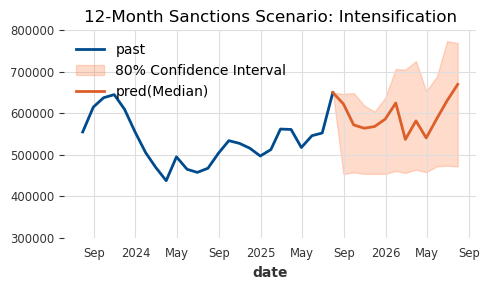


🎯 시나리오 1 예측 결과
현재 가격 (2025년 7월): 650000.00

월별 예측값 (중위값):
  2025년  8월: 622498.31
  2025년  9월: 571981.05
  2025년 10월: 563963.21
  2025년 11월: 568115.95
  2025년 12월: 585853.16
  2026년  1월: 624774.59
  2026년  2월: 537001.67
  2026년  3월: 581715.18
  2026년  4월: 540581.84
  2026년  5월: 587222.22
  2026년  6월: 630392.45
  2026년  7월: 669692.55

12개월 평균 예측 가격: 590316.02
현재 대비 변화율: -9.2%

신뢰구간 요약:
  하위10%: [453627.34 457548.85 453904.81 453904.81 453904.81 461033.92 456184.79
 464037.28 458010.88 472130.83 473678.62 471699.23]
  중위값:  [622498.31 571981.05 563963.21 568115.95 585853.16 624774.59 537001.67
 581715.18 540581.84 587222.22 630392.45 669692.55]
  상위90%: [646490.92 648881.1  618686.48 604116.61 637147.94 706968.12 705125.45
 725817.62 653142.01 688341.04 773954.34 769204.16]
  평균 신뢰구간 너비: 220684.13

시나리오 비교용 핵심 지표
시나리오 1 - 12개월 평균 예측: 590316.02
변화율: -9.2%
예측값: [622498.3125     571981.05277941 563963.21160089 568115.94604839
 585853.15634242 624774.58763423 537001.67360255 581715.17692101


In [45]:
# 시나리오 1: 제재 강화
scenario_1_events = {
    '3months': [2.8, 3.1, 3.5],  # 8월, 9월, 10월
    '6months': [2.8, 3.1, 3.5, 3.8, 4.0, 3.7]  # 8월~1월
}

future_cov_data = pd.DataFrame({
    'production': future_production,
    'nev-sales': future_nev_sales,
    'wind-energy-index': future_wind_energy,
    'magnet-exports': future_magnet_exports,
    'event-score': [1.98, 0.48, -1.06, -1.80, -2.05, -2.70, -2.24, -1.60, -1.93, -1.35, -1.63, -1.31]
}, index=future_dates)
future_cov_ts = TimeSeries.from_dataframe(future_cov_data)
extended_cov = past_cov.concatenate(future_cov_ts)

input = 12 # 이건 3, 6, 12 큰 차이 없음. 그래도 많을수록 좋음
output = 1 # 이건 3도 안 됨. 1해야 됨
lag_cov = 24 # 이건 24이상이 좋고, 24가 best
train_set = train.concatenate(val).concatenate(test)
cov_set = extended_cov

Model = XGBModel
q_list = [0.1, 0.5, 0.9]  # 하/중앙/상 분위수

C_loo_p = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov, likelihood='quantile', quantiles=q_list, random_state=42)
C_loo_p.fit(train_set, past_covariates=cov_set[['nev-sales', 'wind-energy-index', 'magnet-exports', 'event-score']])

# 확률적 예측 (여러 시나리오 생성)
pred_6m_prob = C_loo_p.predict(n=12, num_samples=100)

# 신뢰구간 계산(과거 마지막 값도 포함)
pred_6m_median = pred_6m_prob.quantile(0.5)
pred_6m_low = pred_6m_prob.quantile(0.1)
pred_6m_high = pred_6m_prob.quantile(0.9)
combined_median = train_set[-1:].concatenate(pred_6m_median)
combined_low = train_set[-1:].concatenate(pred_6m_low)
combined_high = train_set[-1:].concatenate(pred_6m_high)

# 시각화
fig, ax = plt.subplots(figsize=(5, 3))

# 미래 날짜 생성
future_dates_12m = pd.date_range(start=train_set.end_time() + train_set.freq, periods=12, freq=train_set.freq)

# 12개월 시나리오
train_set[-25:].plot(ax=ax, label='past', color='#004B8D')
ax.fill_between(combined_median.time_index, 
                combined_low.values().flatten(), 
                combined_high.values().flatten(), 
                alpha=0.2, color="#FF4D00", label='80% Confidence Interval')
combined_median.plot(ax=ax, label='pred(Median)', color="#DC5E28")

# y축 범위
ymin, ymax = 300000, 800000  # 원하는 값으로 고정
ax.set_ylim(ymin, ymax)

plt.title('12-Month Sanctions Scenario: Intensification')

plt.tight_layout()
plt.show()

# 결과 출력
print("\n" + "="*60)
print("🎯 시나리오 1 예측 결과")
print("="*60)
current_price = train_set.values()[-1][0]
median_values = pred_6m_median.values().flatten()
low_values = pred_6m_low.values().flatten()
high_values = pred_6m_high.values().flatten()

print(f"현재 가격 (2025년 7월): {current_price:.2f}")
print(f"\n월별 예측값 (중위값):")
for i, val in enumerate(median_values, 1):
    month = 7 + i
    year = 2025 if month <= 12 else 2026
    if month > 12:
        month -= 12
    print(f"  {year}년 {month:2d}월: {val:6.2f}")

print(f"\n12개월 평균 예측 가격: {median_values.mean():.2f}")
print(f"현재 대비 변화율: {((median_values.mean() / current_price) - 1) * 100:+.1f}%")

print(f"\n신뢰구간 요약:")
print(f"  하위10%: {np.round(low_values, 2)}")
print(f"  중위값:  {np.round(median_values, 2)}")
print(f"  상위90%: {np.round(high_values, 2)}")
print(f"  평균 신뢰구간 너비: {(high_values - low_values).mean():.2f}")

# 시나리오 비교를 위한 핵심 지표
print("\n" + "="*60)
print("시나리오 비교용 핵심 지표")
print("="*60)
print(f"시나리오 1 - 12개월 평균 예측: {median_values.mean():.2f}")
print(f"변화율: {((median_values.mean() / current_price) - 1) * 100:+.1f}%")
print(f"예측값: {median_values}")

`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.


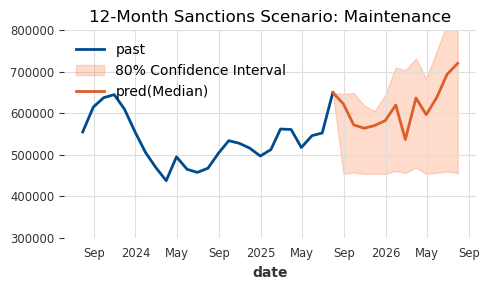


🎯 시나리오 2 예측 결과
현재 가격 (2025년 7월): 650000.00

월별 예측값 (중위값):
  2025년  8월: 622498.31
  2025년  9월: 571981.05
  2025년 10월: 563945.65
  2025년 11월: 570435.69
  2025년 12월: 582221.31
  2026년  1월: 619838.61
  2026년  2월: 536635.82
  2026년  3월: 636904.31
  2026년  4월: 596605.28
  2026년  5월: 638500.96
  2026년  6월: 694103.28
  2026년  7월: 720397.01

12개월 평균 예측 가격: 612838.94
현재 대비 변화율: -5.7%

신뢰구간 요약:
  하위10%: [453627.34 457548.85 453904.81 453904.81 453904.81 460821.88 456178.62
 468829.59 453904.81 456377.19 459849.71 455687.43]
  중위값:  [622498.31 571981.05 563945.65 570435.69 582221.31 619838.61 536635.82
 636904.31 596605.28 638500.96 694103.28 720397.01]
  상위90%: [646490.92 648881.1  618677.64 605268.59 644169.56 710829.71 703694.07
 732179.31 683574.31 750157.78 815091.66 797652.94]
  평균 신뢰구간 너비: 239343.98

시나리오 비교용 핵심 지표
시나리오 2 - 12개월 평균 예측: 612838.94
변화율: -5.7%
예측값: [622498.3125     571981.05277941 563945.64979231 570435.69303498
 582221.3116189  619838.6092877  536635.82208462 636904.31307145


In [47]:
# 시나리오 2: 현상 유지
scenario_2_events = {
    '3months': [0.2, -0.1, 0.3],
    '6months': [0.2, -0.1, 0.3, 0.1, 0.4, 0.0]
}

future_cov_data = pd.DataFrame({
    'production': future_production,
    'nev-sales': future_nev_sales,
    'wind-energy-index': future_wind_energy,
    'magnet-exports': future_magnet_exports,
    'event-score': [2.99, 1.52, 1.08, 0.50, 0.01, -0.35, -0.58, -0.46, -0.57, -0.65, -0.80, -0.69]
}, index=future_dates)
future_cov_ts = TimeSeries.from_dataframe(future_cov_data)
extended_cov = past_cov.concatenate(future_cov_ts)

input = 12 # 이건 3, 6, 12 큰 차이 없음. 그래도 많을수록 좋음
output = 1 # 이건 3도 안 됨. 1해야 됨
lag_cov = 24 # 이건 24이상이 좋고, 24가 best
train_set = train.concatenate(val).concatenate(test)
cov_set = extended_cov

Model = XGBModel
q_list = [0.1, 0.5, 0.9]  # 하/중앙/상 분위수

C_loo_p = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov, likelihood='quantile', quantiles=q_list, random_state=42)
C_loo_p.fit(train_set, past_covariates=cov_set[['nev-sales', 'wind-energy-index', 'magnet-exports', 'event-score']])

# 확률적 예측 (여러 시나리오 생성)
pred_6m_prob = C_loo_p.predict(n=12, num_samples=100)

# 신뢰구간 계산(과거 마지막 값도 포함)
pred_6m_median = pred_6m_prob.quantile(0.5)
pred_6m_low = pred_6m_prob.quantile(0.1)
pred_6m_high = pred_6m_prob.quantile(0.9)
combined_median = train_set[-1:].concatenate(pred_6m_median)
combined_low = train_set[-1:].concatenate(pred_6m_low)
combined_high = train_set[-1:].concatenate(pred_6m_high)

# 시각화
fig, ax = plt.subplots(figsize=(5, 3))

# 미래 날짜 생성
future_dates_12m = pd.date_range(start=train_set.end_time() + train_set.freq, periods=12, freq=train_set.freq)

# 12개월 시나리오
train_set[-25:].plot(ax=ax, label='past', color='#004B8D')
ax.fill_between(combined_median.time_index, 
                combined_low.values().flatten(), 
                combined_high.values().flatten(), 
                alpha=0.2, color="#FF4D00", label='80% Confidence Interval')
combined_median.plot(ax=ax, label='pred(Median)', color="#DC5E28")

# y축 범위
ymin, ymax = 300000, 800000  # 원하는 값으로 고정
ax.set_ylim(ymin, ymax)

plt.title('12-Month Sanctions Scenario: Maintenance')

plt.tight_layout()
plt.show()

# 결과 출력
print("\n" + "="*60)
print("🎯 시나리오 2 예측 결과")
print("="*60)
current_price = train_set.values()[-1][0]
median_values = pred_6m_median.values().flatten()
low_values = pred_6m_low.values().flatten()
high_values = pred_6m_high.values().flatten()

print(f"현재 가격 (2025년 7월): {current_price:.2f}")
print(f"\n월별 예측값 (중위값):")
for i, val in enumerate(median_values, 1):
    month = 7 + i
    year = 2025 if month <= 12 else 2026
    if month > 12:
        month -= 12
    print(f"  {year}년 {month:2d}월: {val:6.2f}")

print(f"\n12개월 평균 예측 가격: {median_values.mean():.2f}")
print(f"현재 대비 변화율: {((median_values.mean() / current_price) - 1) * 100:+.1f}%")

print(f"\n신뢰구간 요약:")
print(f"  하위10%: {np.round(low_values, 2)}")
print(f"  중위값:  {np.round(median_values, 2)}")
print(f"  상위90%: {np.round(high_values, 2)}")
print(f"  평균 신뢰구간 너비: {(high_values - low_values).mean():.2f}")

# 시나리오 비교를 위한 핵심 지표
print("\n" + "="*60)
print("시나리오 비교용 핵심 지표")
print("="*60)
print(f"시나리오 2 - 12개월 평균 예측: {median_values.mean():.2f}")
print(f"변화율: {((median_values.mean() / current_price) - 1) * 100:+.1f}%")
print(f"예측값: {median_values}")

`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.


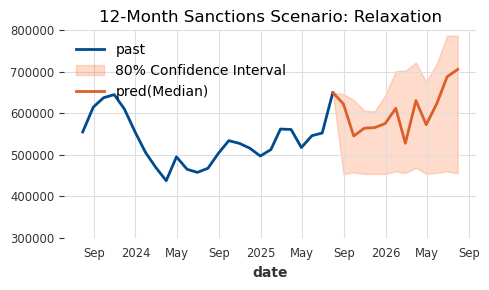


🎯 시나리오 3 예측 결과
현재 가격 (2025년 7월): 650000.00

월별 예측값 (중위값):
  2025년  8월: 622498.31
  2025년  9월: 545249.56
  2025년 10월: 563978.55
  2025년 11월: 565415.28
  2025년 12월: 575211.66
  2026년  1월: 611983.93
  2026년  2월: 527848.37
  2026년  3월: 630654.09
  2026년  4월: 572580.68
  2026년  5월: 623529.26
  2026년  6월: 688100.56
  2026년  7월: 705736.69

12개월 평균 예측 가격: 602732.25
현재 대비 변화율: -7.3%

신뢰구간 요약:
  하위10%: [453627.34 457548.85 453904.81 453904.81 453904.81 459868.28 455936.86
 468540.26 453904.81 456335.07 459880.98 455354.25]
  중위값:  [622498.31 545249.56 563978.55 565415.28 575211.66 611983.93 527848.37
 630654.09 572580.68 623529.26 688100.56 705736.69]
  상위90%: [646490.92 631974.9  606134.23 604607.81 643151.8  701754.41 702791.66
 722287.96 675393.37 719777.76 787089.16 786808.33]
  평균 신뢰구간 너비: 228795.93

시나리오 비교용 핵심 지표
시나리오 3 - 12개월 평균 예측: 602732.25
변화율: -7.3%
예측값: [622498.3125     545249.5625     563978.54859814 565415.28246611
 575211.66212102 611983.92628525 527848.37364045 630654.08936797


In [58]:
# 시나리오 3: 공급 증가/수요 감소
scenario_3_events = {
    '3months': [-1.2, -1.8, -2.3],
    '6months': [-1.2, -1.8, -2.3, -2.5, -2.0, -1.5]
}

future_cov_data = pd.DataFrame({
    'production': future_production,
    'nev-sales': future_nev_sales,
    'wind-energy-index': future_wind_energy,
    'magnet-exports': future_magnet_exports,
    'event-score': [3.32, 2.45, 2.53, 2.39, 2.00, 2.34, 1.54, 0.70, 0.84, 0.08, 0.18, -0.13]
}, index=future_dates)
future_cov_ts = TimeSeries.from_dataframe(future_cov_data)
extended_cov = past_cov.concatenate(future_cov_ts)

input = 12 # 이건 3, 6, 12 큰 차이 없음. 그래도 많을수록 좋음
output = 1 # 이건 3도 안 됨. 1해야 됨
lag_cov = 24 # 이건 24이상이 좋고, 24가 best
train_set = train.concatenate(val).concatenate(test)
cov_set = extended_cov

Model = XGBModel
q_list = [0.1, 0.5, 0.9]  # 하/중앙/상 분위수

C_loo_p = Model(lags=input, output_chunk_length=output, lags_past_covariates=lag_cov, likelihood='quantile', quantiles=q_list, random_state=42)
C_loo_p.fit(train_set, past_covariates=cov_set[['nev-sales', 'wind-energy-index', 'magnet-exports', 'event-score']])

# 확률적 예측 (여러 시나리오 생성)
pred_6m_prob = C_loo_p.predict(n=12, num_samples=100)

# 신뢰구간 계산(과거 마지막 값도 포함)
pred_6m_median = pred_6m_prob.quantile(0.5)
pred_6m_low = pred_6m_prob.quantile(0.1)
pred_6m_high = pred_6m_prob.quantile(0.9)
combined_median = train_set[-1:].concatenate(pred_6m_median)
combined_low = train_set[-1:].concatenate(pred_6m_low)
combined_high = train_set[-1:].concatenate(pred_6m_high)

# 시각화
fig, ax = plt.subplots(figsize=(5, 3))

# 미래 날짜 생성
future_dates_12m = pd.date_range(start=train_set.end_time() + train_set.freq, periods=12, freq=train_set.freq)

# 12개월 시나리오
train_set[-25:].plot(ax=ax, label='past', color='#004B8D')
ax.fill_between(combined_median.time_index, 
                combined_low.values().flatten(), 
                combined_high.values().flatten(), 
                alpha=0.2, color="#FF4D00", label='80% Confidence Interval')
combined_median.plot(ax=ax, label='pred(Median)', color="#DC5E28")

# y축 범위
ymin, ymax = 300000, 800000  # 원하는 값으로 고정
ax.set_ylim(ymin, ymax)

plt.title('12-Month Sanctions Scenario: Relaxation')

plt.tight_layout()
plt.show()

# 결과 출력
print("\n" + "="*60)
print("🎯 시나리오 3 예측 결과")
print("="*60)
current_price = train_set.values()[-1][0]
median_values = pred_6m_median.values().flatten()
low_values = pred_6m_low.values().flatten()
high_values = pred_6m_high.values().flatten()

print(f"현재 가격 (2025년 7월): {current_price:.2f}")
print(f"\n월별 예측값 (중위값):")
for i, val in enumerate(median_values, 1):
    month = 7 + i
    year = 2025 if month <= 12 else 2026
    if month > 12:
        month -= 12
    print(f"  {year}년 {month:2d}월: {val:6.2f}")

print(f"\n12개월 평균 예측 가격: {median_values.mean():.2f}")
print(f"현재 대비 변화율: {((median_values.mean() / current_price) - 1) * 100:+.1f}%")

print(f"\n신뢰구간 요약:")
print(f"  하위10%: {np.round(low_values, 2)}")
print(f"  중위값:  {np.round(median_values, 2)}")
print(f"  상위90%: {np.round(high_values, 2)}")
print(f"  평균 신뢰구간 너비: {(high_values - low_values).mean():.2f}")

# 시나리오 비교를 위한 핵심 지표
print("\n" + "="*60)
print("시나리오 비교용 핵심 지표")
print("="*60)
print(f"시나리오 3 - 12개월 평균 예측: {median_values.mean():.2f}")
print(f"변화율: {((median_values.mean() / current_price) - 1) * 100:+.1f}%")
print(f"예측값: {median_values}")